
All CSV and PNG outputs will be written to: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221

ORIGINAL SGuA SOWING + DIFFERENT r SCHEMES (SGuA2)

----------------------------------------------------------------------------------------------------
Init scheme inside ORIGINAL SGuA sowing: rand
----------------------------------------------------------------------------------------------------
Run 01 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 95.014022
Run 02 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 100.112295
Run 03 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 89.117489
Run 04 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 86.782703
Run 05 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 91.698197
Run 06 | SGuA2 | rand | Feasible: True | Best Fitness

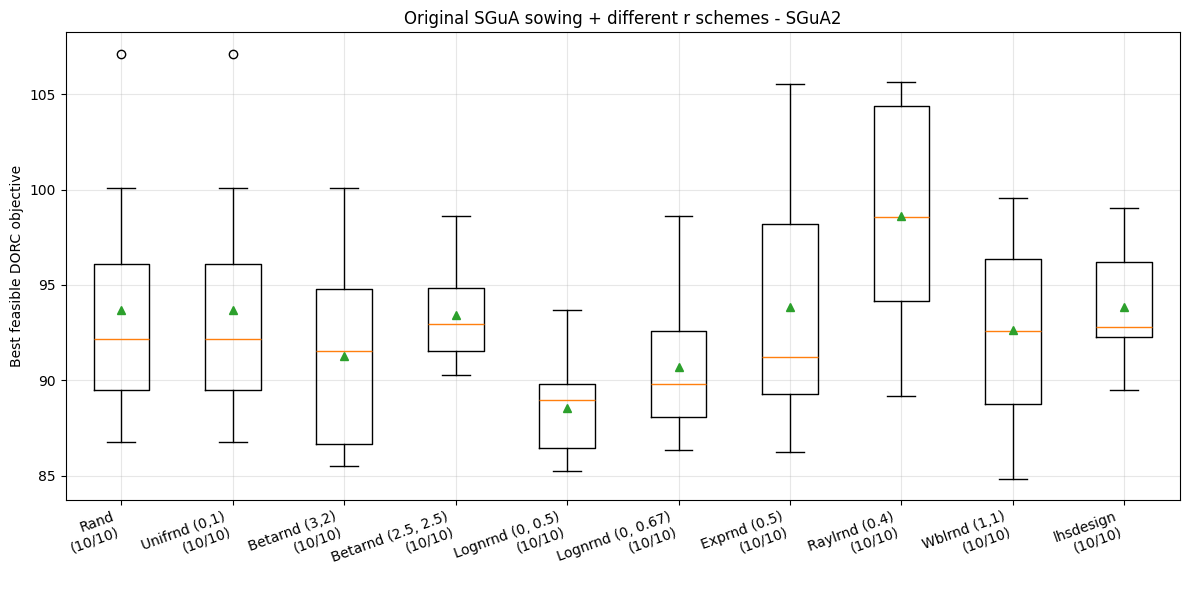

C:\Users\ESEL\AppData\Local\Temp\ipykernel_20472\4178178436.py:2036: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
C:\Users\ESEL\AppData\Local\Programs\Python\Python310\cpu\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\mean_convergence_original_sgua_sowing_SGuA2.png


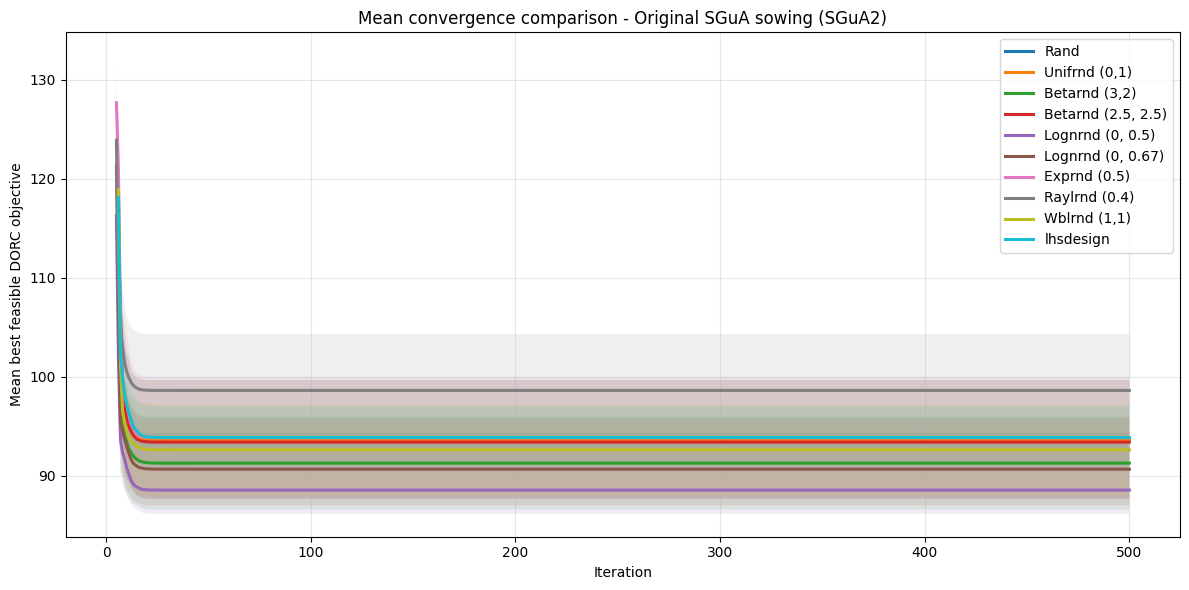


FULL COMPARATIVE MICROGRID DORC EVALUATION: SGuA BASELINES + CLASSICAL METHODS + CMA-ES + L-SHADE
Saved run results: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\sgua_dorc_run_results.csv
Saved convergence curves: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\sgua_dorc_feasible_curves.csv

----------------------------------------------------------------------------------------------------
Selected SGuA baseline for comparison: lognorm_0_0_5
----------------------------------------------------------------------------------------------------
Run 01 | SGuA2 | lognorm_0_0_5 | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 88.810045
Run 02 | SGuA2 | lognorm_0_0_5 | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 90.015391
Run 03 | SGuA2 | lognorm_0_0_5 | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 87.194420
Run 04 | SGuA2 | lognorm_0_0_5 | Feasi

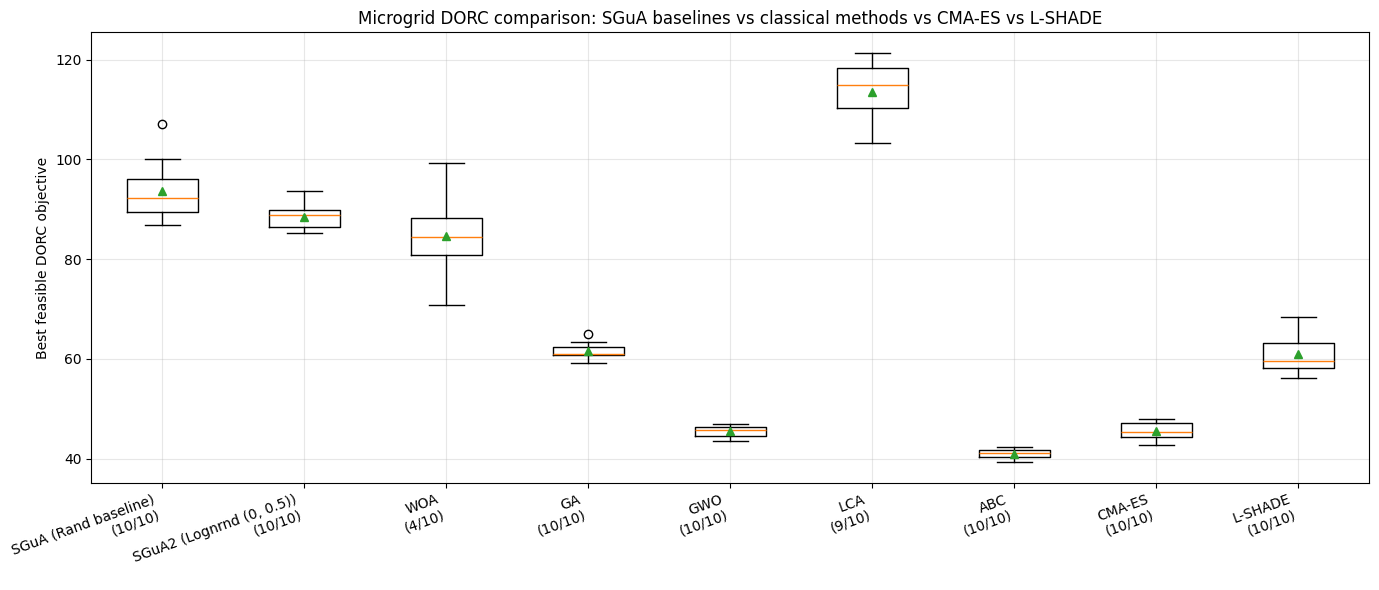

C:\Users\ESEL\AppData\Local\Temp\ipykernel_20472\4178178436.py:2036: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
C:\Users\ESEL\AppData\Local\Programs\Python\Python310\cpu\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\dorc_full_comparison_mean_convergence.png


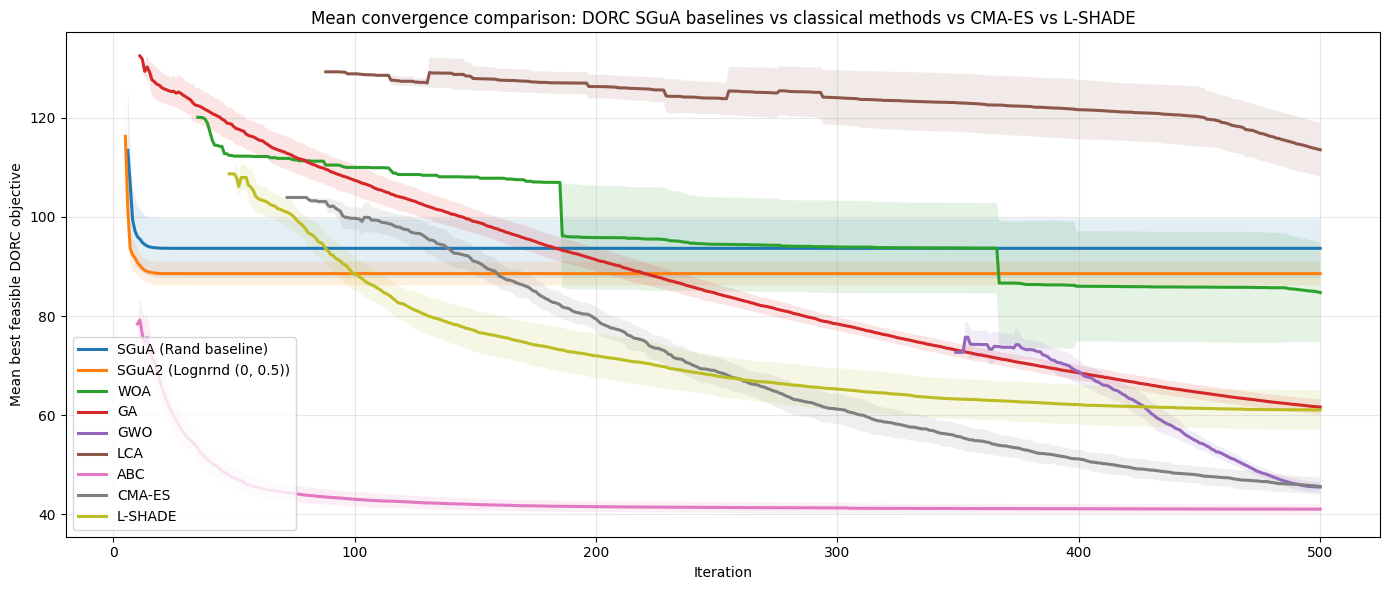

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\dorc_focused_mean_convergence_best_sgua_vs_cmaes_lshade.png


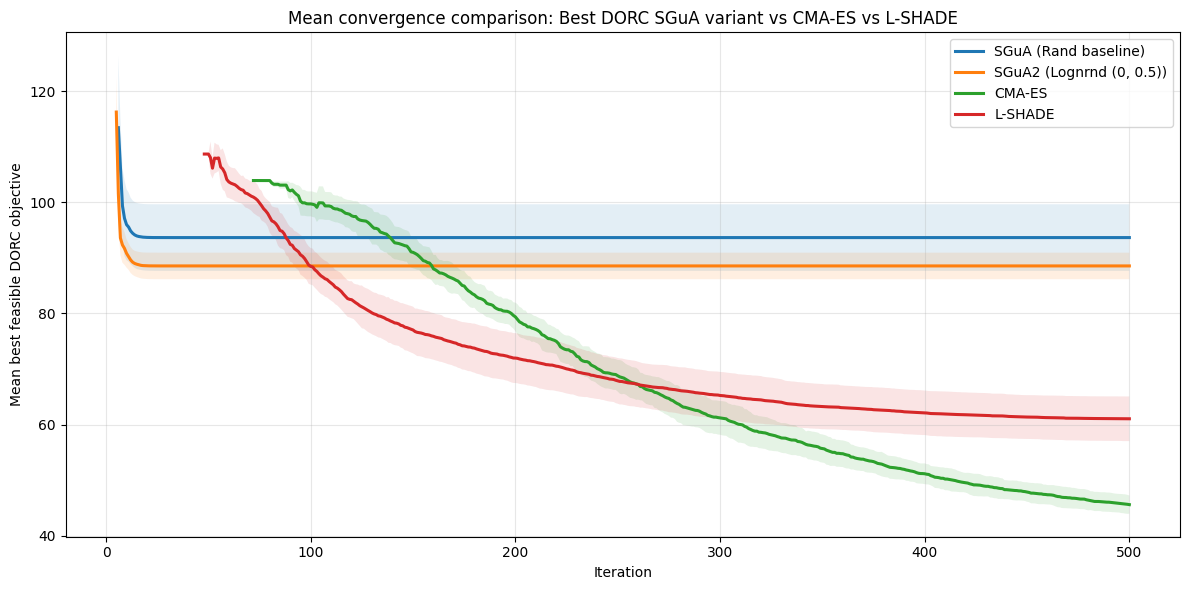

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\dorc_focused_boxplot_best_sgua_vs_cmaes_lshade.png


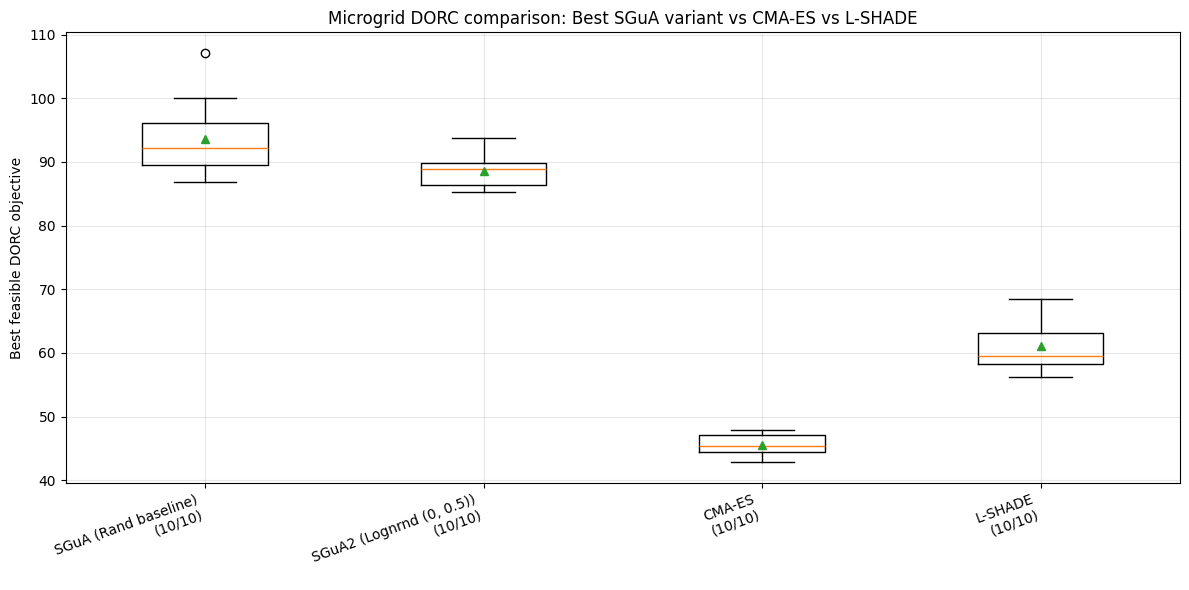

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\dorc_full_comparison_effect_sizes.png


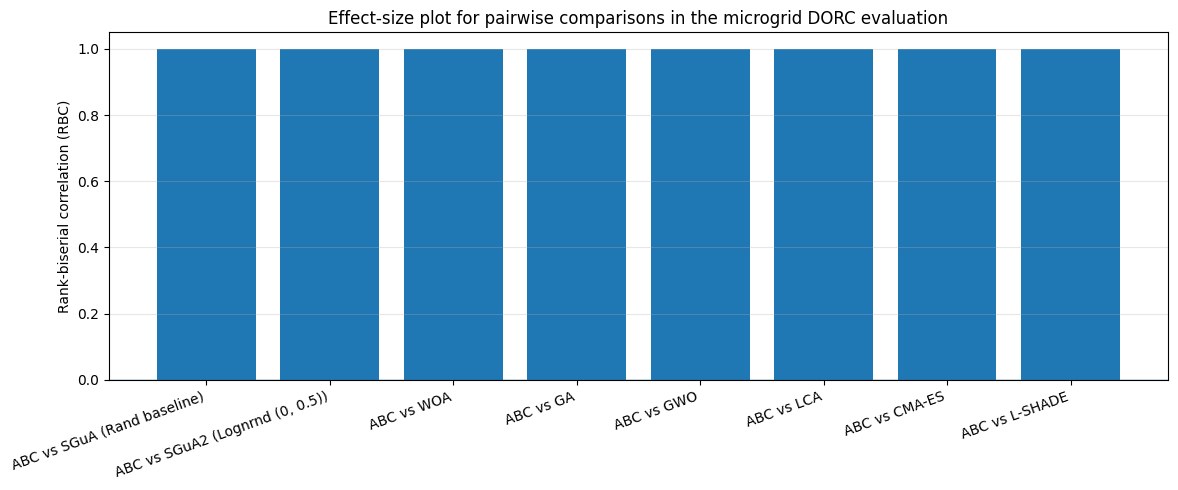

C:\Users\ESEL\AppData\Local\Temp\ipykernel_20472\4178178436.py:2065: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
C:\Users\ESEL\AppData\Local\Programs\Python\Python310\cpu\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\sgua_rand_single_method_mean_convergence.png


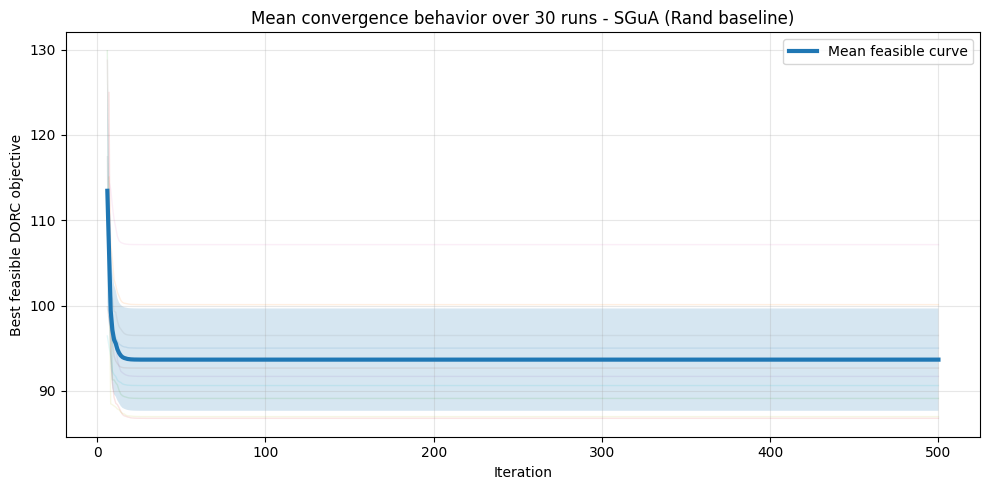

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\sgua2_lognorm_0_0_5_single_method_mean_convergence.png


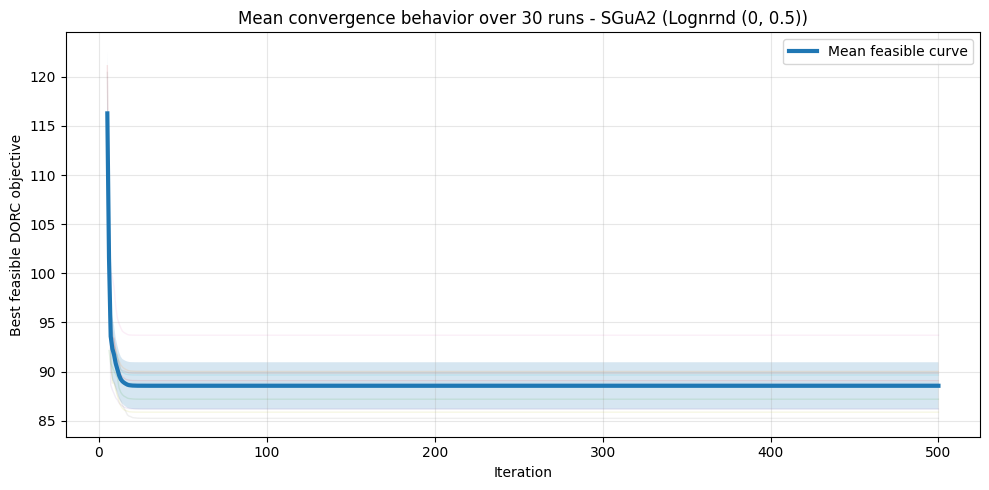

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\cmaes_single_method_mean_convergence.png


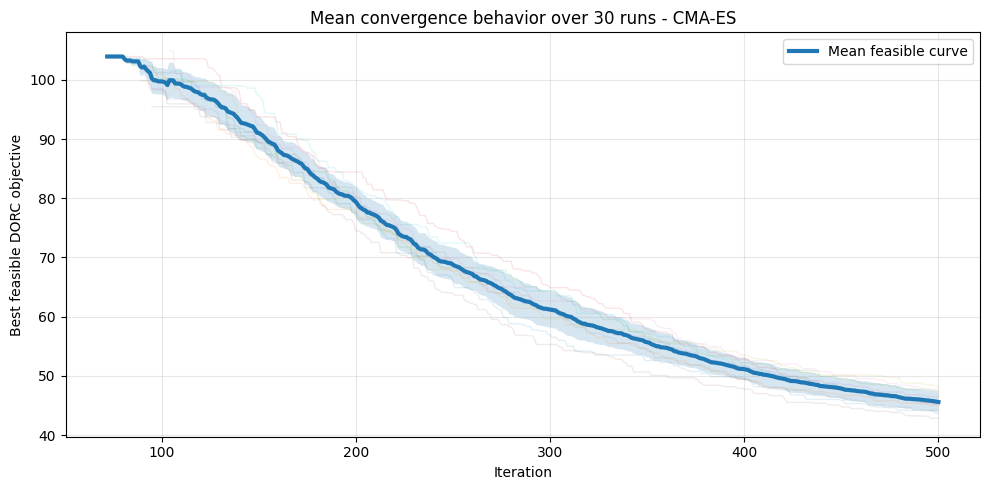

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221\lshade_single_method_mean_convergence.png


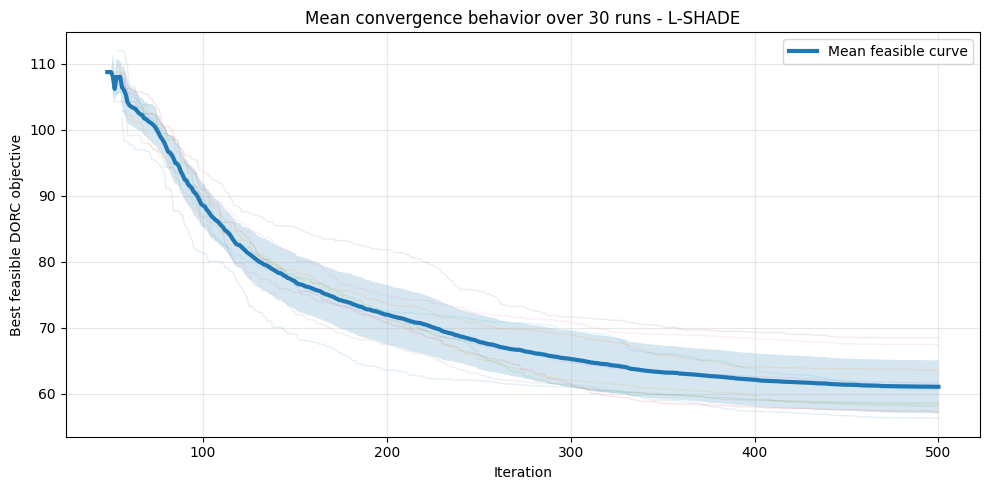


Completed. Output directory:
C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260405_221221


In [2]:
import csv
import re
from pathlib import Path
from datetime import datetime
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, rankdata


SCHEME_DISPLAY_NAMES = {
    "rand": "Rand",
    "uniform": "Unifrnd (0,1)",
    "beta_3_2": "Betarnd (3,2)",
    "beta_2_5_2_5": "Betarnd (2.5, 2.5)",
    "lognorm_0_0_5": "Lognrnd (0, 0.5)",
    "lognorm_0_0_67": "Lognrnd (0, 0.67)",
    "exprnd_0_5": "Exprnd (0.5)",
    "rayleigh_0_4": "Raylrnd (0.4)",
    "weibull_1_1": "Wblrnd (1,1)",
    "lhsdesign": "lhsdesign",
}

ALGORITHM_DISPLAY_NAMES = {
    "SGuA2": "SGuA2",
    "SGuA_RAND": "SGuA (Rand baseline)",
    "CMAES": "CMA-ES",
    "LSHADE": "L-SHADE",
    "WOA": "WOA",
    "GA": "GA",
    "GWO": "GWO",
    "LCA": "LCA",
    "ABC": "ABC",
    "BOA": "BOA",
}


# =========================================================
# MICROGRID DORC PROBLEM (DUAL-SETTING 9-BUS)
# =========================================================

class DORCMicrogridProblem:
    """
    Paper-anchored 9-bus DORC benchmark inspired by:
    Shad et al., Energies 2025, 18, 1601.

    UPDATED: Dual-setting implementation with separate settings
    for grid-connected and islanded operating modes.

    Decision space dimension: 93
      - 23 x td_grid
      - 23 x Ip_grid
      - 23 x td_islanded
      - 23 x Ip_islanded
      - 1 x XFCL

    Important note:
    The original paper reports the Stage-2 DSOR/FCL optimization framework,
    the relay-pair structure, and key engineering constants, but it does not
    provide the full machine-readable short-circuit-current matrices for every
    scenario. Therefore, the current model remains a paper-anchored benchmark
    rather than a byte-for-byte reproduction of the original study.
    """

    def __init__(self, penalty_weight=1e6):
        self.penalty_weight = penalty_weight
        self.tol = 1e-12
        self.A = 0.14
        self.B = 0.02
        self.cti = 0.30

        # Paper-anchored engineering limits
        self.td_min = 0.05
        self.td_max = 1.20
        self.ip_min = 0.50
        self.ip_max = 2.50
        self.xfcl_min = 0.0
        self.xfcl_max = 6.0
        self.ti_min = 0.05
        self.ti_max = 4.00

        self.modes = ["grid_connected", "islanded"]
        self.mode_weights = {"grid_connected": 0.5, "islanded": 0.5}
        self.faults = ["F10", "F11", "F12", "F13", "F14", "F15", "F16", "F17"]
        self.scenarios = [(m, f) for m in self.modes for f in self.faults]

        self.relay_labels = [f"R{i}" for i in range(1, 24)]
        self.relay_index = {r: i for i, r in enumerate(self.relay_labels)}
        self.n_relays = len(self.relay_labels)

        # Table 5: primary-backup relationships in the 9-bus radial MG.
        self.pb_map = {
            "F10": [("R1", ["R10", "R17"]), ("R2", ["R4"])],
            "F11": [("R3", ["R1"]), ("R4", ["R6", "R18", "R20", "R22"])],
            "F12": [("R5", ["R3", "R18", "R20", "R22"]), ("R6", ["R8"])],
            "F13": [("R7", ["R5"]), ("R8", [])],
            "F14": [("R9", ["R2", "R17"]), ("R10", ["R12"])],
            "F15": [("R11", ["R9"]), ("R12", ["R14", "R19", "R21", "R23"])],
            "F16": [("R13", ["R11", "R19", "R21", "R23"]), ("R14", ["R16"])],
            "F17": [("R15", ["R13"]), ("R16", [])],
        }

        # Dual-setting decision vector:
        # [td_grid (23), Ip_grid (23), td_isl (23), Ip_isl (23), XFCL] => 93 variables
        self.lb = np.concatenate([
            np.full(self.n_relays, self.td_min, dtype=float),
            np.full(self.n_relays, self.ip_min, dtype=float),
            np.full(self.n_relays, self.td_min, dtype=float),
            np.full(self.n_relays, self.ip_min, dtype=float),
            np.array([self.xfcl_min], dtype=float),
        ])
        self.ub = np.concatenate([
            np.full(self.n_relays, self.td_max, dtype=float),
            np.full(self.n_relays, self.ip_max, dtype=float),
            np.full(self.n_relays, self.td_max, dtype=float),
            np.full(self.n_relays, self.ip_max, dtype=float),
            np.array([self.xfcl_max], dtype=float),
        ])

        # Paper-anchored base short-circuit levels (p.u.-style reconstruction).
        self.primary_base = {
            "grid_connected": {
                "F10": 12.0, "F11": 11.2, "F12": 10.8, "F13": 10.4,
                "F14": 11.7, "F15": 10.9, "F16": 10.5, "F17": 10.1,
            },
            "islanded": {
                "F10": 7.3, "F11": 6.8, "F12": 6.5, "F13": 6.2,
                "F14": 7.0, "F15": 6.6, "F16": 6.3, "F17": 6.0,
            },
        }
        self.backup_ratio = {"grid_connected": 0.62, "islanded": 0.68}
        self.weak_ratio = {"grid_connected": 0.18, "islanded": 0.22}
        self.fcl_sensitivity = {"grid_connected": 0.08, "islanded": 0.03}

    def split_variables(self, X):
        X = np.atleast_2d(X)
        n = self.n_relays
        td_grid = X[:, :n]
        Ip_grid = X[:, n:2 * n]
        td_isl = X[:, 2 * n:3 * n]
        Ip_isl = X[:, 3 * n:4 * n]
        xfcl = X[:, -1]
        return td_grid, Ip_grid, td_isl, Ip_isl, xfcl

    def _scenario_currents_for_solution(self, X_row, mode, fault):
        _, _, _, _, xfcl_arr = self.split_variables(X_row[None, :])
        xfcl = float(xfcl_arr[0])
        currents = np.full(
            self.n_relays,
            self.weak_ratio[mode] * self.primary_base[mode][fault],
            dtype=float,
        )

        # FCL impact is prominent in grid-connected mode and negligible in islanded mode.
        if mode == "grid_connected":
            reduction = 1.0 / (1.0 + self.fcl_sensitivity[mode] * xfcl)
        else:
            reduction = 1.0

        for prim, backups in self.pb_map[fault]:
            currents[self.relay_index[prim]] = self.primary_base[mode][fault] * reduction
            for b in backups:
                currents[self.relay_index[b]] = (
                    self.primary_base[mode][fault] * self.backup_ratio[mode] * reduction
                )
        return currents

    def _relay_times_for_solution(self, X_row, mode, fault):
        td_grid, Ip_grid, td_isl, Ip_isl, _ = self.split_variables(X_row[None, :])
        if mode == "grid_connected":
            td = td_grid[0]
            Ip = Ip_grid[0]
        else:
            td = td_isl[0]
            Ip = Ip_isl[0]

        I_fault = self._scenario_currents_for_solution(X_row, mode, fault)
        ratio = np.maximum(I_fault / np.maximum(Ip, 1e-12), 1.000001)
        denom = np.power(ratio, self.B) - 1.0
        denom = np.where(np.abs(denom) < 1e-12, 1e-12, denom)
        ti = self.A * td / denom
        return ti

    def compute_ti(self, X):
        X = np.atleast_2d(X)
        rep = []
        for row in X:
            acc = np.zeros(self.n_relays, dtype=float)
            wsum = 0.0
            for mode, fault in self.scenarios:
                w = self.mode_weights[mode] / len(self.faults)
                acc += w * self._relay_times_for_solution(row, mode, fault)
                wsum += w
            rep.append(acc / max(wsum, 1e-12))
        return np.array(rep, dtype=float)

    def evaluate(self, X):
        X = np.atleast_2d(X)
        td_grid, Ip_grid, td_isl, Ip_isl, xfcl = self.split_variables(X)
        representative_ti = self.compute_ti(X)
        objective = np.zeros(X.shape[0], dtype=float)
        penalty = np.zeros(X.shape[0], dtype=float)

        # Variable bounds
        penalty += np.sum(
            np.maximum(0.0, self.td_min - td_grid) ** 2
            + np.maximum(0.0, td_grid - self.td_max) ** 2,
            axis=1,
        )
        penalty += np.sum(
            np.maximum(0.0, self.ip_min - Ip_grid) ** 2
            + np.maximum(0.0, Ip_grid - self.ip_max) ** 2,
            axis=1,
        )
        penalty += np.sum(
            np.maximum(0.0, self.td_min - td_isl) ** 2
            + np.maximum(0.0, td_isl - self.td_max) ** 2,
            axis=1,
        )
        penalty += np.sum(
            np.maximum(0.0, self.ip_min - Ip_isl) ** 2
            + np.maximum(0.0, Ip_isl - self.ip_max) ** 2,
            axis=1,
        )
        penalty += (
            np.maximum(0.0, self.xfcl_min - xfcl) ** 2
            + np.maximum(0.0, xfcl - self.xfcl_max) ** 2
        )

        for r, row in enumerate(X):
            total = 0.0
            for mode, fault in self.scenarios:
                mode_w = self.mode_weights[mode]
                ti = self._relay_times_for_solution(row, mode, fault)
                currents = self._scenario_currents_for_solution(row, mode, fault)
                Ip_active = Ip_grid[r] if mode == "grid_connected" else Ip_isl[r]

                for prim, backups in self.pb_map[fault]:
                    i = self.relay_index[prim]
                    total += mode_w * ti[i]

                    if ti[i] < self.ti_min:
                        penalty[r] += (self.ti_min - ti[i]) ** 2
                    if ti[i] > self.ti_max:
                        penalty[r] += (ti[i] - self.ti_max) ** 2

                    # Primary relay must see current above pickup.
                    pickup_violation = max(0.0, Ip_active[i] - currents[i])
                    penalty[r] += pickup_violation ** 2

                    for b in backups:
                        j = self.relay_index[b]
                        total += mode_w * ti[j]

                        if ti[j] < self.ti_min:
                            penalty[r] += (self.ti_min - ti[j]) ** 2
                        if ti[j] > self.ti_max:
                            penalty[r] += (ti[j] - self.ti_max) ** 2

                        cti_violation = max(0.0, self.cti - (ti[j] - ti[i]))
                        penalty[r] += cti_violation ** 2

            objective[r] = total

        penalized = objective + self.penalty_weight * penalty
        feasible = penalty <= self.tol
        return penalized, objective, feasible, representative_ti

    def check_constraints_from_solution(self, X):
        X = np.atleast_2d(X)
        row = X[0]
        worst_margin = np.inf
        for mode, fault in self.scenarios:
            ti = self._relay_times_for_solution(row, mode, fault)
            for prim, backups in self.pb_map[fault]:
                i = self.relay_index[prim]
                for b in backups:
                    j = self.relay_index[b]
                    worst_margin = min(worst_margin, ti[j] - ti[i])
        rep_ti = self.compute_ti(X)[0]
        return {
            "all_t_range": bool(np.all((rep_ti >= self.ti_min) & (rep_ti <= self.ti_max))),
            "worst_backup_minus_primary": float(worst_margin),
            "cti_ok": bool(worst_margin >= self.cti),
            "representative_ti": rep_ti,
        }


ORCProblem = DORCMicrogridProblem


# =========================================================
# SGuA
# =========================================================

class SGuA:
    def __init__(
        self,
        problem,
        variant="SGuA1",
        P=40,
        G=500,
        branch_mode="linear",
        similarity_tol=1e-3,
        use_orc_guide_seed=False,
        init_scheme="rand",
        r_mode="vector",
        seed=123,
    ):
        self.problem = problem
        self.variant = variant
        self.P = P
        self.G = G
        self.D = len(problem.lb)
        self.branch_mode = branch_mode
        self.similarity_tol = similarity_tol
        self.use_orc_guide_seed = use_orc_guide_seed
        self.init_scheme = init_scheme
        self.r_mode = r_mode

        self.lb = problem.lb.copy()
        self.ub = problem.ub.copy()
        self.span = self.ub - self.lb
        self.max_distance = np.linalg.norm(self.span)
        self.rng = np.random.default_rng(seed)

        self.fe_count = 0
        self.gbest_X = np.zeros(self.D, dtype=float)
        self.gbest_penalized = np.inf
        self.gbest_objective = np.inf
        self.gbest_ti = None
        self.best_feasible_X = None
        self.best_feasible_obj = np.inf
        self.best_feasible_ti = None
        self.best_feasible_curve = np.full(G, np.nan, dtype=float)

    def evaluate_population(self, X):
        penalized, objective, feasible, ti = self.problem.evaluate(X)
        self.fe_count += X.shape[0]
        return penalized, objective, feasible, ti

    def update_bests(self, X, penalized, objective, feasible, ti):
        idx_pen = np.argmin(penalized)
        if penalized[idx_pen] < self.gbest_penalized:
            self.gbest_penalized = penalized[idx_pen]
            self.gbest_objective = objective[idx_pen]
            self.gbest_X = X[idx_pen].copy()
            self.gbest_ti = ti[idx_pen].copy()

        feasible_indices = np.where(feasible)[0]
        if feasible_indices.size > 0:
            local_feasible_obj = objective[feasible_indices]
            best_local_idx = feasible_indices[np.argmin(local_feasible_obj)]
            if objective[best_local_idx] < self.best_feasible_obj:
                self.best_feasible_obj = objective[best_local_idx]
                self.best_feasible_X = X[best_local_idx].copy()
                self.best_feasible_ti = ti[best_local_idx].copy()

    def select_best(self, X):
        penalized, objective, feasible, ti = self.evaluate_population(X)
        self.update_bests(X, penalized, objective, feasible, ti)
        idx = np.argsort(penalized)[: self.P]
        return X[idx].copy()

    def _positive_to_unit(self, x):
        return x / (1.0 + x)

    def _lhs_1d(self, n):
        perm = self.rng.permutation(n)
        return (perm + self.rng.random(n)) / n

    def _draw_r_batch(self, n):
        scheme = self.init_scheme.lower()
        size = n if self.r_mode == "scalar" else (n, self.D)

        if scheme == "rand":
            r = self.rng.random(size)
        elif scheme == "uniform":
            r = self.rng.uniform(0.0, 1.0, size=size)
        elif scheme == "beta_3_2":
            r = self.rng.beta(3.0, 2.0, size=size)
        elif scheme == "beta_2_5_2_5":
            r = self.rng.beta(2.5, 2.5, size=size)
        elif scheme == "lognorm_0_0_5":
            r = self._positive_to_unit(self.rng.lognormal(mean=0.0, sigma=0.5, size=size))
        elif scheme == "lognorm_0_0_67":
            r = self._positive_to_unit(self.rng.lognormal(mean=0.0, sigma=0.67, size=size))
        elif scheme == "exprnd_0_5":
            r = self._positive_to_unit(self.rng.exponential(scale=0.5, size=size))
        elif scheme == "rayleigh_0_4":
            r = self._positive_to_unit(self.rng.rayleigh(scale=0.4, size=size))
        elif scheme == "weibull_1_1":
            r = self._positive_to_unit(self.rng.weibull(a=1.0, size=size))
        elif scheme == "lhsdesign":
            if self.r_mode == "scalar":
                r = self._lhs_1d(n)
            else:
                r = np.column_stack([self._lhs_1d(n) for _ in range(self.D)])
        else:
            raise ValueError(f"Unknown init_scheme: {self.init_scheme}")

        eps = 1e-12
        return np.clip(r, eps, 1.0 - eps)

    def sowing_sapling(self):
        garden = [self.ub.copy(), self.lb.copy()]
        # Removed the old 6-relay targeted seed to avoid incompatibility with the 93-D problem.
        k = 2
        while len(garden) < self.P:
            seg_ids = np.minimum((np.arange(self.D) * k) // self.D, k - 1)
            masks = list(range(1, (2 ** k) - 1))
            masks = masks[: self.P - len(garden)]
            if len(masks) == 0:
                break
            r_batch = self._draw_r_batch(len(masks))
            for idx_mask, mask in enumerate(masks):
                bits = np.array([(mask >> s) & 1 for s in range(k)], dtype=int)
                if self.r_mode == "scalar":
                    r = float(r_batch[idx_mask])
                    coeff = np.where(bits[seg_ids] == 1, r, 1.0 - r)
                else:
                    r = r_batch[idx_mask]
                    coeff = np.where(bits[seg_ids] == 1, r, 1.0 - r)
                x = self.lb + self.span * coeff
                garden.append(np.clip(x, self.lb, self.ub))
            k += 1
        return np.array(garden[: self.P], dtype=float)

    def mating(self, G):
        perm = self.rng.permutation(len(G))
        offspring = []
        for p in range(0, len(G) - 1, 2):
            s1 = G[perm[p]].copy()
            s2 = G[perm[p + 1]].copy()
            distance = np.linalg.norm(s1 - s2)
            pm = max(0.0, 1.0 - distance / (self.max_distance + 1e-12))
            child1 = s1.copy()
            child2 = s2.copy()
            for j in range(self.D):
                if self.rng.random() < pm:
                    child1[j], child2[j] = child2[j], child1[j]
            offspring.append(np.clip(child1, self.lb, self.ub))
            offspring.append(np.clip(child2, self.lb, self.ub))
        if len(G) % 2 == 1:
            offspring.append(G[perm[-1]].copy())
        return np.array(offspring[: self.P], dtype=float)

    def branching_probability(self, distance_index):
        if self.branch_mode == "linear":
            return 1.0 - 1.0 / (distance_index + 1.0)
        return 1.0 - np.exp(-distance_index)

    def branching(self, G):
        offspring = []
        for s in G:
            child = s.copy()
            i = self.rng.integers(0, self.D)
            for j in range(self.D):
                if j == i:
                    continue
                dist_idx = abs(j - i)
                if self.rng.random() < self.branching_probability(dist_idx):
                    child[j] = child[j] + self.rng.random() * (child[i] - child[j])
            offspring.append(np.clip(child, self.lb, self.ub))
        return np.array(offspring[: self.P], dtype=float)

    def vaccinating(self, G):
        perm = self.rng.permutation(len(G))
        offspring = []
        for p in range(0, len(G) - 1, 2):
            s1 = G[perm[p]].copy()
            s2 = G[perm[p + 1]].copy()
            norm_diff = np.abs(s1 - s2) / (self.span + 1e-12)
            dis = np.mean(norm_diff)
            child1 = s1.copy()
            child2 = s2.copy()
            if dis > self.rng.random():
                eq_mask = norm_diff <= self.similarity_tol
                rand1 = self.rng.uniform(self.lb, self.ub)
                rand2 = self.rng.uniform(self.lb, self.ub)
                child1 = np.where(eq_mask, s1, rand1)
                child2 = np.where(eq_mask, s2, rand2)
            offspring.append(np.clip(child1, self.lb, self.ub))
            offspring.append(np.clip(child2, self.lb, self.ub))
        if len(G) % 2 == 1:
            offspring.append(G[perm[-1]].copy())
        return np.array(offspring[: self.P], dtype=float)

    def opt_sgua1(self):
        G = self.sowing_sapling()
        pen, obj, fea, ti = self.evaluate_population(G)
        self.update_bests(G, pen, obj, fea, ti)
        if self.best_feasible_X is not None:
            self.best_feasible_curve[0] = self.best_feasible_obj
        for g in range(1, self.G):
            G1 = self.mating(G)
            G2 = self.branching(G)
            G3 = self.vaccinating(G)
            G = self.select_best(np.vstack([G1, G2, G3, G]))
            if self.best_feasible_X is not None:
                self.best_feasible_curve[g] = self.best_feasible_obj
        return self.finalize_result()

    def opt_sgua2(self):
        G = self.sowing_sapling()
        pen, obj, fea, ti = self.evaluate_population(G)
        self.update_bests(G, pen, obj, fea, ti)
        if self.best_feasible_X is not None:
            self.best_feasible_curve[0] = self.best_feasible_obj
        for g in range(1, self.G):
            G1 = self.mating(G)
            pen1, obj1, fea1, ti1 = self.evaluate_population(G1)
            self.update_bests(G1, pen1, obj1, fea1, ti1)
            Gm = self.select_best(np.vstack([G1, G]))
            G2 = self.branching(Gm)
            pen2, obj2, fea2, ti2 = self.evaluate_population(G2)
            self.update_bests(G2, pen2, obj2, fea2, ti2)
            Gb = self.select_best(np.vstack([G2, Gm]))
            G3 = self.vaccinating(Gb)
            pen3, obj3, fea3, ti3 = self.evaluate_population(G3)
            self.update_bests(G3, pen3, obj3, fea3, ti3)
            G = self.select_best(np.vstack([G3, Gb]))
            if self.best_feasible_X is not None:
                self.best_feasible_curve[g] = self.best_feasible_obj
        return self.finalize_result()

    def finalize_result(self):
        n = self.problem.n_relays
        if self.best_feasible_X is not None:
            final_X = self.best_feasible_X.copy()
            final_ti = self.best_feasible_ti.copy()
            final_obj = self.best_feasible_obj
            feasible_flag = True
        else:
            final_X = self.gbest_X.copy()
            final_ti = self.gbest_ti.copy() if self.gbest_ti is not None else np.full(n, np.nan)
            final_obj = self.gbest_objective
            feasible_flag = False

        return {
            "x": final_X,
            "td_grid": final_X[:n],
            "Ip_grid": final_X[n:2 * n],
            "td_isl": final_X[2 * n:3 * n],
            "Ip_isl": final_X[3 * n:4 * n],
            "xfcl": float(final_X[-1]),
            "Ti": final_ti,
            "best_fitness": final_obj,
            "feasible": feasible_flag,
            "function_evaluations": self.fe_count,
            "feasible_curve": self.best_feasible_curve.copy(),
            "penalized_fitness": self.gbest_penalized,
            "init_scheme": self.init_scheme,
            "algorithm": self.variant,
            "method_key": f"{self.variant}-{self.init_scheme}",
        }

    def opt(self):
        if self.variant == "SGuA1":
            return self.opt_sgua1()
        if self.variant == "SGuA2":
            return self.opt_sgua2()
        raise ValueError("variant must be either 'SGuA1' or 'SGuA2'")


# =========================================================
# COMMON BASE FOR CMA-ES / L-SHADE
# =========================================================

class OptimizerBase:
    def __init__(self, problem, algorithm_name, P=100, G=1000, seed=123):
        self.problem = problem
        self.algorithm_name = algorithm_name
        self.P = P
        self.G = G
        self.D = len(problem.lb)
        self.lb = problem.lb.copy()
        self.ub = problem.ub.copy()
        self.span = self.ub - self.lb
        self.rng = np.random.default_rng(seed)

        self.fe_count = 0
        self.gbest_X = np.zeros(self.D, dtype=float)
        self.gbest_penalized = np.inf
        self.gbest_objective = np.inf
        self.gbest_ti = None
        self.best_feasible_X = None
        self.best_feasible_obj = np.inf
        self.best_feasible_ti = None
        self.best_feasible_curve = np.full(G, np.nan, dtype=float)

    def evaluate_population(self, X):
        penalized, objective, feasible, ti = self.problem.evaluate(X)
        self.fe_count += X.shape[0]
        return penalized, objective, feasible, ti

    def update_bests(self, X, penalized, objective, feasible, ti):
        idx_pen = np.argmin(penalized)
        if penalized[idx_pen] < self.gbest_penalized:
            self.gbest_penalized = penalized[idx_pen]
            self.gbest_objective = objective[idx_pen]
            self.gbest_X = X[idx_pen].copy()
            self.gbest_ti = ti[idx_pen].copy()
        feasible_idx = np.where(feasible)[0]
        if feasible_idx.size > 0:
            best_idx = feasible_idx[np.argmin(objective[feasible_idx])]
            if objective[best_idx] < self.best_feasible_obj:
                self.best_feasible_obj = objective[best_idx]
                self.best_feasible_X = X[best_idx].copy()
                self.best_feasible_ti = ti[best_idx].copy()

    def clip(self, X):
        return np.clip(X, self.lb, self.ub)

    def maybe_store_curve(self, g):
        if self.best_feasible_X is not None:
            self.best_feasible_curve[g] = self.best_feasible_obj

    def finalize_result(self):
        n = self.problem.n_relays
        if self.best_feasible_X is not None:
            final_X = self.best_feasible_X.copy()
            final_ti = self.best_feasible_ti.copy()
            final_obj = self.best_feasible_obj
            feasible_flag = True
        else:
            final_X = self.gbest_X.copy()
            final_ti = self.gbest_ti.copy() if self.gbest_ti is not None else np.full(n, np.nan)
            final_obj = self.gbest_objective
            feasible_flag = False

        return {
            "x": final_X,
            "td_grid": final_X[:n],
            "Ip_grid": final_X[n:2 * n],
            "td_isl": final_X[2 * n:3 * n],
            "Ip_isl": final_X[3 * n:4 * n],
            "xfcl": float(final_X[-1]),
            "Ti": final_ti,
            "best_fitness": final_obj,
            "feasible": feasible_flag,
            "function_evaluations": self.fe_count,
            "feasible_curve": self.best_feasible_curve.copy(),
            "penalized_fitness": self.gbest_penalized,
            "algorithm": self.algorithm_name,
            "method_key": self.algorithm_name,
        }


# =========================================================
# CMA-ES (self-contained bounded adaptation)
# =========================================================

class CMAES(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, sigma0=0.30):
        super().__init__(problem, algorithm_name="CMAES", P=P, G=G, seed=seed)
        self.sigma0 = sigma0

    def opt(self):
        n = self.D
        lam = self.P
        mu = lam // 2
        weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
        weights = weights / np.sum(weights)
        mueff = (np.sum(weights) ** 2) / np.sum(weights ** 2)

        cc = (4 + mueff / n) / (n + 4 + 2 * mueff / n)
        cs = (mueff + 2) / (n + mueff + 5)
        c1 = 2 / ((n + 1.3) ** 2 + mueff)
        cmu = min(1 - c1, 2 * (mueff - 2 + 1 / mueff) / ((n + 2) ** 2 + mueff))
        damps = 1 + 2 * max(0, np.sqrt((mueff - 1) / (n + 1)) - 1) + cs
        chi_n = np.sqrt(n) * (1 - 1 / (4 * n) + 1 / (21 * n * n))

        mean = 0.5 * (self.lb + self.ub)
        sigma = self.sigma0 * np.mean(self.span)
        C = np.eye(n)
        B = np.eye(n)
        Dvals = np.ones(n)
        invsqrtC = np.eye(n)
        pc = np.zeros(n)
        ps = np.zeros(n)

        for g in range(self.G):
            A = B @ np.diag(Dvals)
            arz = self.rng.normal(size=(lam, n))
            ary = arz @ A.T
            arx = self.clip(mean + sigma * ary)

            pen, obj, fea, ti = self.evaluate_population(arx)
            self.update_bests(arx, pen, obj, fea, ti)

            idx = np.argsort(pen)
            x_sel = arx[idx[:mu]]
            z_sel = arz[idx[:mu]]
            y_sel = ary[idx[:mu]]

            old_mean = mean.copy()
            mean = np.sum(weights[:, None] * x_sel, axis=0)
            zmean = np.sum(weights[:, None] * z_sel, axis=0)
            ymean = np.sum(weights[:, None] * y_sel, axis=0)

            ps = (1 - cs) * ps + np.sqrt(cs * (2 - cs) * mueff) * (invsqrtC @ ((mean - old_mean) / max(sigma, 1e-16)))
            norm_ps = np.linalg.norm(ps)
            hsig_cond = norm_ps / np.sqrt(1 - (1 - cs) ** (2 * (g + 1))) / chi_n
            hsig = 1.0 if hsig_cond < (1.4 + 2 / (n + 1)) else 0.0
            pc = (1 - cc) * pc + hsig * np.sqrt(cc * (2 - cc) * mueff) * ((mean - old_mean) / max(sigma, 1e-16))

            artmp = (x_sel - old_mean) / max(sigma, 1e-16)
            C = (1 - c1 - cmu) * C + c1 * (np.outer(pc, pc) + (1 - hsig) * cc * (2 - cc) * C)
            for wi, yi in zip(weights, artmp):
                C += cmu * wi * np.outer(yi, yi)
            C = 0.5 * (C + C.T)

            sigma *= np.exp((cs / damps) * (norm_ps / chi_n - 1))
            sigma = max(sigma, 1e-12)

            eigvals, eigvecs = np.linalg.eigh(C)
            eigvals = np.maximum(eigvals, 1e-20)
            Dvals = np.sqrt(eigvals)
            B = eigvecs
            invsqrtC = B @ np.diag(1.0 / Dvals) @ B.T

            self.maybe_store_curve(g)

        return self.finalize_result()


# =========================================================
# L-SHADE (compact self-contained variant)
# =========================================================

class LSHADE(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, memory_size=6, pbest_rate=0.11, min_pop_size=4):
        super().__init__(problem, algorithm_name="LSHADE", P=P, G=G, seed=seed)
        self.memory_size = memory_size
        self.pbest_rate = pbest_rate
        self.min_pop_size = min_pop_size

    def _sample_F(self, mu_F):
        while True:
            F = mu_F + 0.1 * np.tan(np.pi * (self.rng.random() - 0.5))
            if F > 0:
                return min(F, 1.0)

    def _sample_CR(self, mu_CR):
        cr = self.rng.normal(mu_CR, 0.1)
        return float(np.clip(cr, 0.0, 1.0))

    def opt(self):
        NP_init = self.P
        NP = self.P
        D = self.D
        H = self.memory_size
        M_F = np.full(H, 0.5, dtype=float)
        M_CR = np.full(H, 0.5, dtype=float)
        memory_idx = 0

        pop = self.rng.uniform(self.lb, self.ub, size=(NP, D))
        pen, obj, fea, ti = self.evaluate_population(pop)
        self.update_bests(pop, pen, obj, fea, ti)
        archive = np.empty((0, D), dtype=float)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            pop = pop[order]
            pen = pen[order]
            obj = obj[order]
            fea = fea[order]
            ti = ti[order]

            p_num = max(2, int(np.ceil(self.pbest_rate * NP)))
            p_num = min(p_num, NP)

            F_list = np.zeros(NP, dtype=float)
            CR_list = np.zeros(NP, dtype=float)
            trial = np.zeros_like(pop)

            all_pool = np.vstack([pop, archive]) if len(archive) > 0 else pop.copy()

            for i in range(NP):
                r = self.rng.integers(0, H)
                Fi = self._sample_F(M_F[r])
                CRi = self._sample_CR(M_CR[r])
                F_list[i] = Fi
                CR_list[i] = CRi

                pbest_idx = self.rng.integers(0, p_num)
                xpbest = pop[pbest_idx]

                idx_choices = np.delete(np.arange(NP), i)
                r1 = self.rng.choice(idx_choices)
                xr1 = pop[r1]

                pool_indices = np.arange(all_pool.shape[0])
                invalid = {i, r1}
                valid_pool = [idx for idx in pool_indices if idx not in invalid]
                if len(valid_pool) == 0:
                    xr2 = pop[self.rng.integers(0, NP)]
                else:
                    xr2 = all_pool[self.rng.choice(valid_pool)]

                mutant = pop[i] + Fi * (xpbest - pop[i]) + Fi * (xr1 - xr2)
                mutant = self.clip(mutant)

                jrand = self.rng.integers(0, D)
                cross_mask = self.rng.random(D) < CRi
                cross_mask[jrand] = True
                trial[i] = np.where(cross_mask, mutant, pop[i])

            t_pen, t_obj, t_fea, t_ti = self.evaluate_population(trial)
            self.update_bests(trial, t_pen, t_obj, t_fea, t_ti)

            S_F = []
            S_CR = []
            delta_f = []
            next_pop = []
            next_pen = []
            next_obj = []
            next_fea = []
            next_ti = []

            for i in range(NP):
                if t_pen[i] <= pen[i]:
                    archive = np.vstack([archive, pop[i].copy()])
                    next_pop.append(trial[i].copy())
                    next_pen.append(t_pen[i])
                    next_obj.append(t_obj[i])
                    next_fea.append(t_fea[i])
                    next_ti.append(t_ti[i].copy())
                    improvement = abs(pen[i] - t_pen[i])
                    if improvement > 0:
                        S_F.append(F_list[i])
                        S_CR.append(CR_list[i])
                        delta_f.append(improvement)
                else:
                    next_pop.append(pop[i].copy())
                    next_pen.append(pen[i])
                    next_obj.append(obj[i])
                    next_fea.append(fea[i])
                    next_ti.append(ti[i].copy())

            pop = np.array(next_pop, dtype=float)
            pen = np.array(next_pen, dtype=float)
            obj = np.array(next_obj, dtype=float)
            fea = np.array(next_fea, dtype=bool)
            ti = np.array(next_ti, dtype=float)
            NP = len(pop)

            if archive.shape[0] > NP_init:
                keep = self.rng.choice(np.arange(archive.shape[0]), size=NP_init, replace=False)
                archive = archive[keep]

            if len(S_F) > 0:
                w = np.array(delta_f, dtype=float)
                w = w / np.sum(w)
                S_F = np.array(S_F, dtype=float)
                S_CR = np.array(S_CR, dtype=float)
                new_MF = np.sum(w * (S_F ** 2)) / max(np.sum(w * S_F), 1e-16)
                new_MCR = np.sum(w * S_CR)
                M_F[memory_idx] = np.clip(new_MF, 1e-6, 1.0)
                M_CR[memory_idx] = np.clip(new_MCR, 0.0, 1.0)
                memory_idx = (memory_idx + 1) % H

            NP_target = int(round(self.min_pop_size + (NP_init - self.min_pop_size) * (1 - g / max(self.G - 1, 1))))
            NP_target = max(self.min_pop_size, min(NP_target, len(pop)))
            if len(pop) > NP_target:
                order = np.argsort(pen)
                pop = pop[order[:NP_target]]
                pen = pen[order[:NP_target]]
                obj = obj[order[:NP_target]]
                fea = fea[order[:NP_target]]
                ti = ti[order[:NP_target]]
                NP = NP_target
                if archive.shape[0] > NP_init:
                    archive = archive[:NP_init]

            self.maybe_store_curve(g)

        return self.finalize_result()




# =========================================================
# WOA
# =========================================================

class WOA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, b=1.0):
        super().__init__(problem, "WOA", P=P, G=G, seed=seed)
        self.b = b

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            a = 2.0 - 2.0 * g / max(self.G - 1, 1)
            best = self.best_feasible_X if self.best_feasible_X is not None else self.gbest_X
            X_new = np.zeros_like(X)
            for i in range(self.P):
                r1 = self.rng.random(self.D)
                r2 = self.rng.random(self.D)
                A = 2 * a * r1 - a
                C = 2 * r2
                p = self.rng.random()
                l = self.rng.uniform(-1.0, 1.0)
                if p < 0.5:
                    if np.mean(np.abs(A)) < 1.0:
                        D = np.abs(C * best - X[i])
                        X_new[i] = best - A * D
                    else:
                        rand_idx = self.rng.integers(0, self.P)
                        X_rand = X[rand_idx]
                        D = np.abs(C * X_rand - X[i])
                        X_new[i] = X_rand - A * D
                else:
                    D = np.abs(best - X[i])
                    X_new[i] = D * np.exp(self.b * l) * np.cos(2 * np.pi * l) + best
            X = self.clip(X_new)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# GWO
# =========================================================

class GWO(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123):
        super().__init__(problem, "GWO", P=P, G=G, seed=seed)

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            alpha = X[order[0]].copy()
            beta = X[order[1]].copy()
            delta = X[order[2]].copy()
            a = 2.0 - 2.0 * g / max(self.G - 1, 1)

            X_new = np.zeros_like(X)
            for i in range(self.P):
                r1 = self.rng.random((3, self.D))
                r2 = self.rng.random((3, self.D))
                A1 = 2 * a * r1[0] - a
                C1 = 2 * r2[0]
                A2 = 2 * a * r1[1] - a
                C2 = 2 * r2[1]
                A3 = 2 * a * r1[2] - a
                C3 = 2 * r2[2]
                X1 = alpha - A1 * np.abs(C1 * alpha - X[i])
                X2 = beta - A2 * np.abs(C2 * beta - X[i])
                X3 = delta - A3 * np.abs(C3 * delta - X[i])
                X_new[i] = (X1 + X2 + X3) / 3.0
            X = self.clip(X_new)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# GA
# =========================================================

class GA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, crossover_rate=0.9, mutation_rate=None, elite_count=2):
        super().__init__(problem, "GA", P=P, G=G, seed=seed)
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate if mutation_rate is not None else 1.0 / self.D
        self.elite_count = elite_count

    def tournament_select(self, X: np.ndarray, pen: np.ndarray, k: int = 3) -> np.ndarray:
        idx = self.rng.choice(len(X), size=k, replace=False)
        return X[idx[np.argmin(pen[idx])]].copy()

    def crossover(self, p1: np.ndarray, p2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if self.rng.random() >= self.crossover_rate:
            return p1.copy(), p2.copy()
        alpha = self.rng.random(self.D)
        c1 = alpha * p1 + (1 - alpha) * p2
        c2 = alpha * p2 + (1 - alpha) * p1
        return c1, c2

    def mutate(self, x: np.ndarray, g: int) -> np.ndarray:
        sigma = 0.10 * (1 - g / max(self.G - 1, 1)) + 0.01
        mask = self.rng.random(self.D) < self.mutation_rate
        noise = self.rng.normal(0.0, sigma, self.D) * self.span
        y = x.copy()
        y[mask] += noise[mask]
        return self.clip(y)

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            elites = X[order[: self.elite_count]].copy()
            next_pop = [e.copy() for e in elites]

            while len(next_pop) < self.P:
                p1 = self.tournament_select(X, pen)
                p2 = self.tournament_select(X, pen)
                c1, c2 = self.crossover(p1, p2)
                c1 = self.mutate(c1, g)
                c2 = self.mutate(c2, g)
                next_pop.append(c1)
                if len(next_pop) < self.P:
                    next_pop.append(c2)
            X = np.array(next_pop, dtype=float)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# BOA
# =========================================================

class BOA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, sensory_modality=0.01, power_exponent=0.1, switch_probability=0.8):
        super().__init__(problem, "BOA", P=P, G=G, seed=seed)
        self.c = sensory_modality
        self.a = power_exponent
        self.p = switch_probability

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            best = self.best_feasible_X if self.best_feasible_X is not None else self.gbest_X
            intensity = 1.0 / (1.0 + np.maximum(pen, 0.0))
            fragrance = self.c * np.power(intensity, self.a)
            X_new = np.zeros_like(X)
            for i in range(self.P):
                r = self.rng.random(self.D)
                if self.rng.random() < self.p:
                    step = (r * r) * best - X[i]
                    X_new[i] = X[i] + fragrance[i] * step
                else:
                    j, k = self.rng.choice(self.P, size=2, replace=False)
                    step = (r * r) * X[j] - X[k]
                    X_new[i] = X[i] + fragrance[i] * step
            X = self.clip(X_new)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.c = self.c + 0.025 / (self.c * self.G)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# ABC
# =========================================================

class ABC(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, limit=None):
        super().__init__(problem, "ABC", P=P, G=G, seed=seed)
        self.limit = limit if limit is not None else max(20, self.D * 3)

    def opt(self):
        food = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(food)
        self.update_bests(food, pen, obj, fea, ti)
        trial = np.zeros(self.P, dtype=int)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            # employed bees
            for i in range(self.P):
                k = self.rng.choice([idx for idx in range(self.P) if idx != i])
                j = self.rng.integers(0, self.D)
                phi = self.rng.uniform(-1.0, 1.0)
                candidate = food[i].copy()
                candidate[j] = food[i, j] + phi * (food[i, j] - food[k, j])
                candidate = self.clip(candidate)
                c_pen, c_obj, c_fea, c_ti = self.evaluate_population(candidate[None, :])
                self.update_bests(candidate[None, :], c_pen, c_obj, c_fea, c_ti)
                if c_pen[0] <= pen[i]:
                    food[i] = candidate
                    pen[i], obj[i], fea[i], ti[i] = c_pen[0], c_obj[0], c_fea[0], c_ti[0]
                    trial[i] = 0
                else:
                    trial[i] += 1

            # onlooker bees
            fitness = 1.0 / (1.0 + np.maximum(pen - np.min(pen), 0.0))
            probs = fitness / np.sum(fitness)
            for _ in range(self.P):
                i = self.rng.choice(self.P, p=probs)
                k = self.rng.choice([idx for idx in range(self.P) if idx != i])
                j = self.rng.integers(0, self.D)
                phi = self.rng.uniform(-1.0, 1.0)
                candidate = food[i].copy()
                candidate[j] = food[i, j] + phi * (food[i, j] - food[k, j])
                candidate = self.clip(candidate)
                c_pen, c_obj, c_fea, c_ti = self.evaluate_population(candidate[None, :])
                self.update_bests(candidate[None, :], c_pen, c_obj, c_fea, c_ti)
                if c_pen[0] <= pen[i]:
                    food[i] = candidate
                    pen[i], obj[i], fea[i], ti[i] = c_pen[0], c_obj[0], c_fea[0], c_ti[0]
                    trial[i] = 0
                else:
                    trial[i] += 1

            # scout bees
            scouts = np.where(trial >= self.limit)[0]
            for i in scouts:
                food[i] = self.rng.uniform(self.lb, self.ub, size=self.D)
                p_i, o_i, f_i, t_i = self.evaluate_population(food[i][None, :])
                self.update_bests(food[i][None, :], p_i, o_i, f_i, t_i)
                pen[i], obj[i], fea[i], ti[i] = p_i[0], o_i[0], f_i[0], t_i[0]
                trial[i] = 0

            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# LCA (compact self-contained variant)
# =========================================================

class LCA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, momentum=0.6, noise_scale=0.08):
        super().__init__(problem, "LCA", P=P, G=G, seed=seed)
        self.momentum = momentum
        self.noise_scale = noise_scale

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        velocity = self.rng.normal(0.0, 0.05, size=(self.P, self.D)) * self.span
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            X = X[order]
            pen = pen[order]
            obj = obj[order]
            fea = fea[order]
            ti = ti[order]
            velocity = velocity[order]
            best = self.best_feasible_X if self.best_feasible_X is not None else self.gbest_X

            perm = self.rng.permutation(self.P)
            X_new = X.copy()
            vel_new = velocity.copy()
            for a, b in perm.reshape(-1, 2) if self.P % 2 == 0 else []:
                # original indices after permutation order mapping
                ia, ib = a, b
                if pen[ia] <= pen[ib]:
                    winner, loser = ia, ib
                else:
                    winner, loser = ib, ia
                learn = self.rng.random(self.D)
                noise = self.rng.normal(0.0, self.noise_scale, self.D) * self.span * (1 - g / max(self.G - 1, 1))
                vel_new[loser] = self.momentum * velocity[loser] + learn * (X[winner] - X[loser]) + noise
                X_new[loser] = X[loser] + vel_new[loser]
                vel_new[winner] = 0.5 * velocity[winner] + 0.3 * self.rng.random(self.D) * (best - X[winner])
                X_new[winner] = X[winner] + vel_new[winner]

            # if odd population, update last one toward best
            if self.P % 2 == 1:
                i = perm[-1]
                vel_new[i] = self.momentum * velocity[i] + 0.4 * self.rng.random(self.D) * (best - X[i])
                X_new[i] = X[i] + vel_new[i]

            X = self.clip(X_new)
            velocity = vel_new
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()



# =========================================================
# GENERIC RUNNERS
# =========================================================

def get_scheme_display_name(scheme):
    return SCHEME_DISPLAY_NAMES.get(scheme, scheme)


def get_algorithm_display_name(algorithm_key):
    return ALGORITHM_DISPLAY_NAMES.get(algorithm_key, algorithm_key)


def get_best_feasible_run(results):
    feasible_results = [r for r in results if r["feasible"]]
    if len(feasible_results) == 0:
        return None
    return min(feasible_results, key=lambda x: x["best_fitness"])


def summarize_results(all_results, method_key=None, display_name=None):
    feasible_results = [r for r in all_results if r["feasible"]]
    total_runs = len(all_results)
    best_run = get_best_feasible_run(all_results)
    if len(feasible_results) == 0:
        return {
            "method_key": method_key,
            "display_name": display_name if display_name is not None else method_key,
            "feasible_runs": 0,
            "total_runs": total_runs,
            "mean_best": np.nan,
            "std_best": np.nan,
            "min_best": np.nan,
            "max_best": np.nan,
            "median_best": np.nan,
            "best_run": None,
            "all_feasible_values": np.array([], dtype=float),
        }
    vals = np.array([r["best_fitness"] for r in feasible_results], dtype=float)
    return {
        "method_key": method_key,
        "display_name": display_name if display_name is not None else method_key,
        "feasible_runs": len(feasible_results),
        "total_runs": total_runs,
        "mean_best": np.mean(vals),
        "std_best": np.std(vals),
        "min_best": np.min(vals),
        "max_best": np.max(vals),
        "median_best": np.median(vals),
        "best_run": best_run,
        "all_feasible_values": vals,
    }


def run_multiple_experiments(
    variant="SGuA2",
    init_scheme="rand",
    r_mode="vector",
    n_runs=30,
    P=100,
    G=1000,
    penalty_weight=1e6,
    base_seed=123,
    use_orc_guide_seed=False,
):
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = SGuA(
            problem=problem,
            variant=variant,
            P=P,
            G=G,
            branch_mode="linear",
            similarity_tol=1e-3,
            use_orc_guide_seed=use_orc_guide_seed,
            init_scheme=init_scheme,
            r_mode=r_mode,
            seed=seed,
        )
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | {variant} | {init_scheme} | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | {variant} | {init_scheme} | Feasible: False | No feasible solution found")
    return problem, all_results


def run_cmaes_experiments(n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123):
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = CMAES(problem=problem, P=P, G=G, seed=seed)
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | CMA-ES | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | CMA-ES | Feasible: False | No feasible solution found")
    return problem, all_results


def run_lshade_experiments(n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123):
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = LSHADE(problem=problem, P=P, G=G, seed=seed)
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | L-SHADE | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | L-SHADE | Feasible: False | No feasible solution found")
    return problem, all_results


def run_all_initializations_original_sgua(
    variant="SGuA2",
    r_mode="vector",
    n_runs=30,
    P=100,
    G=1000,
    penalty_weight=1e6,
    base_seed=123,
    use_orc_guide_seed=False,
):
    init_schemes = [
        "rand",
        "uniform",
        "beta_3_2",
        "beta_2_5_2_5",
        "lognorm_0_0_5",
        "lognorm_0_0_67",
        "exprnd_0_5",
        "rayleigh_0_4",
        "weibull_1_1",
        "lhsdesign",
    ]

    all_experiments = {}
    summaries = []
    problem_ref = None

    print("\n" + "=" * 100)
    print(f"ORIGINAL SGuA SOWING + DIFFERENT r SCHEMES ({variant})")
    print("=" * 100)

    for scheme in init_schemes:
        print("\n" + "-" * 100)
        print(f"Init scheme inside ORIGINAL SGuA sowing: {scheme}")
        print("-" * 100)
        problem, results = run_multiple_experiments(
            variant=variant,
            init_scheme=scheme,
            r_mode=r_mode,
            n_runs=n_runs,
            P=P,
            G=G,
            penalty_weight=penalty_weight,
            base_seed=base_seed,
            use_orc_guide_seed=use_orc_guide_seed,
        )
        summary = summarize_results(results, method_key=scheme, display_name=get_scheme_display_name(scheme))
        all_experiments[scheme] = results
        summaries.append(summary)
        problem_ref = problem
        mean_str = f"{summary['mean_best']:.6f}" if np.isfinite(summary["mean_best"]) else "nan"
        std_str = f"{summary['std_best']:.6f}" if np.isfinite(summary["std_best"]) else "nan"
        min_str = f"{summary['min_best']:.6f}" if np.isfinite(summary["min_best"]) else "nan"
        max_str = f"{summary['max_best']:.6f}" if np.isfinite(summary["max_best"]) else "nan"
        print(f"Summary | {scheme} | Feasible: {summary['feasible_runs']}/{summary['total_runs']} | Mean: {mean_str} | Std: {std_str} | Min: {min_str} | Max: {max_str}")
    return problem_ref, all_experiments, summaries


def choose_best_sgua_scheme(summaries):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    if len(valid) == 0:
        return None
    return min(valid, key=lambda s: s["mean_best"])["method_key"]


# =========================================================
# CSV EXPORT HELPERS (INTEGRATED)
# =========================================================

def build_runs_dataframe(results):
    rows = []
    for r in results:
        row = {
            "run_id": r["run_id"],
            "seed": r["seed"],
            "feasible": r["feasible"],
            "best_fitness": r["best_fitness"],
            "penalized_fitness": r["penalized_fitness"],
            "function_evaluations": r["function_evaluations"],
            "xfcl": float(r["xfcl"]),
        }
        n_relays = len(r["td_grid"])
        for i in range(n_relays):
            row[f"td_grid_{i+1}"] = r["td_grid"][i]
            row[f"Ip_grid_{i+1}"] = r["Ip_grid"][i]
            row[f"td_isl_{i+1}"] = r["td_isl"][i]
            row[f"Ip_isl_{i+1}"] = r["Ip_isl"][i]
            row[f"Ti_{i+1}"] = r["Ti"][i]
        rows.append(row)
    return pd.DataFrame(rows)


def build_convergence_dataframe(results):
    curves = np.array([r["feasible_curve"] for r in results], dtype=float)
    df = pd.DataFrame(curves.T)
    df.index = np.arange(1, curves.shape[1] + 1)
    df.index.name = "iteration"
    df.columns = [f"run_{i+1}" for i in range(curves.shape[0])]
    return df


def save_method_outputs(results, run_csv_name, conv_csv_name):
    runs_df = build_runs_dataframe(results)
    conv_df = build_convergence_dataframe(results)
    runs_df.to_csv(run_csv_name, index=False, encoding="utf-8-sig")
    conv_df.to_csv(conv_csv_name, encoding="utf-8-sig")
    print(f"Saved run results: {run_csv_name}")
    print(f"Saved convergence curves: {conv_csv_name}")


def save_rand_baseline_outputs(all_experiments):
    if "rand" in all_experiments:
        save_method_outputs(
            all_experiments["rand"],
            "sgua_dorc_run_results.csv",
            "sgua_dorc_feasible_curves.csv",
        )


def run_method_comparison_with_csv(best_sgua_scheme, n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123, r_mode="vector"):
    method_experiments = {}
    method_summaries = []
    problem_ref = None

    print("\n" + "=" * 100)
    print("COMPARATIVE PAPER-ANCHORED 9-BUS DORC EVALUATION: BEST SGuA VARIANT vs CMA-ES vs L-SHADE")
    print("=" * 100)

    print("\n" + "-" * 100)
    print(f"Selected SGuA baseline for comparison: {best_sgua_scheme}")
    print("-" * 100)
    problem_ref, sgua_results = run_multiple_experiments(
        variant="SGuA2",
        init_scheme=best_sgua_scheme,
        r_mode=r_mode,
        n_runs=n_runs,
        P=P,
        G=G,
        penalty_weight=penalty_weight,
        base_seed=base_seed,
        use_orc_guide_seed=False,
    )
    method_experiments[f"SGuA2-{best_sgua_scheme}"] = sgua_results
    method_summaries.append(summarize_results(sgua_results, method_key=f"SGuA2-{best_sgua_scheme}", display_name=f"SGuA2 ({get_scheme_display_name(best_sgua_scheme)})"))
    save_method_outputs(sgua_results, "lhsdesign_orc_run_results.csv", "lhsdesign_orc_feasible_curves.csv")

    print("\n" + "-" * 100)
    print("CMA-ES runs")
    print("-" * 100)
    _, cma_results = run_cmaes_experiments(n_runs=n_runs, P=P, G=G, penalty_weight=penalty_weight, base_seed=base_seed)
    method_experiments["CMAES"] = cma_results
    method_summaries.append(summarize_results(cma_results, method_key="CMAES", display_name=get_algorithm_display_name("CMAES")))
    save_method_outputs(cma_results, "cmaes_dorc_run_results.csv", "cmaes_dorc_feasible_curves.csv")

    print("\n" + "-" * 100)
    print("L-SHADE runs")
    print("-" * 100)
    _, lshade_results = run_lshade_experiments(n_runs=n_runs, P=P, G=G, penalty_weight=penalty_weight, base_seed=base_seed)
    method_experiments["LSHADE"] = lshade_results
    method_summaries.append(summarize_results(lshade_results, method_key="LSHADE", display_name=get_algorithm_display_name("LSHADE")))
    save_method_outputs(lshade_results, "lshade_dorc_run_results.csv", "lshade_dorc_feasible_curves.csv")

    return problem_ref, method_experiments, method_summaries


# =========================================================
# TABLES AND STATS
# =========================================================

def format_relay_quintet(td_grid, ip_grid, td_isl, ip_isl, ti):
    return f"{td_grid:.4f} / {ip_grid:.2f} / {td_isl:.4f} / {ip_isl:.2f} / {ti:.4f}"


def build_publication_table(summaries, first_col_name="Distribution Method"):
    rows = []
    max_relays = 0
    for summary in summaries:
        best_run = summary.get("best_run", None)
        if best_run is not None:
            max_relays = max(max_relays, len(best_run["td_grid"]))

    for summary in summaries:
        best_run = summary.get("best_run", None)
        row = {
            first_col_name: summary["display_name"],
            "XFCL": np.nan if best_run is None else float(best_run["xfcl"]),
            "Total objective": np.nan if best_run is None else float(best_run["best_fitness"]),
        }
        if best_run is None:
            for i in range(max_relays):
                row[f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)"] = "NO FEASIBLE SOLUTION"
        else:
            for i in range(max_relays):
                if i < len(best_run["td_grid"]):
                    row[f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)"] = format_relay_quintet(
                        best_run["td_grid"][i],
                        best_run["Ip_grid"][i],
                        best_run["td_isl"][i],
                        best_run["Ip_isl"][i],
                        best_run["Ti"][i],
                    )
                else:
                    row[f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)"] = "-"
        rows.append(row)

    cols = [first_col_name] + [f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)" for i in range(max_relays)] + ["XFCL", "Total objective"]
    return pd.DataFrame(rows, columns=cols)


def print_publication_table(publication_df, title_line, first_col_name="Distribution Method"):
    print("\n" + "=" * 140)
    print(title_line)
    print("=" * 140)
    print(publication_df.to_string(index=False))


def get_paired_feasible_values(results_ref, results_cmp):
    ref_map = {r["run_id"]: r["best_fitness"] for r in results_ref if r["feasible"]}
    cmp_map = {r["run_id"]: r["best_fitness"] for r in results_cmp if r["feasible"]}
    common_run_ids = sorted(set(ref_map.keys()).intersection(cmp_map.keys()))
    if len(common_run_ids) == 0:
        return common_run_ids, np.array([], dtype=float), np.array([], dtype=float)
    ref_vals = np.array([ref_map[rid] for rid in common_run_ids], dtype=float)
    cmp_vals = np.array([cmp_map[rid] for rid in common_run_ids], dtype=float)
    return common_run_ids, ref_vals, cmp_vals


def bonferroni_correction(p_values):
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    if m == 0:
        return p_values
    return np.minimum(1.0, p_values * m)


def compute_rank_biserial_from_differences(differences):
    differences = np.asarray(differences, dtype=float)
    non_zero = differences[np.abs(differences) > 1e-15]
    if non_zero.size == 0:
        return 0.0, 0.0, 0.0, 0
    abs_diff = np.abs(non_zero)
    ranks = rankdata(abs_diff, method="average")
    w_pos = np.sum(ranks[non_zero > 0])
    w_neg = np.sum(ranks[non_zero < 0])
    rbc = (w_pos - w_neg) / (w_pos + w_neg)
    return float(rbc), float(w_pos), float(w_neg), int(non_zero.size)


def effect_size_label(abs_effect):
    if abs_effect < 0.10:
        return "negligible"
    if abs_effect < 0.30:
        return "small"
    if abs_effect < 0.50:
        return "medium"
    return "large"


def build_wilcoxon_statistics_table(all_experiments, summaries, reference_method=None, alpha=0.05):
    valid_summaries = [s for s in summaries if np.isfinite(s["mean_best"])]
    if len(valid_summaries) < 2:
        return pd.DataFrame()
    if reference_method is None:
        reference_method = min(valid_summaries, key=lambda x: x["mean_best"])["method_key"]

    comparisons = []
    raw_p_values = []
    for summary in valid_summaries:
        comparator = summary["method_key"]
        if comparator == reference_method:
            continue
        _, ref_vals, cmp_vals = get_paired_feasible_values(all_experiments[reference_method], all_experiments[comparator])
        if len(ref_vals) < 3:
            comparisons.append({
                "reference_method": reference_method,
                "comparator_method": comparator,
                "reference_display": next(s["display_name"] for s in valid_summaries if s["method_key"] == reference_method),
                "comparator_display": summary["display_name"],
                "n_pairs": len(ref_vals),
                "ref_mean": np.nan if len(ref_vals) == 0 else float(np.mean(ref_vals)),
                "cmp_mean": np.nan if len(cmp_vals) == 0 else float(np.mean(cmp_vals)),
                "median_cmp_minus_ref": np.nan,
                "wilcoxon_stat": np.nan,
                "p_raw": np.nan,
                "rank_biserial": np.nan,
                "effect_magnitude": "insufficient_data",
                "decision": "Insufficient paired feasible runs for Wilcoxon test",
            })
            raw_p_values.append(np.nan)
            continue
        differences = cmp_vals - ref_vals
        test = wilcoxon(ref_vals, cmp_vals, zero_method="wilcox", alternative="two-sided", method="auto")
        rbc, w_pos, w_neg, effective_n = compute_rank_biserial_from_differences(differences)
        comparisons.append({
            "reference_method": reference_method,
            "comparator_method": comparator,
            "reference_display": next(s["display_name"] for s in valid_summaries if s["method_key"] == reference_method),
            "comparator_display": summary["display_name"],
            "n_pairs": int(len(ref_vals)),
            "ref_mean": float(np.mean(ref_vals)),
            "cmp_mean": float(np.mean(cmp_vals)),
            "median_cmp_minus_ref": float(np.median(differences)),
            "wilcoxon_stat": float(test.statistic),
            "p_raw": float(test.pvalue),
            "rank_biserial": rbc,
            "w_positive": w_pos,
            "w_negative": w_neg,
            "effective_n": effective_n,
            "effect_magnitude": effect_size_label(abs(rbc)),
            "decision": "",
        })
        raw_p_values.append(float(test.pvalue))

    raw_array = np.array(raw_p_values, dtype=float)
    adjusted = np.full_like(raw_array, np.nan, dtype=float)
    valid_mask = np.isfinite(raw_array)
    adjusted[valid_mask] = bonferroni_correction(raw_array[valid_mask])

    for row, p_adj in zip(comparisons, adjusted):
        row["p_bonferroni"] = np.nan if not np.isfinite(p_adj) else float(p_adj)
        row["significant_after_bonferroni"] = bool(np.isfinite(p_adj) and (p_adj < alpha))
        if not np.isfinite(row["p_raw"]):
            row["decision"] = "Insufficient paired feasible runs for Wilcoxon test"
        elif row["significant_after_bonferroni"]:
            if row["median_cmp_minus_ref"] > 0:
                row["decision"] = f"{row['reference_display']} is significantly better than {row['comparator_display']} after Bonferroni correction"
            elif row["median_cmp_minus_ref"] < 0:
                row["decision"] = f"{row['comparator_display']} is significantly better than {row['reference_display']} after Bonferroni correction"
            else:
                row["decision"] = "Statistically significant after Bonferroni correction, but median difference is zero"
        else:
            row["decision"] = "No statistically significant difference after Bonferroni correction"

    return pd.DataFrame(comparisons)


def print_wilcoxon_statistics_table(stats_df):
    if stats_df.empty:
        print("\nWilcoxon analysis could not be produced.")
        return
    print("\n" + "=" * 170)
    print("WILCOXON SIGNED-RANK TEST RESULTS (BONFERRONI-CORRECTED)")
    print("=" * 170)
    print(
        f"{'Reference':<22}"
        f"{'Comparator':<22}"
        f"{'Pairs':<8}"
        f"{'Ref Mean':<12}"
        f"{'Cmp Mean':<12}"
        f"{'Median(C-R)':<14}"
        f"{'p raw':<12}"
        f"{'p Bonf.':<12}"
        f"{'Sig.':<8}"
        f"{'RBC':<10}"
        f"{'Effect':<12}"
        f"Conclusion"
    )
    for _, row in stats_df.iterrows():
        ref_mean = f"{row['ref_mean']:.6f}" if np.isfinite(row["ref_mean"]) else "nan"
        cmp_mean = f"{row['cmp_mean']:.6f}" if np.isfinite(row["cmp_mean"]) else "nan"
        median_diff = f"{row['median_cmp_minus_ref']:.6f}" if np.isfinite(row["median_cmp_minus_ref"]) else "nan"
        p_raw = f"{row['p_raw']:.6g}" if np.isfinite(row["p_raw"]) else "nan"
        p_b = f"{row['p_bonferroni']:.6g}" if np.isfinite(row["p_bonferroni"]) else "nan"
        sig = "Yes" if bool(row["significant_after_bonferroni"]) else "No"
        rbc = f"{row['rank_biserial']:.4f}" if np.isfinite(row["rank_biserial"]) else "nan"
        print(
            f"{row['reference_display']:<22}"
            f"{row['comparator_display']:<22}"
            f"{int(row['n_pairs']):<8}"
            f"{ref_mean:<12}"
            f"{cmp_mean:<12}"
            f"{median_diff:<14}"
            f"{p_raw:<12}"
            f"{p_b:<12}"
            f"{sig:<8}"
            f"{rbc:<10}"
            f"{row['effect_magnitude']:<12}"
            f"{row['decision']}"
        )


# =========================================================
# PRINT HELPERS
# =========================================================

def print_result_table(title, result):
    print("\n" + title)
    print(f"{'Relay':<10}{'td(Grid)':<12}{'Ip(Grid)':<12}{'td(Isl)':<12}{'Ip(Isl)':<12}{'Ti(s)':<12}")
    for i in range(len(result["td_grid"])):
        print(
            f"{'Relay-' + str(i+1):<10}"
            f"{result['td_grid'][i]:<12.6f}"
            f"{result['Ip_grid'][i]:<12.3f}"
            f"{result['td_isl'][i]:<12.6f}"
            f"{result['Ip_isl'][i]:<12.3f}"
            f"{result['Ti'][i]:<12.6f}"
        )
    print(f"\n=> Optimized XFCL value: {float(result['xfcl']):.4f}")


def print_constraint_check(problem, result):
    print("\nConstraint Check:")
    cc = problem.check_constraints_from_solution(result["x"])
    print(f"All representative relay operation times in bounds [{problem.ti_min}, {problem.ti_max}] : {cc['all_t_range']}")
    print(
        f"Worst Backup-Primary Time Margin >= {problem.cti} s : "
        f"{cc['cti_ok']} (Margin Value = {cc['worst_backup_minus_primary']:.6f})"
    )


def print_summary_table(summaries, label_col="Method"):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    invalid = [s for s in summaries if not np.isfinite(s["mean_best"])]
    rows = sorted(valid, key=lambda x: x["mean_best"]) + invalid
    print("\n" + "=" * 120)
    print("SUMMARY TABLE")
    print("=" * 120)
    print(f"{'Rank':<6}{label_col:<26}{'Feasible':<12}{'Mean':<14}{'Std':<14}{'Min':<14}{'Max':<14}")
    for i, s in enumerate(rows, start=1):
        mean_str = f"{s['mean_best']:.6f}" if np.isfinite(s["mean_best"]) else "nan"
        std_str = f"{s['std_best']:.6f}" if np.isfinite(s["std_best"]) else "nan"
        min_str = f"{s['min_best']:.6f}" if np.isfinite(s["min_best"]) else "nan"
        max_str = f"{s['max_best']:.6f}" if np.isfinite(s["max_best"]) else "nan"
        feasible_str = f"{s['feasible_runs']}/{s['total_runs']}"
        print(f"{i:<6}{s['display_name']:<26}{feasible_str:<12}{mean_str:<14}{std_str:<14}{min_str:<14}{max_str:<14}")


def print_best_scheme_details(problem, experiments, summaries):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    if len(valid) == 0:
        print("\nNo feasible method found.")
        return
    best_summary = min(valid, key=lambda x: x["mean_best"])
    best_key = best_summary["method_key"]
    best_run = min([r for r in experiments[best_key] if r["feasible"]], key=lambda x: x["best_fitness"])
    print("\n" + "=" * 110)
    print(f"BEST METHOD BY MEAN PERFORMANCE: {best_summary['display_name']}")
    print("=" * 110)
    print_result_table(f"Best feasible run for {best_summary['display_name']}", best_run)
    print_constraint_check(problem, best_run)
    print(f"\nBest fitness (paper-anchored 9-bus DORC objective): {best_run['best_fitness']:.6f}")
    print(f"Function evaluations: {best_run['function_evaluations']}")


# =========================================================
# PLOTS
# =========================================================

def plot_experiments_boxplot(experiments, label_lookup, title, figsize=(12, 6)):
    labels = []
    data = []

    for key, results in experiments.items():
        vals = [r["best_fitness"] for r in results if r["feasible"]]
        if len(vals) > 0:
            labels.append(f"{label_lookup.get(key, key)}\n({len(vals)}/{len(results)})")
            data.append(vals)

    if len(data) == 0:
        print("No feasible results found for plotting.")
        return

    plt.figure(figsize=figsize)
    plt.boxplot(data, tick_labels=labels, showmeans=True)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_experiments_convergence(experiments, label_lookup, title, show_std=True, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plotted = False

    for key, results in experiments.items():
        curves = np.array([r["feasible_curve"] for r in results], dtype=float)

        if curves.size == 0 or not np.any(np.isfinite(curves)):
            continue

        mean_curve = np.nanmean(curves, axis=0)
        std_curve = np.nanstd(curves, axis=0)
        iterations = np.arange(1, curves.shape[1] + 1)

        plt.plot(iterations, mean_curve, linewidth=2.5, label=label_lookup.get(key, key))

        if show_std:
            lower = mean_curve - std_curve
            upper = mean_curve + std_curve
            plt.fill_between(iterations, lower, upper, alpha=0.15)

        plotted = True

    if not plotted:
        print("No feasible convergence curves found.")
        return

    plt.xlabel("Iteration")
    plt.ylabel("Mean best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_single_method_convergence(results, title, figsize=(12, 6)):
    curves = np.array([r["feasible_curve"] for r in results], dtype=float)

    if curves.size == 0 or not np.any(np.isfinite(curves)):
        print("No feasible convergence curves found.")
        return

    iterations = np.arange(1, curves.shape[1] + 1)
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)

    plt.figure(figsize=figsize)

    for c in curves:
        plt.plot(iterations, c, alpha=0.12, linewidth=1)

    plt.plot(iterations, mean_curve, linewidth=3, label="Mean feasible curve")
    plt.fill_between(iterations, mean_curve - std_curve, mean_curve + std_curve, alpha=0.18)

    plt.xlabel("Iteration")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================


# =========================================================
# OUTPUT DIRECTORY + EXTRA RUNNERS
# =========================================================

def make_output_dir(base_name="outputs_dorc_9bus_paper_anchored"):
    root = Path.cwd() / base_name
    if root.exists():
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        root = Path.cwd() / f"{base_name}_{ts}"
    root.mkdir(parents=True, exist_ok=True)
    return root


def build_summary_dataframe(summaries, label_col="Method"):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    invalid = [s for s in summaries if not np.isfinite(s["mean_best"])]
    rows = sorted(valid, key=lambda x: x["mean_best"]) + invalid
    out = []
    for i, s in enumerate(rows, start=1):
        out.append({
            "Rank": i,
            label_col: s["display_name"],
            "Feasible": f"{s['feasible_runs']}/{s['total_runs']}",
            "Mean": s["mean_best"],
            "Std": s["std_best"],
            "Min": s["min_best"],
            "Max": s["max_best"],
            "Median": s["median_best"],
        })
    return pd.DataFrame(out)


def save_method_outputs_to_dir(results, stem, outdir: Path):
    runs_df = build_runs_dataframe(results)
    conv_df = build_convergence_dataframe(results)
    runs_path = outdir / f"{stem}_run_results.csv"
    conv_path = outdir / f"{stem}_feasible_curves.csv"
    runs_df.to_csv(runs_path, index=False, encoding="utf-8-sig")
    conv_df.to_csv(conv_path, encoding="utf-8-sig")
    print(f"Saved run results: {runs_path}")
    print(f"Saved convergence curves: {conv_path}")
    return runs_path, conv_path


def run_optimizer_experiments(optimizer_cls, algorithm_key, n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123, optimizer_kwargs=None):
    optimizer_kwargs = optimizer_kwargs or {}
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    display = get_algorithm_display_name(algorithm_key)
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = optimizer_cls(problem=problem, P=P, G=G, seed=seed, **optimizer_kwargs)
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | {display} | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | {display} | Feasible: False | No feasible solution found")
    return problem, all_results


def run_full_method_comparison_with_csv(best_sgua_scheme, rand_results, outdir, n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123, r_mode="vector"):
    method_experiments = {}
    method_summaries = []
    problem_ref = None

    print("\n" + "=" * 100)
    print("FULL COMPARATIVE MICROGRID DORC EVALUATION: SGuA BASELINES + CLASSICAL METHODS + CMA-ES + L-SHADE")
    print("=" * 100)

    # Original SGuA random baseline from initialization study
    if rand_results is not None:
        method_experiments["SGuA_RAND"] = rand_results
        method_summaries.append(
            summarize_results(rand_results, method_key="SGuA_RAND", display_name=get_algorithm_display_name("SGuA_RAND"))
        )
        save_method_outputs_to_dir(rand_results, "sgua_dorc", outdir)

    print("\n" + "-" * 100)
    print(f"Selected SGuA baseline for comparison: {best_sgua_scheme}")
    print("-" * 100)
    problem_ref, sgua_results = run_multiple_experiments(
        variant="SGuA2",
        init_scheme=best_sgua_scheme,
        r_mode=r_mode,
        n_runs=n_runs,
        P=P,
        G=G,
        penalty_weight=penalty_weight,
        base_seed=base_seed,
        use_orc_guide_seed=False,
    )
    method_experiments[f"SGuA2-{best_sgua_scheme}"] = sgua_results
    method_summaries.append(
        summarize_results(
            sgua_results,
            method_key=f"SGuA2-{best_sgua_scheme}",
            display_name=f"SGuA2 ({get_scheme_display_name(best_sgua_scheme)})",
        )
    )
    save_method_outputs_to_dir(sgua_results, f"{best_sgua_scheme}_dorc", outdir)

    extra_algorithms = [
        ("WOA", WOA, {}, "woa_dorc"),
        ("GA", GA, {}, "ga_dorc"),
        ("GWO", GWO, {}, "gwo_dorc"),
        ("LCA", LCA, {}, "lca_dorc"),
        ("ABC", ABC, {}, "abc_dorc"),
        ("BOA", BOA, {}, "boa_dorc"),
        ("CMAES", CMAES, {}, "cmaes_dorc"),
        ("LSHADE", LSHADE, {}, "lshade_dorc"),
    ]

    for alg_key, cls, kwargs, stem in extra_algorithms:
        print("\n" + "-" * 100)
        print(f"{get_algorithm_display_name(alg_key)} runs")
        print("-" * 100)
        _, results = run_optimizer_experiments(
            optimizer_cls=cls,
            algorithm_key=alg_key,
            n_runs=n_runs,
            P=P,
            G=G,
            penalty_weight=penalty_weight,
            base_seed=base_seed,
            optimizer_kwargs=kwargs,
        )
        method_experiments[alg_key] = results
        method_summaries.append(
            summarize_results(results, method_key=alg_key, display_name=get_algorithm_display_name(alg_key))
        )
        save_method_outputs_to_dir(results, stem, outdir)

    return problem_ref, method_experiments, method_summaries


# =========================================================
# PLOTS WITH OPTIONAL SAVE
# =========================================================

def plot_experiments_boxplot_to_file(experiments, label_lookup, title, outpath=None, figsize=(12, 6)):
    labels = []
    data = []
    for key, results in experiments.items():
        vals = [r["best_fitness"] for r in results if r["feasible"]]
        if len(vals) > 0:
            labels.append(f"{label_lookup.get(key, key)}\n({len(vals)}/{len(results)})")
            data.append(vals)
    if len(data) == 0:
        print("No feasible results found for plotting.")
        return
    fig = plt.figure(figsize=figsize)
    plt.boxplot(data, tick_labels=labels, showmeans=True)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


def plot_experiments_convergence_to_file(experiments, label_lookup, title, outpath=None, show_std=True, figsize=(12, 6)):
    fig = plt.figure(figsize=figsize)
    plotted = False
    for key, results in experiments.items():
        curves = np.array([r["feasible_curve"] for r in results], dtype=float)
        if curves.size == 0 or not np.any(np.isfinite(curves)):
            continue
        mean_curve = np.nanmean(curves, axis=0)
        std_curve = np.nanstd(curves, axis=0)
        iterations = np.arange(1, curves.shape[1] + 1)
        plt.plot(iterations, mean_curve, linewidth=2.2, label=label_lookup.get(key, key))
        if show_std:
            plt.fill_between(iterations, mean_curve - std_curve, mean_curve + std_curve, alpha=0.12)
        plotted = True
    if not plotted:
        print("No feasible convergence curves found.")
        plt.close(fig)
        return
    plt.xlabel("Iteration")
    plt.ylabel("Mean best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


def plot_single_method_convergence_to_file(results, title, outpath=None, figsize=(12, 6)):
    curves = np.array([r["feasible_curve"] for r in results], dtype=float)
    if curves.size == 0 or not np.any(np.isfinite(curves)):
        print("No feasible convergence curves found.")
        return
    iterations = np.arange(1, curves.shape[1] + 1)
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)
    fig = plt.figure(figsize=figsize)
    for c in curves:
        plt.plot(iterations, c, alpha=0.12, linewidth=1)
    plt.plot(iterations, mean_curve, linewidth=3, label="Mean feasible curve")
    plt.fill_between(iterations, mean_curve - std_curve, mean_curve + std_curve, alpha=0.18)
    plt.xlabel("Iteration")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


def plot_effect_sizes_to_file(stats_df, title, outpath=None, figsize=(10, 5)):
    if stats_df.empty:
        print("No Wilcoxon results available for effect-size plot.")
        return
    df = stats_df.copy()
    df = df[np.isfinite(df["rank_biserial"])]
    if df.empty:
        print("No finite effect sizes available.")
        return
    fig = plt.figure(figsize=figsize)
    xlabels = [f"{r['reference_display']} vs {r['comparator_display']}" for _, r in df.iterrows()]
    vals = df["rank_biserial"].values
    xpos = np.arange(len(vals))
    plt.bar(xpos, vals)
    plt.axhline(0.0, linewidth=1)
    plt.xticks(xpos, xlabels, rotation=20, ha="right")
    plt.ylabel("Rank-biserial correlation (RBC)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


if __name__ == "__main__":
    SGUA_VARIANT = "SGuA2"
    N_RUNS = 10
    POP_SIZE = 100
    ITERATIONS = 500
    PENALTY_WEIGHT = 1e6
    BASE_SEED = 123
    USE_ORC_GUIDE_SEED = False
    R_MODE = "vector"

    outdir = make_output_dir("outputs_dorc_9bus_paper_anchored")
    print(f"\nAll CSV and PNG outputs will be written to: {outdir.resolve()}")

    # 1) SGuA initialization study
    problem, all_experiments, summaries = run_all_initializations_original_sgua(
        variant=SGUA_VARIANT,
        r_mode=R_MODE,
        n_runs=N_RUNS,
        P=POP_SIZE,
        G=ITERATIONS,
        penalty_weight=PENALTY_WEIGHT,
        base_seed=BASE_SEED,
        use_orc_guide_seed=USE_ORC_GUIDE_SEED,
    )

    print_summary_table(summaries, label_col="Init Scheme")
    print_best_scheme_details(problem, all_experiments, summaries)

    publication_df = build_publication_table(summaries, first_col_name="Distribution Method")
    print_publication_table(
        publication_df,
        title_line="OPTIMAL RELAY COORDINATION PARAMETERS (TD, IP, TI) AND TOTAL RUN TIMES\nOBTAINED FROM THE ISGUA / SGUA ALGORITHM USING DIFFERENT INITIAL POPULATION METHODS",
        first_col_name="Distribution Method",
    )
    publication_df.to_csv(outdir / "sgua_dorc_init_publication_table.csv", index=False, encoding="utf-8-sig")
    build_summary_dataframe(summaries, label_col="Init Scheme").to_csv(outdir / "sgua_dorc_init_summary_table.csv", index=False, encoding="utf-8-sig")

    stats_df = build_wilcoxon_statistics_table(all_experiments=all_experiments, summaries=summaries, reference_method=None, alpha=0.05)
    print_wilcoxon_statistics_table(stats_df)
    stats_df.to_csv(outdir / "sgua_dorc_init_wilcoxon_bonferroni.csv", index=False, encoding="utf-8-sig")

    # CSV outputs for all initialization schemes
    for scheme_key, results in all_experiments.items():
        stem = "sgua_dorc" if scheme_key == "rand" else f"{scheme_key}_dorc"
        save_method_outputs_to_dir(results, stem, outdir)

    init_label_lookup = {k: get_scheme_display_name(k) for k in all_experiments.keys()}
    plot_experiments_boxplot_to_file(
        all_experiments,
        init_label_lookup,
        title=f"Original SGuA sowing + different r schemes - {SGUA_VARIANT}",
        outpath=outdir / f"original_sgua_sowing_different_r_schemes_{SGUA_VARIANT}.png",
    )
    plot_experiments_convergence_to_file(
        all_experiments,
        init_label_lookup,
        title=f"Mean convergence comparison - Original SGuA sowing ({SGUA_VARIANT})",
        outpath=outdir / f"mean_convergence_original_sgua_sowing_{SGUA_VARIANT}.png",
    )

    # 2) Full comparison
    best_sgua_scheme = choose_best_sgua_scheme(summaries)
    rand_results = all_experiments.get("rand", None)

    comp_problem, comp_experiments, comp_summaries = run_full_method_comparison_with_csv(
        best_sgua_scheme=best_sgua_scheme,
        rand_results=rand_results,
        outdir=outdir,
        n_runs=N_RUNS,
        P=POP_SIZE,
        G=ITERATIONS,
        penalty_weight=PENALTY_WEIGHT,
        base_seed=BASE_SEED,
        r_mode=R_MODE,
    )

    print_summary_table(comp_summaries, label_col="Algorithm")
    print_best_scheme_details(comp_problem, comp_experiments, comp_summaries)

    comp_publication_df = build_publication_table(comp_summaries, first_col_name="Algorithm")
    print_publication_table(
        comp_publication_df,
        title_line="FULL COMPARATIVE ORC PARAMETERS AND TOTAL RUN TIMES\nSGuA BASELINES vs WOA, GA, GWO, LCA, ABC, BOA, CMA-ES, L-SHADE",
        first_col_name="Algorithm",
    )
    comp_publication_df.to_csv(outdir / "dorc_full_comparison_publication_table.csv", index=False, encoding="utf-8-sig")
    build_summary_dataframe(comp_summaries, label_col="Algorithm").to_csv(outdir / "dorc_full_comparison_summary_table.csv", index=False, encoding="utf-8-sig")

    comp_stats_df = build_wilcoxon_statistics_table(all_experiments=comp_experiments, summaries=comp_summaries, reference_method=None, alpha=0.05)
    print_wilcoxon_statistics_table(comp_stats_df)
    comp_stats_df.to_csv(outdir / "dorc_full_comparison_wilcoxon_bonferroni.csv", index=False, encoding="utf-8-sig")

    comp_label_lookup = {s["method_key"]: s["display_name"] for s in comp_summaries}
    plot_experiments_boxplot_to_file(
        comp_experiments,
        comp_label_lookup,
        title="Microgrid DORC comparison: SGuA baselines vs classical methods vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_full_comparison_boxplot.png",
        figsize=(14, 6),
    )
    plot_experiments_convergence_to_file(
        comp_experiments,
        comp_label_lookup,
        title="Mean convergence comparison: DORC SGuA baselines vs classical methods vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_full_comparison_mean_convergence.png",
        figsize=(14, 6),
    )

    # Focused panels
    focused_experiments = {}
    if "SGuA_RAND" in comp_experiments:
        focused_experiments["SGuA_RAND"] = comp_experiments["SGuA_RAND"]
    focused_experiments[f"SGuA2-{best_sgua_scheme}"] = comp_experiments[f"SGuA2-{best_sgua_scheme}"]
    focused_experiments["CMAES"] = comp_experiments["CMAES"]
    focused_experiments["LSHADE"] = comp_experiments["LSHADE"]

    focused_label_lookup = {
        "SGuA_RAND": get_algorithm_display_name("SGuA_RAND"),
        f"SGuA2-{best_sgua_scheme}": f"SGuA2 ({get_scheme_display_name(best_sgua_scheme)})",
        "CMAES": get_algorithm_display_name("CMAES"),
        "LSHADE": get_algorithm_display_name("LSHADE"),
    }

    plot_experiments_convergence_to_file(
        focused_experiments,
        focused_label_lookup,
        title="Mean convergence comparison: Best DORC SGuA variant vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_focused_mean_convergence_best_sgua_vs_cmaes_lshade.png",
        figsize=(12, 6),
    )
    plot_experiments_boxplot_to_file(
        focused_experiments,
        focused_label_lookup,
        title="Microgrid DORC comparison: Best SGuA variant vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_focused_boxplot_best_sgua_vs_cmaes_lshade.png",
        figsize=(12, 6),
    )

    plot_effect_sizes_to_file(
        comp_stats_df,
        title="Effect-size plot for pairwise comparisons in the microgrid DORC evaluation",
        outpath=outdir / "dorc_full_comparison_effect_sizes.png",
        figsize=(12, 5),
    )

    # Optional single-method convergence panels
    for key, disp in focused_label_lookup.items():
        if key in focused_experiments:
            safe_stem = re.sub(r'[^A-Za-z0-9_]+', '_', key.lower()).strip('_')
            plot_single_method_convergence_to_file(
                focused_experiments[key],
                title=f"Mean convergence behavior over 30 runs - {disp}",
                outpath=outdir / f"{safe_stem}_single_method_mean_convergence.png",
                figsize=(10, 5),
            )

    print("\nCompleted. Output directory:")
    print(outdir.resolve())


In [ ]:
ite3r=1000


All CSV and PNG outputs will be written to: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956

ORIGINAL SGuA SOWING + DIFFERENT r SCHEMES (SGuA2)

----------------------------------------------------------------------------------------------------
Init scheme inside ORIGINAL SGuA sowing: rand
----------------------------------------------------------------------------------------------------
Run 01 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 95.014022
Run 02 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 100.112295
Run 03 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 89.117489
Run 04 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 86.782703
Run 05 | SGuA2 | rand | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 91.698197
Run 06 | SGuA2 | rand | Feasible: True | Best Fitness

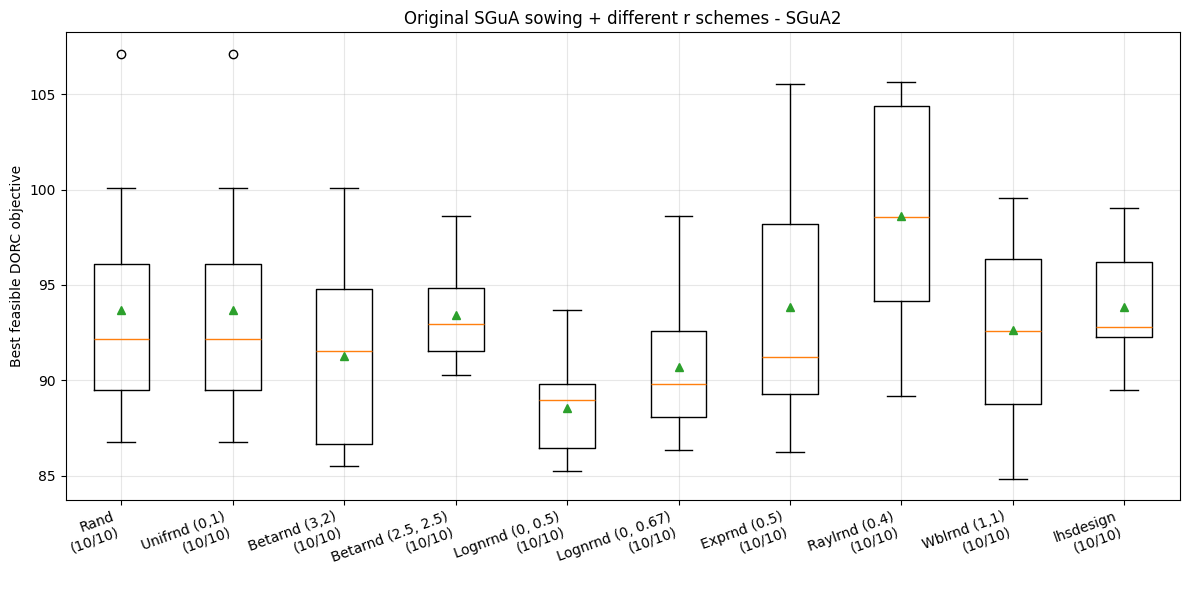

C:\Users\ESEL\AppData\Local\Temp\ipykernel_20472\2441663438.py:2036: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
C:\Users\ESEL\AppData\Local\Programs\Python\Python310\cpu\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\mean_convergence_original_sgua_sowing_SGuA2.png


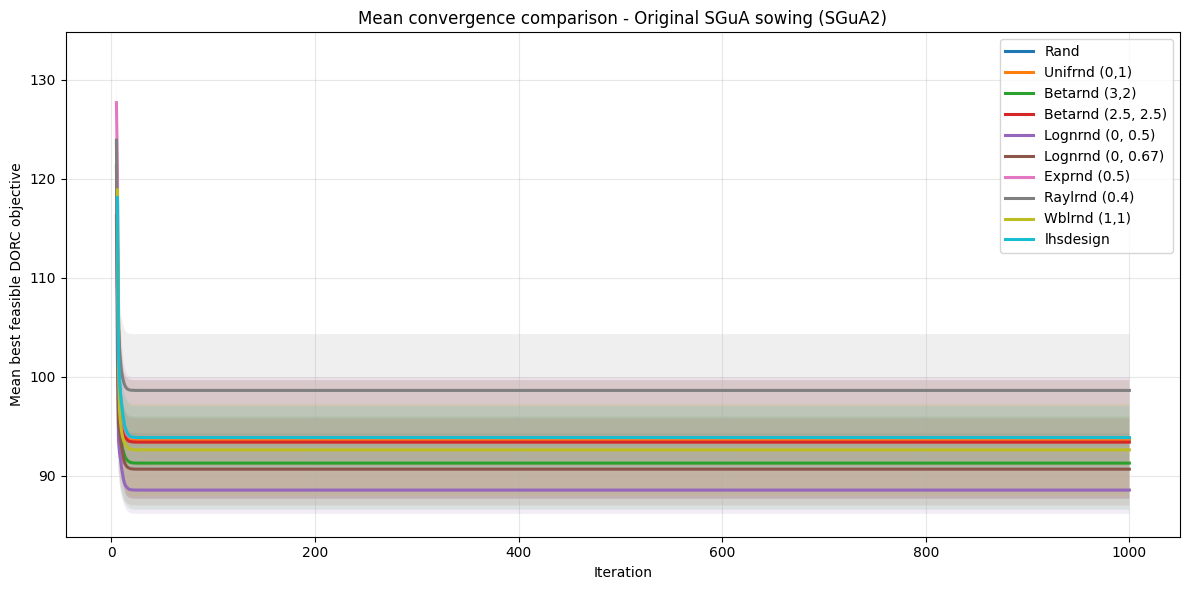


FULL COMPARATIVE MICROGRID DORC EVALUATION: SGuA BASELINES + CLASSICAL METHODS + CMA-ES + L-SHADE
Saved run results: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\sgua_dorc_run_results.csv
Saved convergence curves: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\sgua_dorc_feasible_curves.csv

----------------------------------------------------------------------------------------------------
Selected SGuA baseline for comparison: lognorm_0_0_5
----------------------------------------------------------------------------------------------------
Run 01 | SGuA2 | lognorm_0_0_5 | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 88.810045
Run 02 | SGuA2 | lognorm_0_0_5 | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 90.015391
Run 03 | SGuA2 | lognorm_0_0_5 | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): 87.194420
Run 04 | SGuA2 | lognorm_0_0_5 | Feasi

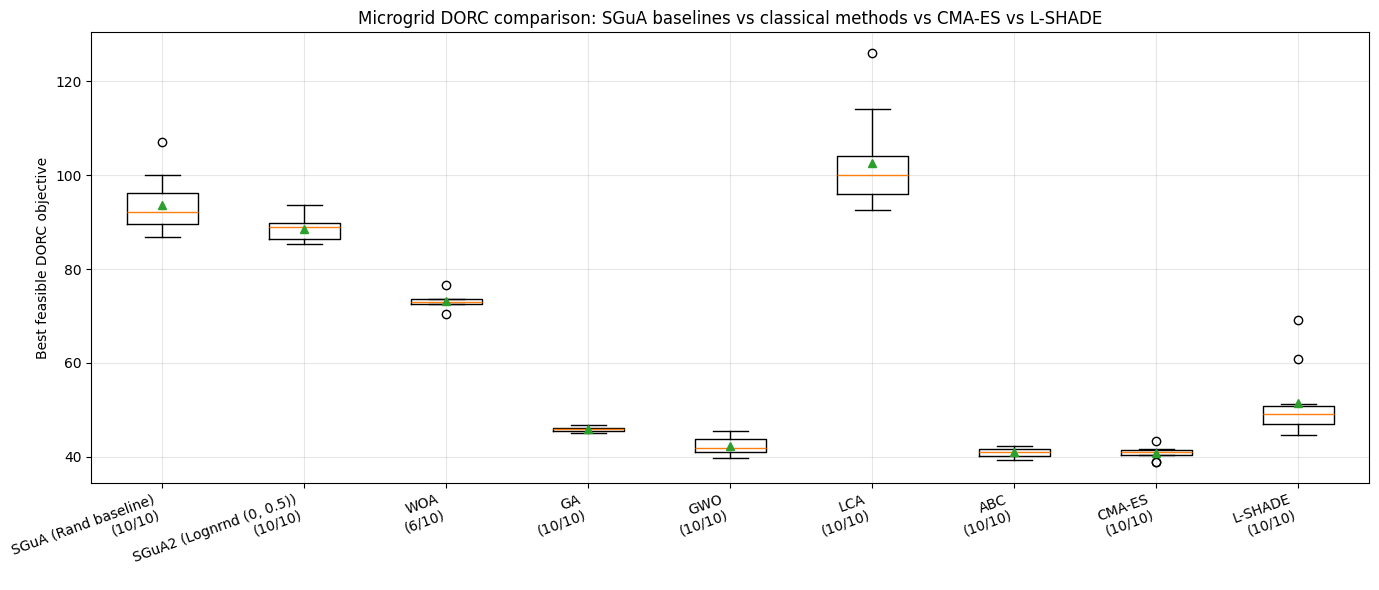

C:\Users\ESEL\AppData\Local\Temp\ipykernel_20472\2441663438.py:2036: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
C:\Users\ESEL\AppData\Local\Programs\Python\Python310\cpu\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\dorc_full_comparison_mean_convergence.png


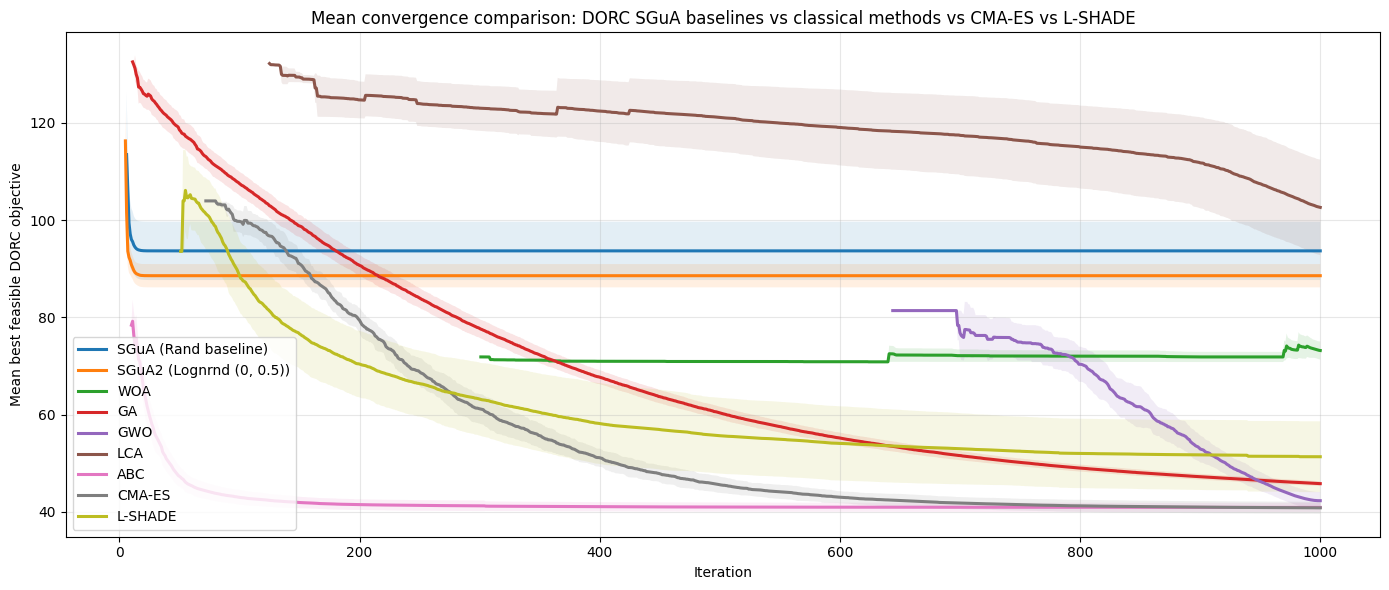

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\dorc_focused_mean_convergence_best_sgua_vs_cmaes_lshade.png


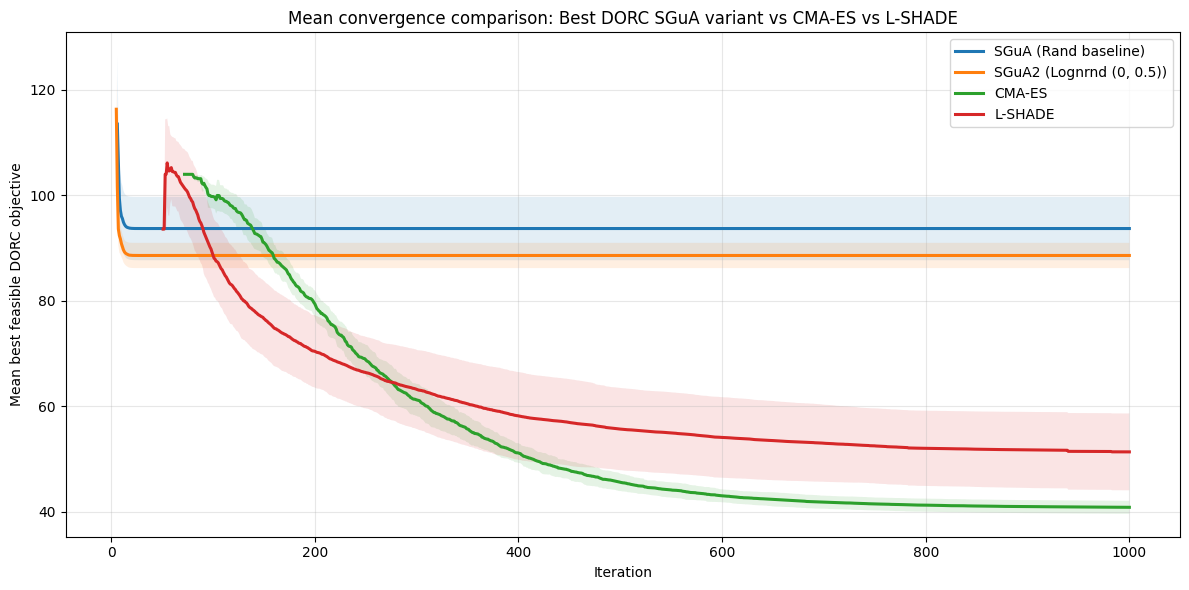

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\dorc_focused_boxplot_best_sgua_vs_cmaes_lshade.png


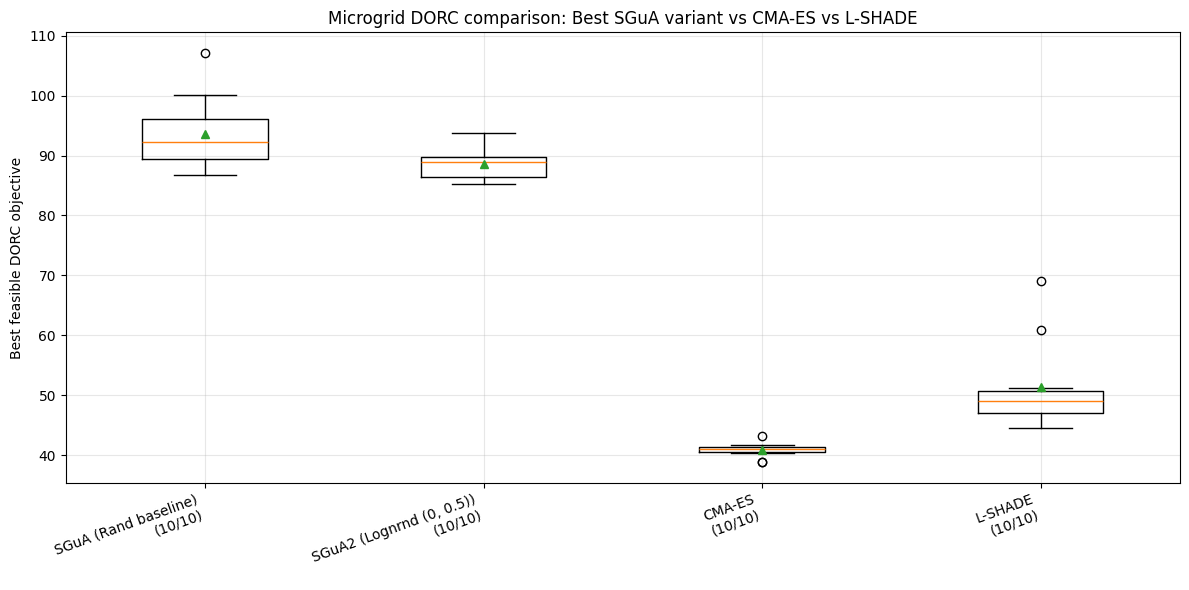

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\dorc_full_comparison_effect_sizes.png


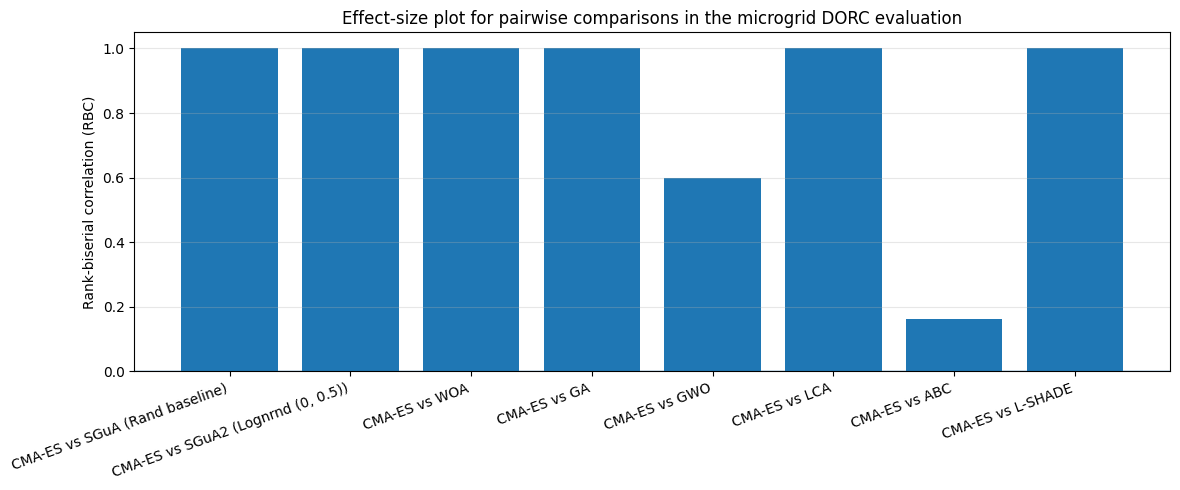

C:\Users\ESEL\AppData\Local\Temp\ipykernel_20472\2441663438.py:2065: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
C:\Users\ESEL\AppData\Local\Programs\Python\Python310\cpu\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\sgua_rand_single_method_mean_convergence.png


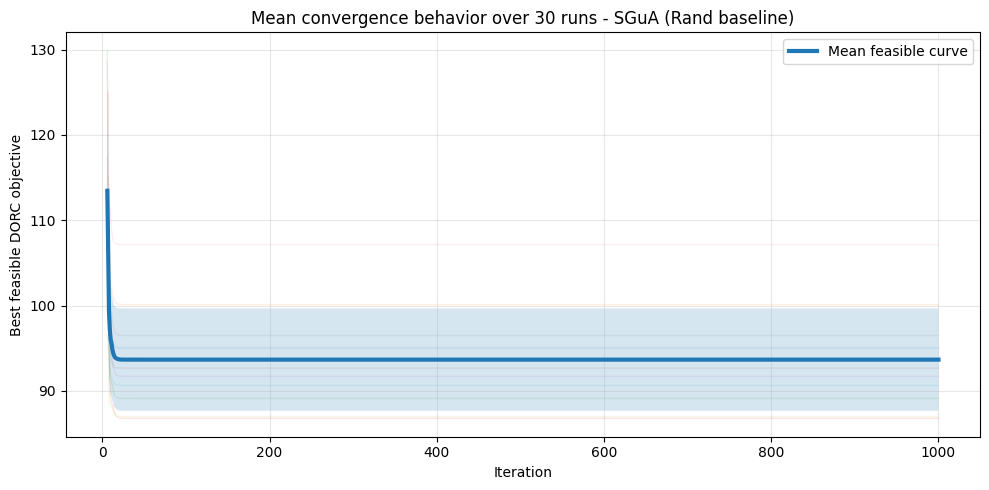

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\sgua2_lognorm_0_0_5_single_method_mean_convergence.png


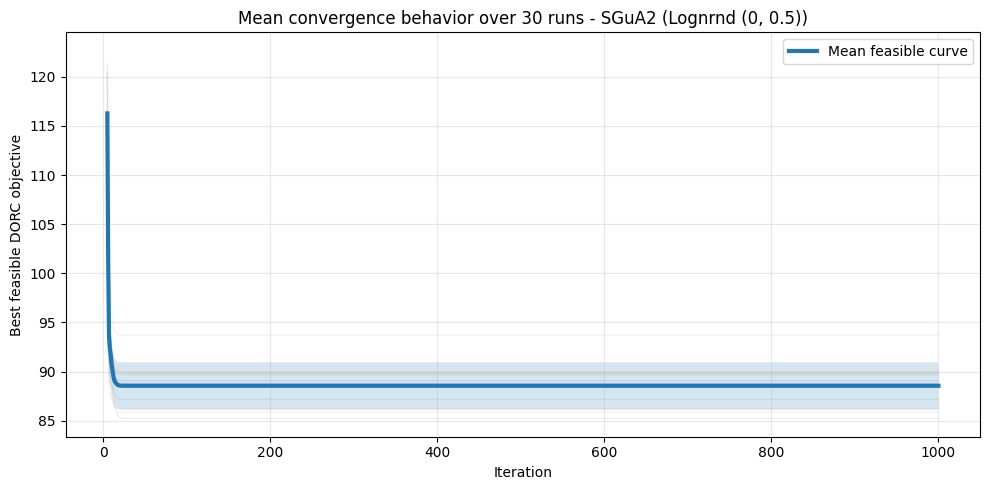

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\cmaes_single_method_mean_convergence.png


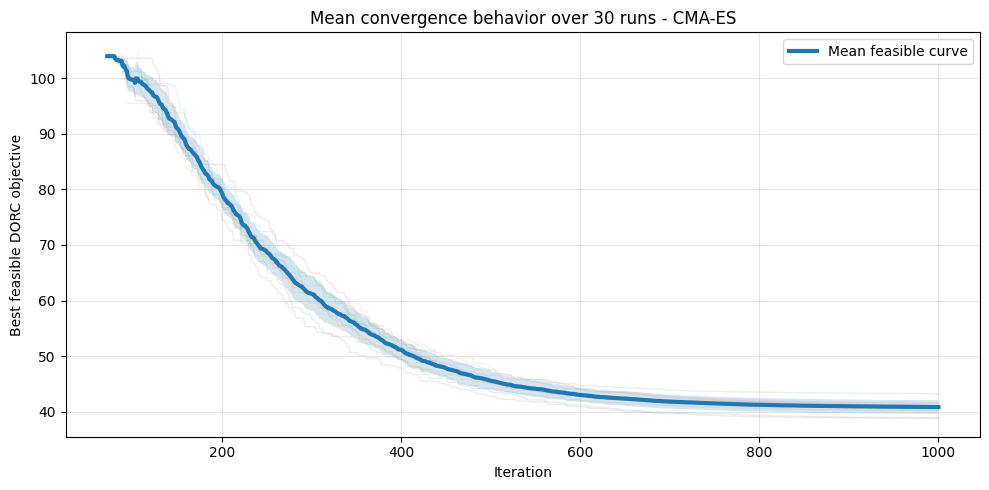

Saved figure: C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956\lshade_single_method_mean_convergence.png


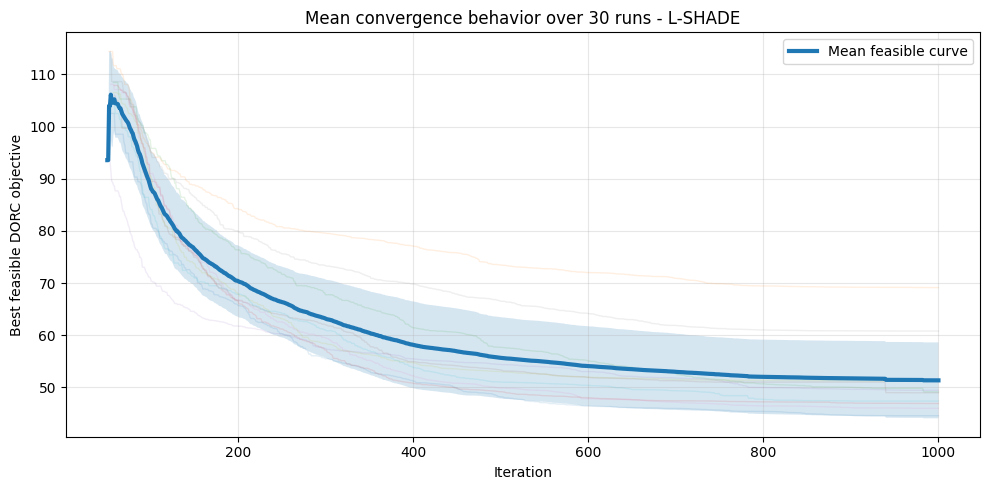


Completed. Output directory:
C:\Users\ESEL\Desktop\SGuA\SGuA_rev\outputs_dorc_9bus_paper_anchored_20260406_183956


In [3]:
import csv
import re
from pathlib import Path
from datetime import datetime
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, rankdata


SCHEME_DISPLAY_NAMES = {
    "rand": "Rand",
    "uniform": "Unifrnd (0,1)",
    "beta_3_2": "Betarnd (3,2)",
    "beta_2_5_2_5": "Betarnd (2.5, 2.5)",
    "lognorm_0_0_5": "Lognrnd (0, 0.5)",
    "lognorm_0_0_67": "Lognrnd (0, 0.67)",
    "exprnd_0_5": "Exprnd (0.5)",
    "rayleigh_0_4": "Raylrnd (0.4)",
    "weibull_1_1": "Wblrnd (1,1)",
    "lhsdesign": "lhsdesign",
}

ALGORITHM_DISPLAY_NAMES = {
    "SGuA2": "SGuA2",
    "SGuA_RAND": "SGuA (Rand baseline)",
    "CMAES": "CMA-ES",
    "LSHADE": "L-SHADE",
    "WOA": "WOA",
    "GA": "GA",
    "GWO": "GWO",
    "LCA": "LCA",
    "ABC": "ABC",
    "BOA": "BOA",
}


# =========================================================
# MICROGRID DORC PROBLEM (DUAL-SETTING 9-BUS)
# =========================================================

class DORCMicrogridProblem:
    """
    Paper-anchored 9-bus DORC benchmark inspired by:
    Shad et al., Energies 2025, 18, 1601.

    UPDATED: Dual-setting implementation with separate settings
    for grid-connected and islanded operating modes.

    Decision space dimension: 93
      - 23 x td_grid
      - 23 x Ip_grid
      - 23 x td_islanded
      - 23 x Ip_islanded
      - 1 x XFCL

    Important note:
    The original paper reports the Stage-2 DSOR/FCL optimization framework,
    the relay-pair structure, and key engineering constants, but it does not
    provide the full machine-readable short-circuit-current matrices for every
    scenario. Therefore, the current model remains a paper-anchored benchmark
    rather than a byte-for-byte reproduction of the original study.
    """

    def __init__(self, penalty_weight=1e6):
        self.penalty_weight = penalty_weight
        self.tol = 1e-12
        self.A = 0.14
        self.B = 0.02
        self.cti = 0.30

        # Paper-anchored engineering limits
        self.td_min = 0.05
        self.td_max = 1.20
        self.ip_min = 0.50
        self.ip_max = 2.50
        self.xfcl_min = 0.0
        self.xfcl_max = 6.0
        self.ti_min = 0.05
        self.ti_max = 4.00

        self.modes = ["grid_connected", "islanded"]
        self.mode_weights = {"grid_connected": 0.5, "islanded": 0.5}
        self.faults = ["F10", "F11", "F12", "F13", "F14", "F15", "F16", "F17"]
        self.scenarios = [(m, f) for m in self.modes for f in self.faults]

        self.relay_labels = [f"R{i}" for i in range(1, 24)]
        self.relay_index = {r: i for i, r in enumerate(self.relay_labels)}
        self.n_relays = len(self.relay_labels)

        # Table 5: primary-backup relationships in the 9-bus radial MG.
        self.pb_map = {
            "F10": [("R1", ["R10", "R17"]), ("R2", ["R4"])],
            "F11": [("R3", ["R1"]), ("R4", ["R6", "R18", "R20", "R22"])],
            "F12": [("R5", ["R3", "R18", "R20", "R22"]), ("R6", ["R8"])],
            "F13": [("R7", ["R5"]), ("R8", [])],
            "F14": [("R9", ["R2", "R17"]), ("R10", ["R12"])],
            "F15": [("R11", ["R9"]), ("R12", ["R14", "R19", "R21", "R23"])],
            "F16": [("R13", ["R11", "R19", "R21", "R23"]), ("R14", ["R16"])],
            "F17": [("R15", ["R13"]), ("R16", [])],
        }

        # Dual-setting decision vector:
        # [td_grid (23), Ip_grid (23), td_isl (23), Ip_isl (23), XFCL] => 93 variables
        self.lb = np.concatenate([
            np.full(self.n_relays, self.td_min, dtype=float),
            np.full(self.n_relays, self.ip_min, dtype=float),
            np.full(self.n_relays, self.td_min, dtype=float),
            np.full(self.n_relays, self.ip_min, dtype=float),
            np.array([self.xfcl_min], dtype=float),
        ])
        self.ub = np.concatenate([
            np.full(self.n_relays, self.td_max, dtype=float),
            np.full(self.n_relays, self.ip_max, dtype=float),
            np.full(self.n_relays, self.td_max, dtype=float),
            np.full(self.n_relays, self.ip_max, dtype=float),
            np.array([self.xfcl_max], dtype=float),
        ])

        # Paper-anchored base short-circuit levels (p.u.-style reconstruction).
        self.primary_base = {
            "grid_connected": {
                "F10": 12.0, "F11": 11.2, "F12": 10.8, "F13": 10.4,
                "F14": 11.7, "F15": 10.9, "F16": 10.5, "F17": 10.1,
            },
            "islanded": {
                "F10": 7.3, "F11": 6.8, "F12": 6.5, "F13": 6.2,
                "F14": 7.0, "F15": 6.6, "F16": 6.3, "F17": 6.0,
            },
        }
        self.backup_ratio = {"grid_connected": 0.62, "islanded": 0.68}
        self.weak_ratio = {"grid_connected": 0.18, "islanded": 0.22}
        self.fcl_sensitivity = {"grid_connected": 0.08, "islanded": 0.03}

    def split_variables(self, X):
        X = np.atleast_2d(X)
        n = self.n_relays
        td_grid = X[:, :n]
        Ip_grid = X[:, n:2 * n]
        td_isl = X[:, 2 * n:3 * n]
        Ip_isl = X[:, 3 * n:4 * n]
        xfcl = X[:, -1]
        return td_grid, Ip_grid, td_isl, Ip_isl, xfcl

    def _scenario_currents_for_solution(self, X_row, mode, fault):
        _, _, _, _, xfcl_arr = self.split_variables(X_row[None, :])
        xfcl = float(xfcl_arr[0])
        currents = np.full(
            self.n_relays,
            self.weak_ratio[mode] * self.primary_base[mode][fault],
            dtype=float,
        )

        # FCL impact is prominent in grid-connected mode and negligible in islanded mode.
        if mode == "grid_connected":
            reduction = 1.0 / (1.0 + self.fcl_sensitivity[mode] * xfcl)
        else:
            reduction = 1.0

        for prim, backups in self.pb_map[fault]:
            currents[self.relay_index[prim]] = self.primary_base[mode][fault] * reduction
            for b in backups:
                currents[self.relay_index[b]] = (
                    self.primary_base[mode][fault] * self.backup_ratio[mode] * reduction
                )
        return currents

    def _relay_times_for_solution(self, X_row, mode, fault):
        td_grid, Ip_grid, td_isl, Ip_isl, _ = self.split_variables(X_row[None, :])
        if mode == "grid_connected":
            td = td_grid[0]
            Ip = Ip_grid[0]
        else:
            td = td_isl[0]
            Ip = Ip_isl[0]

        I_fault = self._scenario_currents_for_solution(X_row, mode, fault)
        ratio = np.maximum(I_fault / np.maximum(Ip, 1e-12), 1.000001)
        denom = np.power(ratio, self.B) - 1.0
        denom = np.where(np.abs(denom) < 1e-12, 1e-12, denom)
        ti = self.A * td / denom
        return ti

    def compute_ti(self, X):
        X = np.atleast_2d(X)
        rep = []
        for row in X:
            acc = np.zeros(self.n_relays, dtype=float)
            wsum = 0.0
            for mode, fault in self.scenarios:
                w = self.mode_weights[mode] / len(self.faults)
                acc += w * self._relay_times_for_solution(row, mode, fault)
                wsum += w
            rep.append(acc / max(wsum, 1e-12))
        return np.array(rep, dtype=float)

    def evaluate(self, X):
        X = np.atleast_2d(X)
        td_grid, Ip_grid, td_isl, Ip_isl, xfcl = self.split_variables(X)
        representative_ti = self.compute_ti(X)
        objective = np.zeros(X.shape[0], dtype=float)
        penalty = np.zeros(X.shape[0], dtype=float)

        # Variable bounds
        penalty += np.sum(
            np.maximum(0.0, self.td_min - td_grid) ** 2
            + np.maximum(0.0, td_grid - self.td_max) ** 2,
            axis=1,
        )
        penalty += np.sum(
            np.maximum(0.0, self.ip_min - Ip_grid) ** 2
            + np.maximum(0.0, Ip_grid - self.ip_max) ** 2,
            axis=1,
        )
        penalty += np.sum(
            np.maximum(0.0, self.td_min - td_isl) ** 2
            + np.maximum(0.0, td_isl - self.td_max) ** 2,
            axis=1,
        )
        penalty += np.sum(
            np.maximum(0.0, self.ip_min - Ip_isl) ** 2
            + np.maximum(0.0, Ip_isl - self.ip_max) ** 2,
            axis=1,
        )
        penalty += (
            np.maximum(0.0, self.xfcl_min - xfcl) ** 2
            + np.maximum(0.0, xfcl - self.xfcl_max) ** 2
        )

        for r, row in enumerate(X):
            total = 0.0
            for mode, fault in self.scenarios:
                mode_w = self.mode_weights[mode]
                ti = self._relay_times_for_solution(row, mode, fault)
                currents = self._scenario_currents_for_solution(row, mode, fault)
                Ip_active = Ip_grid[r] if mode == "grid_connected" else Ip_isl[r]

                for prim, backups in self.pb_map[fault]:
                    i = self.relay_index[prim]
                    total += mode_w * ti[i]

                    if ti[i] < self.ti_min:
                        penalty[r] += (self.ti_min - ti[i]) ** 2
                    if ti[i] > self.ti_max:
                        penalty[r] += (ti[i] - self.ti_max) ** 2

                    # Primary relay must see current above pickup.
                    pickup_violation = max(0.0, Ip_active[i] - currents[i])
                    penalty[r] += pickup_violation ** 2

                    for b in backups:
                        j = self.relay_index[b]
                        total += mode_w * ti[j]

                        if ti[j] < self.ti_min:
                            penalty[r] += (self.ti_min - ti[j]) ** 2
                        if ti[j] > self.ti_max:
                            penalty[r] += (ti[j] - self.ti_max) ** 2

                        cti_violation = max(0.0, self.cti - (ti[j] - ti[i]))
                        penalty[r] += cti_violation ** 2

            objective[r] = total

        penalized = objective + self.penalty_weight * penalty
        feasible = penalty <= self.tol
        return penalized, objective, feasible, representative_ti

    def check_constraints_from_solution(self, X):
        X = np.atleast_2d(X)
        row = X[0]
        worst_margin = np.inf
        for mode, fault in self.scenarios:
            ti = self._relay_times_for_solution(row, mode, fault)
            for prim, backups in self.pb_map[fault]:
                i = self.relay_index[prim]
                for b in backups:
                    j = self.relay_index[b]
                    worst_margin = min(worst_margin, ti[j] - ti[i])
        rep_ti = self.compute_ti(X)[0]
        return {
            "all_t_range": bool(np.all((rep_ti >= self.ti_min) & (rep_ti <= self.ti_max))),
            "worst_backup_minus_primary": float(worst_margin),
            "cti_ok": bool(worst_margin >= self.cti),
            "representative_ti": rep_ti,
        }


ORCProblem = DORCMicrogridProblem


# =========================================================
# SGuA
# =========================================================

class SGuA:
    def __init__(
        self,
        problem,
        variant="SGuA1",
        P=40,
        G=500,
        branch_mode="linear",
        similarity_tol=1e-3,
        use_orc_guide_seed=False,
        init_scheme="rand",
        r_mode="vector",
        seed=123,
    ):
        self.problem = problem
        self.variant = variant
        self.P = P
        self.G = G
        self.D = len(problem.lb)
        self.branch_mode = branch_mode
        self.similarity_tol = similarity_tol
        self.use_orc_guide_seed = use_orc_guide_seed
        self.init_scheme = init_scheme
        self.r_mode = r_mode

        self.lb = problem.lb.copy()
        self.ub = problem.ub.copy()
        self.span = self.ub - self.lb
        self.max_distance = np.linalg.norm(self.span)
        self.rng = np.random.default_rng(seed)

        self.fe_count = 0
        self.gbest_X = np.zeros(self.D, dtype=float)
        self.gbest_penalized = np.inf
        self.gbest_objective = np.inf
        self.gbest_ti = None
        self.best_feasible_X = None
        self.best_feasible_obj = np.inf
        self.best_feasible_ti = None
        self.best_feasible_curve = np.full(G, np.nan, dtype=float)

    def evaluate_population(self, X):
        penalized, objective, feasible, ti = self.problem.evaluate(X)
        self.fe_count += X.shape[0]
        return penalized, objective, feasible, ti

    def update_bests(self, X, penalized, objective, feasible, ti):
        idx_pen = np.argmin(penalized)
        if penalized[idx_pen] < self.gbest_penalized:
            self.gbest_penalized = penalized[idx_pen]
            self.gbest_objective = objective[idx_pen]
            self.gbest_X = X[idx_pen].copy()
            self.gbest_ti = ti[idx_pen].copy()

        feasible_indices = np.where(feasible)[0]
        if feasible_indices.size > 0:
            local_feasible_obj = objective[feasible_indices]
            best_local_idx = feasible_indices[np.argmin(local_feasible_obj)]
            if objective[best_local_idx] < self.best_feasible_obj:
                self.best_feasible_obj = objective[best_local_idx]
                self.best_feasible_X = X[best_local_idx].copy()
                self.best_feasible_ti = ti[best_local_idx].copy()

    def select_best(self, X):
        penalized, objective, feasible, ti = self.evaluate_population(X)
        self.update_bests(X, penalized, objective, feasible, ti)
        idx = np.argsort(penalized)[: self.P]
        return X[idx].copy()

    def _positive_to_unit(self, x):
        return x / (1.0 + x)

    def _lhs_1d(self, n):
        perm = self.rng.permutation(n)
        return (perm + self.rng.random(n)) / n

    def _draw_r_batch(self, n):
        scheme = self.init_scheme.lower()
        size = n if self.r_mode == "scalar" else (n, self.D)

        if scheme == "rand":
            r = self.rng.random(size)
        elif scheme == "uniform":
            r = self.rng.uniform(0.0, 1.0, size=size)
        elif scheme == "beta_3_2":
            r = self.rng.beta(3.0, 2.0, size=size)
        elif scheme == "beta_2_5_2_5":
            r = self.rng.beta(2.5, 2.5, size=size)
        elif scheme == "lognorm_0_0_5":
            r = self._positive_to_unit(self.rng.lognormal(mean=0.0, sigma=0.5, size=size))
        elif scheme == "lognorm_0_0_67":
            r = self._positive_to_unit(self.rng.lognormal(mean=0.0, sigma=0.67, size=size))
        elif scheme == "exprnd_0_5":
            r = self._positive_to_unit(self.rng.exponential(scale=0.5, size=size))
        elif scheme == "rayleigh_0_4":
            r = self._positive_to_unit(self.rng.rayleigh(scale=0.4, size=size))
        elif scheme == "weibull_1_1":
            r = self._positive_to_unit(self.rng.weibull(a=1.0, size=size))
        elif scheme == "lhsdesign":
            if self.r_mode == "scalar":
                r = self._lhs_1d(n)
            else:
                r = np.column_stack([self._lhs_1d(n) for _ in range(self.D)])
        else:
            raise ValueError(f"Unknown init_scheme: {self.init_scheme}")

        eps = 1e-12
        return np.clip(r, eps, 1.0 - eps)

    def sowing_sapling(self):
        garden = [self.ub.copy(), self.lb.copy()]
        # Removed the old 6-relay targeted seed to avoid incompatibility with the 93-D problem.
        k = 2
        while len(garden) < self.P:
            seg_ids = np.minimum((np.arange(self.D) * k) // self.D, k - 1)
            masks = list(range(1, (2 ** k) - 1))
            masks = masks[: self.P - len(garden)]
            if len(masks) == 0:
                break
            r_batch = self._draw_r_batch(len(masks))
            for idx_mask, mask in enumerate(masks):
                bits = np.array([(mask >> s) & 1 for s in range(k)], dtype=int)
                if self.r_mode == "scalar":
                    r = float(r_batch[idx_mask])
                    coeff = np.where(bits[seg_ids] == 1, r, 1.0 - r)
                else:
                    r = r_batch[idx_mask]
                    coeff = np.where(bits[seg_ids] == 1, r, 1.0 - r)
                x = self.lb + self.span * coeff
                garden.append(np.clip(x, self.lb, self.ub))
            k += 1
        return np.array(garden[: self.P], dtype=float)

    def mating(self, G):
        perm = self.rng.permutation(len(G))
        offspring = []
        for p in range(0, len(G) - 1, 2):
            s1 = G[perm[p]].copy()
            s2 = G[perm[p + 1]].copy()
            distance = np.linalg.norm(s1 - s2)
            pm = max(0.0, 1.0 - distance / (self.max_distance + 1e-12))
            child1 = s1.copy()
            child2 = s2.copy()
            for j in range(self.D):
                if self.rng.random() < pm:
                    child1[j], child2[j] = child2[j], child1[j]
            offspring.append(np.clip(child1, self.lb, self.ub))
            offspring.append(np.clip(child2, self.lb, self.ub))
        if len(G) % 2 == 1:
            offspring.append(G[perm[-1]].copy())
        return np.array(offspring[: self.P], dtype=float)

    def branching_probability(self, distance_index):
        if self.branch_mode == "linear":
            return 1.0 - 1.0 / (distance_index + 1.0)
        return 1.0 - np.exp(-distance_index)

    def branching(self, G):
        offspring = []
        for s in G:
            child = s.copy()
            i = self.rng.integers(0, self.D)
            for j in range(self.D):
                if j == i:
                    continue
                dist_idx = abs(j - i)
                if self.rng.random() < self.branching_probability(dist_idx):
                    child[j] = child[j] + self.rng.random() * (child[i] - child[j])
            offspring.append(np.clip(child, self.lb, self.ub))
        return np.array(offspring[: self.P], dtype=float)

    def vaccinating(self, G):
        perm = self.rng.permutation(len(G))
        offspring = []
        for p in range(0, len(G) - 1, 2):
            s1 = G[perm[p]].copy()
            s2 = G[perm[p + 1]].copy()
            norm_diff = np.abs(s1 - s2) / (self.span + 1e-12)
            dis = np.mean(norm_diff)
            child1 = s1.copy()
            child2 = s2.copy()
            if dis > self.rng.random():
                eq_mask = norm_diff <= self.similarity_tol
                rand1 = self.rng.uniform(self.lb, self.ub)
                rand2 = self.rng.uniform(self.lb, self.ub)
                child1 = np.where(eq_mask, s1, rand1)
                child2 = np.where(eq_mask, s2, rand2)
            offspring.append(np.clip(child1, self.lb, self.ub))
            offspring.append(np.clip(child2, self.lb, self.ub))
        if len(G) % 2 == 1:
            offspring.append(G[perm[-1]].copy())
        return np.array(offspring[: self.P], dtype=float)

    def opt_sgua1(self):
        G = self.sowing_sapling()
        pen, obj, fea, ti = self.evaluate_population(G)
        self.update_bests(G, pen, obj, fea, ti)
        if self.best_feasible_X is not None:
            self.best_feasible_curve[0] = self.best_feasible_obj
        for g in range(1, self.G):
            G1 = self.mating(G)
            G2 = self.branching(G)
            G3 = self.vaccinating(G)
            G = self.select_best(np.vstack([G1, G2, G3, G]))
            if self.best_feasible_X is not None:
                self.best_feasible_curve[g] = self.best_feasible_obj
        return self.finalize_result()

    def opt_sgua2(self):
        G = self.sowing_sapling()
        pen, obj, fea, ti = self.evaluate_population(G)
        self.update_bests(G, pen, obj, fea, ti)
        if self.best_feasible_X is not None:
            self.best_feasible_curve[0] = self.best_feasible_obj
        for g in range(1, self.G):
            G1 = self.mating(G)
            pen1, obj1, fea1, ti1 = self.evaluate_population(G1)
            self.update_bests(G1, pen1, obj1, fea1, ti1)
            Gm = self.select_best(np.vstack([G1, G]))
            G2 = self.branching(Gm)
            pen2, obj2, fea2, ti2 = self.evaluate_population(G2)
            self.update_bests(G2, pen2, obj2, fea2, ti2)
            Gb = self.select_best(np.vstack([G2, Gm]))
            G3 = self.vaccinating(Gb)
            pen3, obj3, fea3, ti3 = self.evaluate_population(G3)
            self.update_bests(G3, pen3, obj3, fea3, ti3)
            G = self.select_best(np.vstack([G3, Gb]))
            if self.best_feasible_X is not None:
                self.best_feasible_curve[g] = self.best_feasible_obj
        return self.finalize_result()

    def finalize_result(self):
        n = self.problem.n_relays
        if self.best_feasible_X is not None:
            final_X = self.best_feasible_X.copy()
            final_ti = self.best_feasible_ti.copy()
            final_obj = self.best_feasible_obj
            feasible_flag = True
        else:
            final_X = self.gbest_X.copy()
            final_ti = self.gbest_ti.copy() if self.gbest_ti is not None else np.full(n, np.nan)
            final_obj = self.gbest_objective
            feasible_flag = False

        return {
            "x": final_X,
            "td_grid": final_X[:n],
            "Ip_grid": final_X[n:2 * n],
            "td_isl": final_X[2 * n:3 * n],
            "Ip_isl": final_X[3 * n:4 * n],
            "xfcl": float(final_X[-1]),
            "Ti": final_ti,
            "best_fitness": final_obj,
            "feasible": feasible_flag,
            "function_evaluations": self.fe_count,
            "feasible_curve": self.best_feasible_curve.copy(),
            "penalized_fitness": self.gbest_penalized,
            "init_scheme": self.init_scheme,
            "algorithm": self.variant,
            "method_key": f"{self.variant}-{self.init_scheme}",
        }

    def opt(self):
        if self.variant == "SGuA1":
            return self.opt_sgua1()
        if self.variant == "SGuA2":
            return self.opt_sgua2()
        raise ValueError("variant must be either 'SGuA1' or 'SGuA2'")


# =========================================================
# COMMON BASE FOR CMA-ES / L-SHADE
# =========================================================

class OptimizerBase:
    def __init__(self, problem, algorithm_name, P=100, G=1000, seed=123):
        self.problem = problem
        self.algorithm_name = algorithm_name
        self.P = P
        self.G = G
        self.D = len(problem.lb)
        self.lb = problem.lb.copy()
        self.ub = problem.ub.copy()
        self.span = self.ub - self.lb
        self.rng = np.random.default_rng(seed)

        self.fe_count = 0
        self.gbest_X = np.zeros(self.D, dtype=float)
        self.gbest_penalized = np.inf
        self.gbest_objective = np.inf
        self.gbest_ti = None
        self.best_feasible_X = None
        self.best_feasible_obj = np.inf
        self.best_feasible_ti = None
        self.best_feasible_curve = np.full(G, np.nan, dtype=float)

    def evaluate_population(self, X):
        penalized, objective, feasible, ti = self.problem.evaluate(X)
        self.fe_count += X.shape[0]
        return penalized, objective, feasible, ti

    def update_bests(self, X, penalized, objective, feasible, ti):
        idx_pen = np.argmin(penalized)
        if penalized[idx_pen] < self.gbest_penalized:
            self.gbest_penalized = penalized[idx_pen]
            self.gbest_objective = objective[idx_pen]
            self.gbest_X = X[idx_pen].copy()
            self.gbest_ti = ti[idx_pen].copy()
        feasible_idx = np.where(feasible)[0]
        if feasible_idx.size > 0:
            best_idx = feasible_idx[np.argmin(objective[feasible_idx])]
            if objective[best_idx] < self.best_feasible_obj:
                self.best_feasible_obj = objective[best_idx]
                self.best_feasible_X = X[best_idx].copy()
                self.best_feasible_ti = ti[best_idx].copy()

    def clip(self, X):
        return np.clip(X, self.lb, self.ub)

    def maybe_store_curve(self, g):
        if self.best_feasible_X is not None:
            self.best_feasible_curve[g] = self.best_feasible_obj

    def finalize_result(self):
        n = self.problem.n_relays
        if self.best_feasible_X is not None:
            final_X = self.best_feasible_X.copy()
            final_ti = self.best_feasible_ti.copy()
            final_obj = self.best_feasible_obj
            feasible_flag = True
        else:
            final_X = self.gbest_X.copy()
            final_ti = self.gbest_ti.copy() if self.gbest_ti is not None else np.full(n, np.nan)
            final_obj = self.gbest_objective
            feasible_flag = False

        return {
            "x": final_X,
            "td_grid": final_X[:n],
            "Ip_grid": final_X[n:2 * n],
            "td_isl": final_X[2 * n:3 * n],
            "Ip_isl": final_X[3 * n:4 * n],
            "xfcl": float(final_X[-1]),
            "Ti": final_ti,
            "best_fitness": final_obj,
            "feasible": feasible_flag,
            "function_evaluations": self.fe_count,
            "feasible_curve": self.best_feasible_curve.copy(),
            "penalized_fitness": self.gbest_penalized,
            "algorithm": self.algorithm_name,
            "method_key": self.algorithm_name,
        }


# =========================================================
# CMA-ES (self-contained bounded adaptation)
# =========================================================

class CMAES(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, sigma0=0.30):
        super().__init__(problem, algorithm_name="CMAES", P=P, G=G, seed=seed)
        self.sigma0 = sigma0

    def opt(self):
        n = self.D
        lam = self.P
        mu = lam // 2
        weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
        weights = weights / np.sum(weights)
        mueff = (np.sum(weights) ** 2) / np.sum(weights ** 2)

        cc = (4 + mueff / n) / (n + 4 + 2 * mueff / n)
        cs = (mueff + 2) / (n + mueff + 5)
        c1 = 2 / ((n + 1.3) ** 2 + mueff)
        cmu = min(1 - c1, 2 * (mueff - 2 + 1 / mueff) / ((n + 2) ** 2 + mueff))
        damps = 1 + 2 * max(0, np.sqrt((mueff - 1) / (n + 1)) - 1) + cs
        chi_n = np.sqrt(n) * (1 - 1 / (4 * n) + 1 / (21 * n * n))

        mean = 0.5 * (self.lb + self.ub)
        sigma = self.sigma0 * np.mean(self.span)
        C = np.eye(n)
        B = np.eye(n)
        Dvals = np.ones(n)
        invsqrtC = np.eye(n)
        pc = np.zeros(n)
        ps = np.zeros(n)

        for g in range(self.G):
            A = B @ np.diag(Dvals)
            arz = self.rng.normal(size=(lam, n))
            ary = arz @ A.T
            arx = self.clip(mean + sigma * ary)

            pen, obj, fea, ti = self.evaluate_population(arx)
            self.update_bests(arx, pen, obj, fea, ti)

            idx = np.argsort(pen)
            x_sel = arx[idx[:mu]]
            z_sel = arz[idx[:mu]]
            y_sel = ary[idx[:mu]]

            old_mean = mean.copy()
            mean = np.sum(weights[:, None] * x_sel, axis=0)
            zmean = np.sum(weights[:, None] * z_sel, axis=0)
            ymean = np.sum(weights[:, None] * y_sel, axis=0)

            ps = (1 - cs) * ps + np.sqrt(cs * (2 - cs) * mueff) * (invsqrtC @ ((mean - old_mean) / max(sigma, 1e-16)))
            norm_ps = np.linalg.norm(ps)
            hsig_cond = norm_ps / np.sqrt(1 - (1 - cs) ** (2 * (g + 1))) / chi_n
            hsig = 1.0 if hsig_cond < (1.4 + 2 / (n + 1)) else 0.0
            pc = (1 - cc) * pc + hsig * np.sqrt(cc * (2 - cc) * mueff) * ((mean - old_mean) / max(sigma, 1e-16))

            artmp = (x_sel - old_mean) / max(sigma, 1e-16)
            C = (1 - c1 - cmu) * C + c1 * (np.outer(pc, pc) + (1 - hsig) * cc * (2 - cc) * C)
            for wi, yi in zip(weights, artmp):
                C += cmu * wi * np.outer(yi, yi)
            C = 0.5 * (C + C.T)

            sigma *= np.exp((cs / damps) * (norm_ps / chi_n - 1))
            sigma = max(sigma, 1e-12)

            eigvals, eigvecs = np.linalg.eigh(C)
            eigvals = np.maximum(eigvals, 1e-20)
            Dvals = np.sqrt(eigvals)
            B = eigvecs
            invsqrtC = B @ np.diag(1.0 / Dvals) @ B.T

            self.maybe_store_curve(g)

        return self.finalize_result()


# =========================================================
# L-SHADE (compact self-contained variant)
# =========================================================

class LSHADE(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, memory_size=6, pbest_rate=0.11, min_pop_size=4):
        super().__init__(problem, algorithm_name="LSHADE", P=P, G=G, seed=seed)
        self.memory_size = memory_size
        self.pbest_rate = pbest_rate
        self.min_pop_size = min_pop_size

    def _sample_F(self, mu_F):
        while True:
            F = mu_F + 0.1 * np.tan(np.pi * (self.rng.random() - 0.5))
            if F > 0:
                return min(F, 1.0)

    def _sample_CR(self, mu_CR):
        cr = self.rng.normal(mu_CR, 0.1)
        return float(np.clip(cr, 0.0, 1.0))

    def opt(self):
        NP_init = self.P
        NP = self.P
        D = self.D
        H = self.memory_size
        M_F = np.full(H, 0.5, dtype=float)
        M_CR = np.full(H, 0.5, dtype=float)
        memory_idx = 0

        pop = self.rng.uniform(self.lb, self.ub, size=(NP, D))
        pen, obj, fea, ti = self.evaluate_population(pop)
        self.update_bests(pop, pen, obj, fea, ti)
        archive = np.empty((0, D), dtype=float)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            pop = pop[order]
            pen = pen[order]
            obj = obj[order]
            fea = fea[order]
            ti = ti[order]

            p_num = max(2, int(np.ceil(self.pbest_rate * NP)))
            p_num = min(p_num, NP)

            F_list = np.zeros(NP, dtype=float)
            CR_list = np.zeros(NP, dtype=float)
            trial = np.zeros_like(pop)

            all_pool = np.vstack([pop, archive]) if len(archive) > 0 else pop.copy()

            for i in range(NP):
                r = self.rng.integers(0, H)
                Fi = self._sample_F(M_F[r])
                CRi = self._sample_CR(M_CR[r])
                F_list[i] = Fi
                CR_list[i] = CRi

                pbest_idx = self.rng.integers(0, p_num)
                xpbest = pop[pbest_idx]

                idx_choices = np.delete(np.arange(NP), i)
                r1 = self.rng.choice(idx_choices)
                xr1 = pop[r1]

                pool_indices = np.arange(all_pool.shape[0])
                invalid = {i, r1}
                valid_pool = [idx for idx in pool_indices if idx not in invalid]
                if len(valid_pool) == 0:
                    xr2 = pop[self.rng.integers(0, NP)]
                else:
                    xr2 = all_pool[self.rng.choice(valid_pool)]

                mutant = pop[i] + Fi * (xpbest - pop[i]) + Fi * (xr1 - xr2)
                mutant = self.clip(mutant)

                jrand = self.rng.integers(0, D)
                cross_mask = self.rng.random(D) < CRi
                cross_mask[jrand] = True
                trial[i] = np.where(cross_mask, mutant, pop[i])

            t_pen, t_obj, t_fea, t_ti = self.evaluate_population(trial)
            self.update_bests(trial, t_pen, t_obj, t_fea, t_ti)

            S_F = []
            S_CR = []
            delta_f = []
            next_pop = []
            next_pen = []
            next_obj = []
            next_fea = []
            next_ti = []

            for i in range(NP):
                if t_pen[i] <= pen[i]:
                    archive = np.vstack([archive, pop[i].copy()])
                    next_pop.append(trial[i].copy())
                    next_pen.append(t_pen[i])
                    next_obj.append(t_obj[i])
                    next_fea.append(t_fea[i])
                    next_ti.append(t_ti[i].copy())
                    improvement = abs(pen[i] - t_pen[i])
                    if improvement > 0:
                        S_F.append(F_list[i])
                        S_CR.append(CR_list[i])
                        delta_f.append(improvement)
                else:
                    next_pop.append(pop[i].copy())
                    next_pen.append(pen[i])
                    next_obj.append(obj[i])
                    next_fea.append(fea[i])
                    next_ti.append(ti[i].copy())

            pop = np.array(next_pop, dtype=float)
            pen = np.array(next_pen, dtype=float)
            obj = np.array(next_obj, dtype=float)
            fea = np.array(next_fea, dtype=bool)
            ti = np.array(next_ti, dtype=float)
            NP = len(pop)

            if archive.shape[0] > NP_init:
                keep = self.rng.choice(np.arange(archive.shape[0]), size=NP_init, replace=False)
                archive = archive[keep]

            if len(S_F) > 0:
                w = np.array(delta_f, dtype=float)
                w = w / np.sum(w)
                S_F = np.array(S_F, dtype=float)
                S_CR = np.array(S_CR, dtype=float)
                new_MF = np.sum(w * (S_F ** 2)) / max(np.sum(w * S_F), 1e-16)
                new_MCR = np.sum(w * S_CR)
                M_F[memory_idx] = np.clip(new_MF, 1e-6, 1.0)
                M_CR[memory_idx] = np.clip(new_MCR, 0.0, 1.0)
                memory_idx = (memory_idx + 1) % H

            NP_target = int(round(self.min_pop_size + (NP_init - self.min_pop_size) * (1 - g / max(self.G - 1, 1))))
            NP_target = max(self.min_pop_size, min(NP_target, len(pop)))
            if len(pop) > NP_target:
                order = np.argsort(pen)
                pop = pop[order[:NP_target]]
                pen = pen[order[:NP_target]]
                obj = obj[order[:NP_target]]
                fea = fea[order[:NP_target]]
                ti = ti[order[:NP_target]]
                NP = NP_target
                if archive.shape[0] > NP_init:
                    archive = archive[:NP_init]

            self.maybe_store_curve(g)

        return self.finalize_result()




# =========================================================
# WOA
# =========================================================

class WOA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, b=1.0):
        super().__init__(problem, "WOA", P=P, G=G, seed=seed)
        self.b = b

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            a = 2.0 - 2.0 * g / max(self.G - 1, 1)
            best = self.best_feasible_X if self.best_feasible_X is not None else self.gbest_X
            X_new = np.zeros_like(X)
            for i in range(self.P):
                r1 = self.rng.random(self.D)
                r2 = self.rng.random(self.D)
                A = 2 * a * r1 - a
                C = 2 * r2
                p = self.rng.random()
                l = self.rng.uniform(-1.0, 1.0)
                if p < 0.5:
                    if np.mean(np.abs(A)) < 1.0:
                        D = np.abs(C * best - X[i])
                        X_new[i] = best - A * D
                    else:
                        rand_idx = self.rng.integers(0, self.P)
                        X_rand = X[rand_idx]
                        D = np.abs(C * X_rand - X[i])
                        X_new[i] = X_rand - A * D
                else:
                    D = np.abs(best - X[i])
                    X_new[i] = D * np.exp(self.b * l) * np.cos(2 * np.pi * l) + best
            X = self.clip(X_new)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# GWO
# =========================================================

class GWO(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123):
        super().__init__(problem, "GWO", P=P, G=G, seed=seed)

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            alpha = X[order[0]].copy()
            beta = X[order[1]].copy()
            delta = X[order[2]].copy()
            a = 2.0 - 2.0 * g / max(self.G - 1, 1)

            X_new = np.zeros_like(X)
            for i in range(self.P):
                r1 = self.rng.random((3, self.D))
                r2 = self.rng.random((3, self.D))
                A1 = 2 * a * r1[0] - a
                C1 = 2 * r2[0]
                A2 = 2 * a * r1[1] - a
                C2 = 2 * r2[1]
                A3 = 2 * a * r1[2] - a
                C3 = 2 * r2[2]
                X1 = alpha - A1 * np.abs(C1 * alpha - X[i])
                X2 = beta - A2 * np.abs(C2 * beta - X[i])
                X3 = delta - A3 * np.abs(C3 * delta - X[i])
                X_new[i] = (X1 + X2 + X3) / 3.0
            X = self.clip(X_new)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# GA
# =========================================================

class GA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, crossover_rate=0.9, mutation_rate=None, elite_count=2):
        super().__init__(problem, "GA", P=P, G=G, seed=seed)
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate if mutation_rate is not None else 1.0 / self.D
        self.elite_count = elite_count

    def tournament_select(self, X: np.ndarray, pen: np.ndarray, k: int = 3) -> np.ndarray:
        idx = self.rng.choice(len(X), size=k, replace=False)
        return X[idx[np.argmin(pen[idx])]].copy()

    def crossover(self, p1: np.ndarray, p2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if self.rng.random() >= self.crossover_rate:
            return p1.copy(), p2.copy()
        alpha = self.rng.random(self.D)
        c1 = alpha * p1 + (1 - alpha) * p2
        c2 = alpha * p2 + (1 - alpha) * p1
        return c1, c2

    def mutate(self, x: np.ndarray, g: int) -> np.ndarray:
        sigma = 0.10 * (1 - g / max(self.G - 1, 1)) + 0.01
        mask = self.rng.random(self.D) < self.mutation_rate
        noise = self.rng.normal(0.0, sigma, self.D) * self.span
        y = x.copy()
        y[mask] += noise[mask]
        return self.clip(y)

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            elites = X[order[: self.elite_count]].copy()
            next_pop = [e.copy() for e in elites]

            while len(next_pop) < self.P:
                p1 = self.tournament_select(X, pen)
                p2 = self.tournament_select(X, pen)
                c1, c2 = self.crossover(p1, p2)
                c1 = self.mutate(c1, g)
                c2 = self.mutate(c2, g)
                next_pop.append(c1)
                if len(next_pop) < self.P:
                    next_pop.append(c2)
            X = np.array(next_pop, dtype=float)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# BOA
# =========================================================

class BOA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, sensory_modality=0.01, power_exponent=0.1, switch_probability=0.8):
        super().__init__(problem, "BOA", P=P, G=G, seed=seed)
        self.c = sensory_modality
        self.a = power_exponent
        self.p = switch_probability

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            best = self.best_feasible_X if self.best_feasible_X is not None else self.gbest_X
            intensity = 1.0 / (1.0 + np.maximum(pen, 0.0))
            fragrance = self.c * np.power(intensity, self.a)
            X_new = np.zeros_like(X)
            for i in range(self.P):
                r = self.rng.random(self.D)
                if self.rng.random() < self.p:
                    step = (r * r) * best - X[i]
                    X_new[i] = X[i] + fragrance[i] * step
                else:
                    j, k = self.rng.choice(self.P, size=2, replace=False)
                    step = (r * r) * X[j] - X[k]
                    X_new[i] = X[i] + fragrance[i] * step
            X = self.clip(X_new)
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.c = self.c + 0.025 / (self.c * self.G)
            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# ABC
# =========================================================

class ABC(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, limit=None):
        super().__init__(problem, "ABC", P=P, G=G, seed=seed)
        self.limit = limit if limit is not None else max(20, self.D * 3)

    def opt(self):
        food = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        pen, obj, fea, ti = self.evaluate_population(food)
        self.update_bests(food, pen, obj, fea, ti)
        trial = np.zeros(self.P, dtype=int)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            # employed bees
            for i in range(self.P):
                k = self.rng.choice([idx for idx in range(self.P) if idx != i])
                j = self.rng.integers(0, self.D)
                phi = self.rng.uniform(-1.0, 1.0)
                candidate = food[i].copy()
                candidate[j] = food[i, j] + phi * (food[i, j] - food[k, j])
                candidate = self.clip(candidate)
                c_pen, c_obj, c_fea, c_ti = self.evaluate_population(candidate[None, :])
                self.update_bests(candidate[None, :], c_pen, c_obj, c_fea, c_ti)
                if c_pen[0] <= pen[i]:
                    food[i] = candidate
                    pen[i], obj[i], fea[i], ti[i] = c_pen[0], c_obj[0], c_fea[0], c_ti[0]
                    trial[i] = 0
                else:
                    trial[i] += 1

            # onlooker bees
            fitness = 1.0 / (1.0 + np.maximum(pen - np.min(pen), 0.0))
            probs = fitness / np.sum(fitness)
            for _ in range(self.P):
                i = self.rng.choice(self.P, p=probs)
                k = self.rng.choice([idx for idx in range(self.P) if idx != i])
                j = self.rng.integers(0, self.D)
                phi = self.rng.uniform(-1.0, 1.0)
                candidate = food[i].copy()
                candidate[j] = food[i, j] + phi * (food[i, j] - food[k, j])
                candidate = self.clip(candidate)
                c_pen, c_obj, c_fea, c_ti = self.evaluate_population(candidate[None, :])
                self.update_bests(candidate[None, :], c_pen, c_obj, c_fea, c_ti)
                if c_pen[0] <= pen[i]:
                    food[i] = candidate
                    pen[i], obj[i], fea[i], ti[i] = c_pen[0], c_obj[0], c_fea[0], c_ti[0]
                    trial[i] = 0
                else:
                    trial[i] += 1

            # scout bees
            scouts = np.where(trial >= self.limit)[0]
            for i in scouts:
                food[i] = self.rng.uniform(self.lb, self.ub, size=self.D)
                p_i, o_i, f_i, t_i = self.evaluate_population(food[i][None, :])
                self.update_bests(food[i][None, :], p_i, o_i, f_i, t_i)
                pen[i], obj[i], fea[i], ti[i] = p_i[0], o_i[0], f_i[0], t_i[0]
                trial[i] = 0

            self.maybe_store_curve(g)
        return self.finalize_result()


# =========================================================
# LCA (compact self-contained variant)
# =========================================================

class LCA(OptimizerBase):
    def __init__(self, problem, P=100, G=1000, seed=123, momentum=0.6, noise_scale=0.08):
        super().__init__(problem, "LCA", P=P, G=G, seed=seed)
        self.momentum = momentum
        self.noise_scale = noise_scale

    def opt(self):
        X = self.rng.uniform(self.lb, self.ub, size=(self.P, self.D))
        velocity = self.rng.normal(0.0, 0.05, size=(self.P, self.D)) * self.span
        pen, obj, fea, ti = self.evaluate_population(X)
        self.update_bests(X, pen, obj, fea, ti)
        self.maybe_store_curve(0)

        for g in range(1, self.G):
            order = np.argsort(pen)
            X = X[order]
            pen = pen[order]
            obj = obj[order]
            fea = fea[order]
            ti = ti[order]
            velocity = velocity[order]
            best = self.best_feasible_X if self.best_feasible_X is not None else self.gbest_X

            perm = self.rng.permutation(self.P)
            X_new = X.copy()
            vel_new = velocity.copy()
            for a, b in perm.reshape(-1, 2) if self.P % 2 == 0 else []:
                # original indices after permutation order mapping
                ia, ib = a, b
                if pen[ia] <= pen[ib]:
                    winner, loser = ia, ib
                else:
                    winner, loser = ib, ia
                learn = self.rng.random(self.D)
                noise = self.rng.normal(0.0, self.noise_scale, self.D) * self.span * (1 - g / max(self.G - 1, 1))
                vel_new[loser] = self.momentum * velocity[loser] + learn * (X[winner] - X[loser]) + noise
                X_new[loser] = X[loser] + vel_new[loser]
                vel_new[winner] = 0.5 * velocity[winner] + 0.3 * self.rng.random(self.D) * (best - X[winner])
                X_new[winner] = X[winner] + vel_new[winner]

            # if odd population, update last one toward best
            if self.P % 2 == 1:
                i = perm[-1]
                vel_new[i] = self.momentum * velocity[i] + 0.4 * self.rng.random(self.D) * (best - X[i])
                X_new[i] = X[i] + vel_new[i]

            X = self.clip(X_new)
            velocity = vel_new
            pen, obj, fea, ti = self.evaluate_population(X)
            self.update_bests(X, pen, obj, fea, ti)
            self.maybe_store_curve(g)
        return self.finalize_result()



# =========================================================
# GENERIC RUNNERS
# =========================================================

def get_scheme_display_name(scheme):
    return SCHEME_DISPLAY_NAMES.get(scheme, scheme)


def get_algorithm_display_name(algorithm_key):
    return ALGORITHM_DISPLAY_NAMES.get(algorithm_key, algorithm_key)


def get_best_feasible_run(results):
    feasible_results = [r for r in results if r["feasible"]]
    if len(feasible_results) == 0:
        return None
    return min(feasible_results, key=lambda x: x["best_fitness"])


def summarize_results(all_results, method_key=None, display_name=None):
    feasible_results = [r for r in all_results if r["feasible"]]
    total_runs = len(all_results)
    best_run = get_best_feasible_run(all_results)
    if len(feasible_results) == 0:
        return {
            "method_key": method_key,
            "display_name": display_name if display_name is not None else method_key,
            "feasible_runs": 0,
            "total_runs": total_runs,
            "mean_best": np.nan,
            "std_best": np.nan,
            "min_best": np.nan,
            "max_best": np.nan,
            "median_best": np.nan,
            "best_run": None,
            "all_feasible_values": np.array([], dtype=float),
        }
    vals = np.array([r["best_fitness"] for r in feasible_results], dtype=float)
    return {
        "method_key": method_key,
        "display_name": display_name if display_name is not None else method_key,
        "feasible_runs": len(feasible_results),
        "total_runs": total_runs,
        "mean_best": np.mean(vals),
        "std_best": np.std(vals),
        "min_best": np.min(vals),
        "max_best": np.max(vals),
        "median_best": np.median(vals),
        "best_run": best_run,
        "all_feasible_values": vals,
    }


def run_multiple_experiments(
    variant="SGuA2",
    init_scheme="rand",
    r_mode="vector",
    n_runs=30,
    P=100,
    G=1000,
    penalty_weight=1e6,
    base_seed=123,
    use_orc_guide_seed=False,
):
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = SGuA(
            problem=problem,
            variant=variant,
            P=P,
            G=G,
            branch_mode="linear",
            similarity_tol=1e-3,
            use_orc_guide_seed=use_orc_guide_seed,
            init_scheme=init_scheme,
            r_mode=r_mode,
            seed=seed,
        )
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | {variant} | {init_scheme} | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | {variant} | {init_scheme} | Feasible: False | No feasible solution found")
    return problem, all_results


def run_cmaes_experiments(n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123):
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = CMAES(problem=problem, P=P, G=G, seed=seed)
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | CMA-ES | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | CMA-ES | Feasible: False | No feasible solution found")
    return problem, all_results


def run_lshade_experiments(n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123):
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = LSHADE(problem=problem, P=P, G=G, seed=seed)
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | L-SHADE | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | L-SHADE | Feasible: False | No feasible solution found")
    return problem, all_results


def run_all_initializations_original_sgua(
    variant="SGuA2",
    r_mode="vector",
    n_runs=30,
    P=100,
    G=1000,
    penalty_weight=1e6,
    base_seed=123,
    use_orc_guide_seed=False,
):
    init_schemes = [
        "rand",
        "uniform",
        "beta_3_2",
        "beta_2_5_2_5",
        "lognorm_0_0_5",
        "lognorm_0_0_67",
        "exprnd_0_5",
        "rayleigh_0_4",
        "weibull_1_1",
        "lhsdesign",
    ]

    all_experiments = {}
    summaries = []
    problem_ref = None

    print("\n" + "=" * 100)
    print(f"ORIGINAL SGuA SOWING + DIFFERENT r SCHEMES ({variant})")
    print("=" * 100)

    for scheme in init_schemes:
        print("\n" + "-" * 100)
        print(f"Init scheme inside ORIGINAL SGuA sowing: {scheme}")
        print("-" * 100)
        problem, results = run_multiple_experiments(
            variant=variant,
            init_scheme=scheme,
            r_mode=r_mode,
            n_runs=n_runs,
            P=P,
            G=G,
            penalty_weight=penalty_weight,
            base_seed=base_seed,
            use_orc_guide_seed=use_orc_guide_seed,
        )
        summary = summarize_results(results, method_key=scheme, display_name=get_scheme_display_name(scheme))
        all_experiments[scheme] = results
        summaries.append(summary)
        problem_ref = problem
        mean_str = f"{summary['mean_best']:.6f}" if np.isfinite(summary["mean_best"]) else "nan"
        std_str = f"{summary['std_best']:.6f}" if np.isfinite(summary["std_best"]) else "nan"
        min_str = f"{summary['min_best']:.6f}" if np.isfinite(summary["min_best"]) else "nan"
        max_str = f"{summary['max_best']:.6f}" if np.isfinite(summary["max_best"]) else "nan"
        print(f"Summary | {scheme} | Feasible: {summary['feasible_runs']}/{summary['total_runs']} | Mean: {mean_str} | Std: {std_str} | Min: {min_str} | Max: {max_str}")
    return problem_ref, all_experiments, summaries


def choose_best_sgua_scheme(summaries):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    if len(valid) == 0:
        return None
    return min(valid, key=lambda s: s["mean_best"])["method_key"]


# =========================================================
# CSV EXPORT HELPERS (INTEGRATED)
# =========================================================

def build_runs_dataframe(results):
    rows = []
    for r in results:
        row = {
            "run_id": r["run_id"],
            "seed": r["seed"],
            "feasible": r["feasible"],
            "best_fitness": r["best_fitness"],
            "penalized_fitness": r["penalized_fitness"],
            "function_evaluations": r["function_evaluations"],
            "xfcl": float(r["xfcl"]),
        }
        n_relays = len(r["td_grid"])
        for i in range(n_relays):
            row[f"td_grid_{i+1}"] = r["td_grid"][i]
            row[f"Ip_grid_{i+1}"] = r["Ip_grid"][i]
            row[f"td_isl_{i+1}"] = r["td_isl"][i]
            row[f"Ip_isl_{i+1}"] = r["Ip_isl"][i]
            row[f"Ti_{i+1}"] = r["Ti"][i]
        rows.append(row)
    return pd.DataFrame(rows)


def build_convergence_dataframe(results):
    curves = np.array([r["feasible_curve"] for r in results], dtype=float)
    df = pd.DataFrame(curves.T)
    df.index = np.arange(1, curves.shape[1] + 1)
    df.index.name = "iteration"
    df.columns = [f"run_{i+1}" for i in range(curves.shape[0])]
    return df


def save_method_outputs(results, run_csv_name, conv_csv_name):
    runs_df = build_runs_dataframe(results)
    conv_df = build_convergence_dataframe(results)
    runs_df.to_csv(run_csv_name, index=False, encoding="utf-8-sig")
    conv_df.to_csv(conv_csv_name, encoding="utf-8-sig")
    print(f"Saved run results: {run_csv_name}")
    print(f"Saved convergence curves: {conv_csv_name}")


def save_rand_baseline_outputs(all_experiments):
    if "rand" in all_experiments:
        save_method_outputs(
            all_experiments["rand"],
            "sgua_dorc_run_results.csv",
            "sgua_dorc_feasible_curves.csv",
        )


def run_method_comparison_with_csv(best_sgua_scheme, n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123, r_mode="vector"):
    method_experiments = {}
    method_summaries = []
    problem_ref = None

    print("\n" + "=" * 100)
    print("COMPARATIVE PAPER-ANCHORED 9-BUS DORC EVALUATION: BEST SGuA VARIANT vs CMA-ES vs L-SHADE")
    print("=" * 100)

    print("\n" + "-" * 100)
    print(f"Selected SGuA baseline for comparison: {best_sgua_scheme}")
    print("-" * 100)
    problem_ref, sgua_results = run_multiple_experiments(
        variant="SGuA2",
        init_scheme=best_sgua_scheme,
        r_mode=r_mode,
        n_runs=n_runs,
        P=P,
        G=G,
        penalty_weight=penalty_weight,
        base_seed=base_seed,
        use_orc_guide_seed=False,
    )
    method_experiments[f"SGuA2-{best_sgua_scheme}"] = sgua_results
    method_summaries.append(summarize_results(sgua_results, method_key=f"SGuA2-{best_sgua_scheme}", display_name=f"SGuA2 ({get_scheme_display_name(best_sgua_scheme)})"))
    save_method_outputs(sgua_results, "lhsdesign_orc_run_results.csv", "lhsdesign_orc_feasible_curves.csv")

    print("\n" + "-" * 100)
    print("CMA-ES runs")
    print("-" * 100)
    _, cma_results = run_cmaes_experiments(n_runs=n_runs, P=P, G=G, penalty_weight=penalty_weight, base_seed=base_seed)
    method_experiments["CMAES"] = cma_results
    method_summaries.append(summarize_results(cma_results, method_key="CMAES", display_name=get_algorithm_display_name("CMAES")))
    save_method_outputs(cma_results, "cmaes_dorc_run_results.csv", "cmaes_dorc_feasible_curves.csv")

    print("\n" + "-" * 100)
    print("L-SHADE runs")
    print("-" * 100)
    _, lshade_results = run_lshade_experiments(n_runs=n_runs, P=P, G=G, penalty_weight=penalty_weight, base_seed=base_seed)
    method_experiments["LSHADE"] = lshade_results
    method_summaries.append(summarize_results(lshade_results, method_key="LSHADE", display_name=get_algorithm_display_name("LSHADE")))
    save_method_outputs(lshade_results, "lshade_dorc_run_results.csv", "lshade_dorc_feasible_curves.csv")

    return problem_ref, method_experiments, method_summaries


# =========================================================
# TABLES AND STATS
# =========================================================

def format_relay_quintet(td_grid, ip_grid, td_isl, ip_isl, ti):
    return f"{td_grid:.4f} / {ip_grid:.2f} / {td_isl:.4f} / {ip_isl:.2f} / {ti:.4f}"


def build_publication_table(summaries, first_col_name="Distribution Method"):
    rows = []
    max_relays = 0
    for summary in summaries:
        best_run = summary.get("best_run", None)
        if best_run is not None:
            max_relays = max(max_relays, len(best_run["td_grid"]))

    for summary in summaries:
        best_run = summary.get("best_run", None)
        row = {
            first_col_name: summary["display_name"],
            "XFCL": np.nan if best_run is None else float(best_run["xfcl"]),
            "Total objective": np.nan if best_run is None else float(best_run["best_fitness"]),
        }
        if best_run is None:
            for i in range(max_relays):
                row[f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)"] = "NO FEASIBLE SOLUTION"
        else:
            for i in range(max_relays):
                if i < len(best_run["td_grid"]):
                    row[f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)"] = format_relay_quintet(
                        best_run["td_grid"][i],
                        best_run["Ip_grid"][i],
                        best_run["td_isl"][i],
                        best_run["Ip_isl"][i],
                        best_run["Ti"][i],
                    )
                else:
                    row[f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)"] = "-"
        rows.append(row)

    cols = [first_col_name] + [f"Relay-{i+1} (tdg, Ipg, tdi, Ipi, ti)" for i in range(max_relays)] + ["XFCL", "Total objective"]
    return pd.DataFrame(rows, columns=cols)


def print_publication_table(publication_df, title_line, first_col_name="Distribution Method"):
    print("\n" + "=" * 140)
    print(title_line)
    print("=" * 140)
    print(publication_df.to_string(index=False))


def get_paired_feasible_values(results_ref, results_cmp):
    ref_map = {r["run_id"]: r["best_fitness"] for r in results_ref if r["feasible"]}
    cmp_map = {r["run_id"]: r["best_fitness"] for r in results_cmp if r["feasible"]}
    common_run_ids = sorted(set(ref_map.keys()).intersection(cmp_map.keys()))
    if len(common_run_ids) == 0:
        return common_run_ids, np.array([], dtype=float), np.array([], dtype=float)
    ref_vals = np.array([ref_map[rid] for rid in common_run_ids], dtype=float)
    cmp_vals = np.array([cmp_map[rid] for rid in common_run_ids], dtype=float)
    return common_run_ids, ref_vals, cmp_vals


def bonferroni_correction(p_values):
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    if m == 0:
        return p_values
    return np.minimum(1.0, p_values * m)


def compute_rank_biserial_from_differences(differences):
    differences = np.asarray(differences, dtype=float)
    non_zero = differences[np.abs(differences) > 1e-15]
    if non_zero.size == 0:
        return 0.0, 0.0, 0.0, 0
    abs_diff = np.abs(non_zero)
    ranks = rankdata(abs_diff, method="average")
    w_pos = np.sum(ranks[non_zero > 0])
    w_neg = np.sum(ranks[non_zero < 0])
    rbc = (w_pos - w_neg) / (w_pos + w_neg)
    return float(rbc), float(w_pos), float(w_neg), int(non_zero.size)


def effect_size_label(abs_effect):
    if abs_effect < 0.10:
        return "negligible"
    if abs_effect < 0.30:
        return "small"
    if abs_effect < 0.50:
        return "medium"
    return "large"


def build_wilcoxon_statistics_table(all_experiments, summaries, reference_method=None, alpha=0.05):
    valid_summaries = [s for s in summaries if np.isfinite(s["mean_best"])]
    if len(valid_summaries) < 2:
        return pd.DataFrame()
    if reference_method is None:
        reference_method = min(valid_summaries, key=lambda x: x["mean_best"])["method_key"]

    comparisons = []
    raw_p_values = []
    for summary in valid_summaries:
        comparator = summary["method_key"]
        if comparator == reference_method:
            continue
        _, ref_vals, cmp_vals = get_paired_feasible_values(all_experiments[reference_method], all_experiments[comparator])
        if len(ref_vals) < 3:
            comparisons.append({
                "reference_method": reference_method,
                "comparator_method": comparator,
                "reference_display": next(s["display_name"] for s in valid_summaries if s["method_key"] == reference_method),
                "comparator_display": summary["display_name"],
                "n_pairs": len(ref_vals),
                "ref_mean": np.nan if len(ref_vals) == 0 else float(np.mean(ref_vals)),
                "cmp_mean": np.nan if len(cmp_vals) == 0 else float(np.mean(cmp_vals)),
                "median_cmp_minus_ref": np.nan,
                "wilcoxon_stat": np.nan,
                "p_raw": np.nan,
                "rank_biserial": np.nan,
                "effect_magnitude": "insufficient_data",
                "decision": "Insufficient paired feasible runs for Wilcoxon test",
            })
            raw_p_values.append(np.nan)
            continue
        differences = cmp_vals - ref_vals
        test = wilcoxon(ref_vals, cmp_vals, zero_method="wilcox", alternative="two-sided", method="auto")
        rbc, w_pos, w_neg, effective_n = compute_rank_biserial_from_differences(differences)
        comparisons.append({
            "reference_method": reference_method,
            "comparator_method": comparator,
            "reference_display": next(s["display_name"] for s in valid_summaries if s["method_key"] == reference_method),
            "comparator_display": summary["display_name"],
            "n_pairs": int(len(ref_vals)),
            "ref_mean": float(np.mean(ref_vals)),
            "cmp_mean": float(np.mean(cmp_vals)),
            "median_cmp_minus_ref": float(np.median(differences)),
            "wilcoxon_stat": float(test.statistic),
            "p_raw": float(test.pvalue),
            "rank_biserial": rbc,
            "w_positive": w_pos,
            "w_negative": w_neg,
            "effective_n": effective_n,
            "effect_magnitude": effect_size_label(abs(rbc)),
            "decision": "",
        })
        raw_p_values.append(float(test.pvalue))

    raw_array = np.array(raw_p_values, dtype=float)
    adjusted = np.full_like(raw_array, np.nan, dtype=float)
    valid_mask = np.isfinite(raw_array)
    adjusted[valid_mask] = bonferroni_correction(raw_array[valid_mask])

    for row, p_adj in zip(comparisons, adjusted):
        row["p_bonferroni"] = np.nan if not np.isfinite(p_adj) else float(p_adj)
        row["significant_after_bonferroni"] = bool(np.isfinite(p_adj) and (p_adj < alpha))
        if not np.isfinite(row["p_raw"]):
            row["decision"] = "Insufficient paired feasible runs for Wilcoxon test"
        elif row["significant_after_bonferroni"]:
            if row["median_cmp_minus_ref"] > 0:
                row["decision"] = f"{row['reference_display']} is significantly better than {row['comparator_display']} after Bonferroni correction"
            elif row["median_cmp_minus_ref"] < 0:
                row["decision"] = f"{row['comparator_display']} is significantly better than {row['reference_display']} after Bonferroni correction"
            else:
                row["decision"] = "Statistically significant after Bonferroni correction, but median difference is zero"
        else:
            row["decision"] = "No statistically significant difference after Bonferroni correction"

    return pd.DataFrame(comparisons)


def print_wilcoxon_statistics_table(stats_df):
    if stats_df.empty:
        print("\nWilcoxon analysis could not be produced.")
        return
    print("\n" + "=" * 170)
    print("WILCOXON SIGNED-RANK TEST RESULTS (BONFERRONI-CORRECTED)")
    print("=" * 170)
    print(
        f"{'Reference':<22}"
        f"{'Comparator':<22}"
        f"{'Pairs':<8}"
        f"{'Ref Mean':<12}"
        f"{'Cmp Mean':<12}"
        f"{'Median(C-R)':<14}"
        f"{'p raw':<12}"
        f"{'p Bonf.':<12}"
        f"{'Sig.':<8}"
        f"{'RBC':<10}"
        f"{'Effect':<12}"
        f"Conclusion"
    )
    for _, row in stats_df.iterrows():
        ref_mean = f"{row['ref_mean']:.6f}" if np.isfinite(row["ref_mean"]) else "nan"
        cmp_mean = f"{row['cmp_mean']:.6f}" if np.isfinite(row["cmp_mean"]) else "nan"
        median_diff = f"{row['median_cmp_minus_ref']:.6f}" if np.isfinite(row["median_cmp_minus_ref"]) else "nan"
        p_raw = f"{row['p_raw']:.6g}" if np.isfinite(row["p_raw"]) else "nan"
        p_b = f"{row['p_bonferroni']:.6g}" if np.isfinite(row["p_bonferroni"]) else "nan"
        sig = "Yes" if bool(row["significant_after_bonferroni"]) else "No"
        rbc = f"{row['rank_biserial']:.4f}" if np.isfinite(row["rank_biserial"]) else "nan"
        print(
            f"{row['reference_display']:<22}"
            f"{row['comparator_display']:<22}"
            f"{int(row['n_pairs']):<8}"
            f"{ref_mean:<12}"
            f"{cmp_mean:<12}"
            f"{median_diff:<14}"
            f"{p_raw:<12}"
            f"{p_b:<12}"
            f"{sig:<8}"
            f"{rbc:<10}"
            f"{row['effect_magnitude']:<12}"
            f"{row['decision']}"
        )


# =========================================================
# PRINT HELPERS
# =========================================================

def print_result_table(title, result):
    print("\n" + title)
    print(f"{'Relay':<10}{'td(Grid)':<12}{'Ip(Grid)':<12}{'td(Isl)':<12}{'Ip(Isl)':<12}{'Ti(s)':<12}")
    for i in range(len(result["td_grid"])):
        print(
            f"{'Relay-' + str(i+1):<10}"
            f"{result['td_grid'][i]:<12.6f}"
            f"{result['Ip_grid'][i]:<12.3f}"
            f"{result['td_isl'][i]:<12.6f}"
            f"{result['Ip_isl'][i]:<12.3f}"
            f"{result['Ti'][i]:<12.6f}"
        )
    print(f"\n=> Optimized XFCL value: {float(result['xfcl']):.4f}")


def print_constraint_check(problem, result):
    print("\nConstraint Check:")
    cc = problem.check_constraints_from_solution(result["x"])
    print(f"All representative relay operation times in bounds [{problem.ti_min}, {problem.ti_max}] : {cc['all_t_range']}")
    print(
        f"Worst Backup-Primary Time Margin >= {problem.cti} s : "
        f"{cc['cti_ok']} (Margin Value = {cc['worst_backup_minus_primary']:.6f})"
    )


def print_summary_table(summaries, label_col="Method"):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    invalid = [s for s in summaries if not np.isfinite(s["mean_best"])]
    rows = sorted(valid, key=lambda x: x["mean_best"]) + invalid
    print("\n" + "=" * 120)
    print("SUMMARY TABLE")
    print("=" * 120)
    print(f"{'Rank':<6}{label_col:<26}{'Feasible':<12}{'Mean':<14}{'Std':<14}{'Min':<14}{'Max':<14}")
    for i, s in enumerate(rows, start=1):
        mean_str = f"{s['mean_best']:.6f}" if np.isfinite(s["mean_best"]) else "nan"
        std_str = f"{s['std_best']:.6f}" if np.isfinite(s["std_best"]) else "nan"
        min_str = f"{s['min_best']:.6f}" if np.isfinite(s["min_best"]) else "nan"
        max_str = f"{s['max_best']:.6f}" if np.isfinite(s["max_best"]) else "nan"
        feasible_str = f"{s['feasible_runs']}/{s['total_runs']}"
        print(f"{i:<6}{s['display_name']:<26}{feasible_str:<12}{mean_str:<14}{std_str:<14}{min_str:<14}{max_str:<14}")


def print_best_scheme_details(problem, experiments, summaries):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    if len(valid) == 0:
        print("\nNo feasible method found.")
        return
    best_summary = min(valid, key=lambda x: x["mean_best"])
    best_key = best_summary["method_key"]
    best_run = min([r for r in experiments[best_key] if r["feasible"]], key=lambda x: x["best_fitness"])
    print("\n" + "=" * 110)
    print(f"BEST METHOD BY MEAN PERFORMANCE: {best_summary['display_name']}")
    print("=" * 110)
    print_result_table(f"Best feasible run for {best_summary['display_name']}", best_run)
    print_constraint_check(problem, best_run)
    print(f"\nBest fitness (paper-anchored 9-bus DORC objective): {best_run['best_fitness']:.6f}")
    print(f"Function evaluations: {best_run['function_evaluations']}")


# =========================================================
# PLOTS
# =========================================================

def plot_experiments_boxplot(experiments, label_lookup, title, figsize=(12, 6)):
    labels = []
    data = []

    for key, results in experiments.items():
        vals = [r["best_fitness"] for r in results if r["feasible"]]
        if len(vals) > 0:
            labels.append(f"{label_lookup.get(key, key)}\n({len(vals)}/{len(results)})")
            data.append(vals)

    if len(data) == 0:
        print("No feasible results found for plotting.")
        return

    plt.figure(figsize=figsize)
    plt.boxplot(data, tick_labels=labels, showmeans=True)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_experiments_convergence(experiments, label_lookup, title, show_std=True, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plotted = False

    for key, results in experiments.items():
        curves = np.array([r["feasible_curve"] for r in results], dtype=float)

        if curves.size == 0 or not np.any(np.isfinite(curves)):
            continue

        mean_curve = np.nanmean(curves, axis=0)
        std_curve = np.nanstd(curves, axis=0)
        iterations = np.arange(1, curves.shape[1] + 1)

        plt.plot(iterations, mean_curve, linewidth=2.5, label=label_lookup.get(key, key))

        if show_std:
            lower = mean_curve - std_curve
            upper = mean_curve + std_curve
            plt.fill_between(iterations, lower, upper, alpha=0.15)

        plotted = True

    if not plotted:
        print("No feasible convergence curves found.")
        return

    plt.xlabel("Iteration")
    plt.ylabel("Mean best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_single_method_convergence(results, title, figsize=(12, 6)):
    curves = np.array([r["feasible_curve"] for r in results], dtype=float)

    if curves.size == 0 or not np.any(np.isfinite(curves)):
        print("No feasible convergence curves found.")
        return

    iterations = np.arange(1, curves.shape[1] + 1)
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)

    plt.figure(figsize=figsize)

    for c in curves:
        plt.plot(iterations, c, alpha=0.12, linewidth=1)

    plt.plot(iterations, mean_curve, linewidth=3, label="Mean feasible curve")
    plt.fill_between(iterations, mean_curve - std_curve, mean_curve + std_curve, alpha=0.18)

    plt.xlabel("Iteration")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================


# =========================================================
# OUTPUT DIRECTORY + EXTRA RUNNERS
# =========================================================

def make_output_dir(base_name="outputs_dorc_9bus_paper_anchored"):
    root = Path.cwd() / base_name
    if root.exists():
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        root = Path.cwd() / f"{base_name}_{ts}"
    root.mkdir(parents=True, exist_ok=True)
    return root


def build_summary_dataframe(summaries, label_col="Method"):
    valid = [s for s in summaries if np.isfinite(s["mean_best"])]
    invalid = [s for s in summaries if not np.isfinite(s["mean_best"])]
    rows = sorted(valid, key=lambda x: x["mean_best"]) + invalid
    out = []
    for i, s in enumerate(rows, start=1):
        out.append({
            "Rank": i,
            label_col: s["display_name"],
            "Feasible": f"{s['feasible_runs']}/{s['total_runs']}",
            "Mean": s["mean_best"],
            "Std": s["std_best"],
            "Min": s["min_best"],
            "Max": s["max_best"],
            "Median": s["median_best"],
        })
    return pd.DataFrame(out)


def save_method_outputs_to_dir(results, stem, outdir: Path):
    runs_df = build_runs_dataframe(results)
    conv_df = build_convergence_dataframe(results)
    runs_path = outdir / f"{stem}_run_results.csv"
    conv_path = outdir / f"{stem}_feasible_curves.csv"
    runs_df.to_csv(runs_path, index=False, encoding="utf-8-sig")
    conv_df.to_csv(conv_path, encoding="utf-8-sig")
    print(f"Saved run results: {runs_path}")
    print(f"Saved convergence curves: {conv_path}")
    return runs_path, conv_path


def run_optimizer_experiments(optimizer_cls, algorithm_key, n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123, optimizer_kwargs=None):
    optimizer_kwargs = optimizer_kwargs or {}
    problem = ORCProblem(penalty_weight=penalty_weight)
    all_results = []
    display = get_algorithm_display_name(algorithm_key)
    for run_id in range(n_runs):
        seed = base_seed + run_id
        opt = optimizer_cls(problem=problem, P=P, G=G, seed=seed, **optimizer_kwargs)
        result = opt.opt()
        result["run_id"] = run_id + 1
        result["seed"] = seed
        all_results.append(result)
        if result["feasible"]:
            print(f"Run {run_id + 1:02d} | {display} | Feasible: True | Best Fitness (paper-anchored 9-bus DORC objective): {result['best_fitness']:.6f}")
        else:
            print(f"Run {run_id + 1:02d} | {display} | Feasible: False | No feasible solution found")
    return problem, all_results


def run_full_method_comparison_with_csv(best_sgua_scheme, rand_results, outdir, n_runs=30, P=100, G=1000, penalty_weight=1e6, base_seed=123, r_mode="vector"):
    method_experiments = {}
    method_summaries = []
    problem_ref = None

    print("\n" + "=" * 100)
    print("FULL COMPARATIVE MICROGRID DORC EVALUATION: SGuA BASELINES + CLASSICAL METHODS + CMA-ES + L-SHADE")
    print("=" * 100)

    # Original SGuA random baseline from initialization study
    if rand_results is not None:
        method_experiments["SGuA_RAND"] = rand_results
        method_summaries.append(
            summarize_results(rand_results, method_key="SGuA_RAND", display_name=get_algorithm_display_name("SGuA_RAND"))
        )
        save_method_outputs_to_dir(rand_results, "sgua_dorc", outdir)

    print("\n" + "-" * 100)
    print(f"Selected SGuA baseline for comparison: {best_sgua_scheme}")
    print("-" * 100)
    problem_ref, sgua_results = run_multiple_experiments(
        variant="SGuA2",
        init_scheme=best_sgua_scheme,
        r_mode=r_mode,
        n_runs=n_runs,
        P=P,
        G=G,
        penalty_weight=penalty_weight,
        base_seed=base_seed,
        use_orc_guide_seed=False,
    )
    method_experiments[f"SGuA2-{best_sgua_scheme}"] = sgua_results
    method_summaries.append(
        summarize_results(
            sgua_results,
            method_key=f"SGuA2-{best_sgua_scheme}",
            display_name=f"SGuA2 ({get_scheme_display_name(best_sgua_scheme)})",
        )
    )
    save_method_outputs_to_dir(sgua_results, f"{best_sgua_scheme}_dorc", outdir)

    extra_algorithms = [
        ("WOA", WOA, {}, "woa_dorc"),
        ("GA", GA, {}, "ga_dorc"),
        ("GWO", GWO, {}, "gwo_dorc"),
        ("LCA", LCA, {}, "lca_dorc"),
        ("ABC", ABC, {}, "abc_dorc"),
        ("BOA", BOA, {}, "boa_dorc"),
        ("CMAES", CMAES, {}, "cmaes_dorc"),
        ("LSHADE", LSHADE, {}, "lshade_dorc"),
    ]

    for alg_key, cls, kwargs, stem in extra_algorithms:
        print("\n" + "-" * 100)
        print(f"{get_algorithm_display_name(alg_key)} runs")
        print("-" * 100)
        _, results = run_optimizer_experiments(
            optimizer_cls=cls,
            algorithm_key=alg_key,
            n_runs=n_runs,
            P=P,
            G=G,
            penalty_weight=penalty_weight,
            base_seed=base_seed,
            optimizer_kwargs=kwargs,
        )
        method_experiments[alg_key] = results
        method_summaries.append(
            summarize_results(results, method_key=alg_key, display_name=get_algorithm_display_name(alg_key))
        )
        save_method_outputs_to_dir(results, stem, outdir)

    return problem_ref, method_experiments, method_summaries


# =========================================================
# PLOTS WITH OPTIONAL SAVE
# =========================================================

def plot_experiments_boxplot_to_file(experiments, label_lookup, title, outpath=None, figsize=(12, 6)):
    labels = []
    data = []
    for key, results in experiments.items():
        vals = [r["best_fitness"] for r in results if r["feasible"]]
        if len(vals) > 0:
            labels.append(f"{label_lookup.get(key, key)}\n({len(vals)}/{len(results)})")
            data.append(vals)
    if len(data) == 0:
        print("No feasible results found for plotting.")
        return
    fig = plt.figure(figsize=figsize)
    plt.boxplot(data, tick_labels=labels, showmeans=True)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


def plot_experiments_convergence_to_file(experiments, label_lookup, title, outpath=None, show_std=True, figsize=(12, 6)):
    fig = plt.figure(figsize=figsize)
    plotted = False
    for key, results in experiments.items():
        curves = np.array([r["feasible_curve"] for r in results], dtype=float)
        if curves.size == 0 or not np.any(np.isfinite(curves)):
            continue
        mean_curve = np.nanmean(curves, axis=0)
        std_curve = np.nanstd(curves, axis=0)
        iterations = np.arange(1, curves.shape[1] + 1)
        plt.plot(iterations, mean_curve, linewidth=2.2, label=label_lookup.get(key, key))
        if show_std:
            plt.fill_between(iterations, mean_curve - std_curve, mean_curve + std_curve, alpha=0.12)
        plotted = True
    if not plotted:
        print("No feasible convergence curves found.")
        plt.close(fig)
        return
    plt.xlabel("Iteration")
    plt.ylabel("Mean best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


def plot_single_method_convergence_to_file(results, title, outpath=None, figsize=(12, 6)):
    curves = np.array([r["feasible_curve"] for r in results], dtype=float)
    if curves.size == 0 or not np.any(np.isfinite(curves)):
        print("No feasible convergence curves found.")
        return
    iterations = np.arange(1, curves.shape[1] + 1)
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)
    fig = plt.figure(figsize=figsize)
    for c in curves:
        plt.plot(iterations, c, alpha=0.12, linewidth=1)
    plt.plot(iterations, mean_curve, linewidth=3, label="Mean feasible curve")
    plt.fill_between(iterations, mean_curve - std_curve, mean_curve + std_curve, alpha=0.18)
    plt.xlabel("Iteration")
    plt.ylabel("Best feasible DORC objective")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


def plot_effect_sizes_to_file(stats_df, title, outpath=None, figsize=(10, 5)):
    if stats_df.empty:
        print("No Wilcoxon results available for effect-size plot.")
        return
    df = stats_df.copy()
    df = df[np.isfinite(df["rank_biserial"])]
    if df.empty:
        print("No finite effect sizes available.")
        return
    fig = plt.figure(figsize=figsize)
    xlabels = [f"{r['reference_display']} vs {r['comparator_display']}" for _, r in df.iterrows()]
    vals = df["rank_biserial"].values
    xpos = np.arange(len(vals))
    plt.bar(xpos, vals)
    plt.axhline(0.0, linewidth=1)
    plt.xticks(xpos, xlabels, rotation=20, ha="right")
    plt.ylabel("Rank-biserial correlation (RBC)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {outpath}")
    plt.show()


if __name__ == "__main__":
    SGUA_VARIANT = "SGuA2"
    N_RUNS = 10
    POP_SIZE = 100
    ITERATIONS = 1000
    PENALTY_WEIGHT = 1e6
    BASE_SEED = 123
    USE_ORC_GUIDE_SEED = False
    R_MODE = "vector"

    outdir = make_output_dir("outputs_dorc_9bus_paper_anchored")
    print(f"\nAll CSV and PNG outputs will be written to: {outdir.resolve()}")

    # 1) SGuA initialization study
    problem, all_experiments, summaries = run_all_initializations_original_sgua(
        variant=SGUA_VARIANT,
        r_mode=R_MODE,
        n_runs=N_RUNS,
        P=POP_SIZE,
        G=ITERATIONS,
        penalty_weight=PENALTY_WEIGHT,
        base_seed=BASE_SEED,
        use_orc_guide_seed=USE_ORC_GUIDE_SEED,
    )

    print_summary_table(summaries, label_col="Init Scheme")
    print_best_scheme_details(problem, all_experiments, summaries)

    publication_df = build_publication_table(summaries, first_col_name="Distribution Method")
    print_publication_table(
        publication_df,
        title_line="OPTIMAL RELAY COORDINATION PARAMETERS (TD, IP, TI) AND TOTAL RUN TIMES\nOBTAINED FROM THE ISGUA / SGUA ALGORITHM USING DIFFERENT INITIAL POPULATION METHODS",
        first_col_name="Distribution Method",
    )
    publication_df.to_csv(outdir / "sgua_dorc_init_publication_table.csv", index=False, encoding="utf-8-sig")
    build_summary_dataframe(summaries, label_col="Init Scheme").to_csv(outdir / "sgua_dorc_init_summary_table.csv", index=False, encoding="utf-8-sig")

    stats_df = build_wilcoxon_statistics_table(all_experiments=all_experiments, summaries=summaries, reference_method=None, alpha=0.05)
    print_wilcoxon_statistics_table(stats_df)
    stats_df.to_csv(outdir / "sgua_dorc_init_wilcoxon_bonferroni.csv", index=False, encoding="utf-8-sig")

    # CSV outputs for all initialization schemes
    for scheme_key, results in all_experiments.items():
        stem = "sgua_dorc" if scheme_key == "rand" else f"{scheme_key}_dorc"
        save_method_outputs_to_dir(results, stem, outdir)

    init_label_lookup = {k: get_scheme_display_name(k) for k in all_experiments.keys()}
    plot_experiments_boxplot_to_file(
        all_experiments,
        init_label_lookup,
        title=f"Original SGuA sowing + different r schemes - {SGUA_VARIANT}",
        outpath=outdir / f"original_sgua_sowing_different_r_schemes_{SGUA_VARIANT}.png",
    )
    plot_experiments_convergence_to_file(
        all_experiments,
        init_label_lookup,
        title=f"Mean convergence comparison - Original SGuA sowing ({SGUA_VARIANT})",
        outpath=outdir / f"mean_convergence_original_sgua_sowing_{SGUA_VARIANT}.png",
    )

    # 2) Full comparison
    best_sgua_scheme = choose_best_sgua_scheme(summaries)
    rand_results = all_experiments.get("rand", None)

    comp_problem, comp_experiments, comp_summaries = run_full_method_comparison_with_csv(
        best_sgua_scheme=best_sgua_scheme,
        rand_results=rand_results,
        outdir=outdir,
        n_runs=N_RUNS,
        P=POP_SIZE,
        G=ITERATIONS,
        penalty_weight=PENALTY_WEIGHT,
        base_seed=BASE_SEED,
        r_mode=R_MODE,
    )

    print_summary_table(comp_summaries, label_col="Algorithm")
    print_best_scheme_details(comp_problem, comp_experiments, comp_summaries)

    comp_publication_df = build_publication_table(comp_summaries, first_col_name="Algorithm")
    print_publication_table(
        comp_publication_df,
        title_line="FULL COMPARATIVE ORC PARAMETERS AND TOTAL RUN TIMES\nSGuA BASELINES vs WOA, GA, GWO, LCA, ABC, BOA, CMA-ES, L-SHADE",
        first_col_name="Algorithm",
    )
    comp_publication_df.to_csv(outdir / "dorc_full_comparison_publication_table.csv", index=False, encoding="utf-8-sig")
    build_summary_dataframe(comp_summaries, label_col="Algorithm").to_csv(outdir / "dorc_full_comparison_summary_table.csv", index=False, encoding="utf-8-sig")

    comp_stats_df = build_wilcoxon_statistics_table(all_experiments=comp_experiments, summaries=comp_summaries, reference_method=None, alpha=0.05)
    print_wilcoxon_statistics_table(comp_stats_df)
    comp_stats_df.to_csv(outdir / "dorc_full_comparison_wilcoxon_bonferroni.csv", index=False, encoding="utf-8-sig")

    comp_label_lookup = {s["method_key"]: s["display_name"] for s in comp_summaries}
    plot_experiments_boxplot_to_file(
        comp_experiments,
        comp_label_lookup,
        title="Microgrid DORC comparison: SGuA baselines vs classical methods vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_full_comparison_boxplot.png",
        figsize=(14, 6),
    )
    plot_experiments_convergence_to_file(
        comp_experiments,
        comp_label_lookup,
        title="Mean convergence comparison: DORC SGuA baselines vs classical methods vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_full_comparison_mean_convergence.png",
        figsize=(14, 6),
    )

    # Focused panels
    focused_experiments = {}
    if "SGuA_RAND" in comp_experiments:
        focused_experiments["SGuA_RAND"] = comp_experiments["SGuA_RAND"]
    focused_experiments[f"SGuA2-{best_sgua_scheme}"] = comp_experiments[f"SGuA2-{best_sgua_scheme}"]
    focused_experiments["CMAES"] = comp_experiments["CMAES"]
    focused_experiments["LSHADE"] = comp_experiments["LSHADE"]

    focused_label_lookup = {
        "SGuA_RAND": get_algorithm_display_name("SGuA_RAND"),
        f"SGuA2-{best_sgua_scheme}": f"SGuA2 ({get_scheme_display_name(best_sgua_scheme)})",
        "CMAES": get_algorithm_display_name("CMAES"),
        "LSHADE": get_algorithm_display_name("LSHADE"),
    }

    plot_experiments_convergence_to_file(
        focused_experiments,
        focused_label_lookup,
        title="Mean convergence comparison: Best DORC SGuA variant vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_focused_mean_convergence_best_sgua_vs_cmaes_lshade.png",
        figsize=(12, 6),
    )
    plot_experiments_boxplot_to_file(
        focused_experiments,
        focused_label_lookup,
        title="Microgrid DORC comparison: Best SGuA variant vs CMA-ES vs L-SHADE",
        outpath=outdir / "dorc_focused_boxplot_best_sgua_vs_cmaes_lshade.png",
        figsize=(12, 6),
    )

    plot_effect_sizes_to_file(
        comp_stats_df,
        title="Effect-size plot for pairwise comparisons in the microgrid DORC evaluation",
        outpath=outdir / "dorc_full_comparison_effect_sizes.png",
        figsize=(12, 5),
    )

    # Optional single-method convergence panels
    for key, disp in focused_label_lookup.items():
        if key in focused_experiments:
            safe_stem = re.sub(r'[^A-Za-z0-9_]+', '_', key.lower()).strip('_')
            plot_single_method_convergence_to_file(
                focused_experiments[key],
                title=f"Mean convergence behavior over 30 runs - {disp}",
                outpath=outdir / f"{safe_stem}_single_method_mean_convergence.png",
                figsize=(10, 5),
            )

    print("\nCompleted. Output directory:")
    print(outdir.resolve())
